In [ ]:
%%capture
!pip install torch transformers
!pip install -U "huggingface_hub[cli]"

# (recommended inside a fresh venv/conda env)
!pip uninstall -y huggingface_hub
!pip install "huggingface-hub>=0.34.0,<1.0"
# sanity check
!python -c "import transformers, huggingface_hub as h; print('transformers', transformers.__version__, 'hub', h.__version__)"

import os
os.environ["HF_HOME"] = "./hf"
os.environ["HF_HUB_CACHE"] = "./hf/hub"
os.environ['PATH'] += ':/storage/home/hcoda1/9/kzhang430/.local/bin'
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import re
import json
from huggingface_hub import login
import math

In [ ]:
!hf auth whoami

user:  wristycargo


In [ ]:
cd data

/storage/scratch1/9/kzhang430/data


In [ ]:
import json
import pandas as pd

path = "pile_arith_matches_full_copy_backup.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# addition only
df["op_norm"] = df["op"].astype(str).str.strip()
df_add = df[df["op_norm"].isin({"+", "＋"})].copy()

# size of final result
df_add["c_abs"] = df_add["c"].apply(lambda x: abs(int(x)))  # keep big ints safe


FileNotFoundError: [Errno 2] No such file or directory: 'pile_arith_matches_full_copy_backup.jsonl'

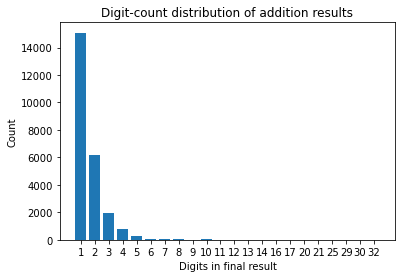

In [ ]:
c_abs = df_add["c"].map(lambda x: abs(int(x)))
digits = c_abs.map(lambda n: 1 if n == 0 else len(str(n)))
counts = digits.value_counts().sort_index()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Digits in final result")
plt.ylabel("Count")
plt.title("Digit-count distribution of addition results")
plt.show()

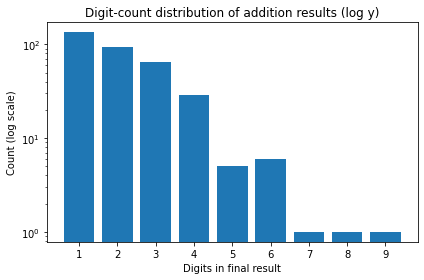

In [ ]:
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.yscale("log")  # <- log scale for counts
plt.xlabel("Digits in final result")
plt.ylabel("Count (log scale)")
plt.title("Digit-count distribution of addition results (log y)")
plt.tight_layout()
plt.show()

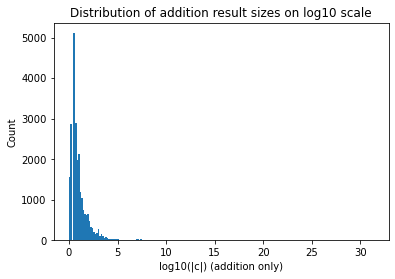

In [ ]:
def safe_log10_int(n: int) -> float:
    n = abs(int(n))
    if n == 0:
        return 0.0
    k = n.bit_length()
    shift = max(k - 53, 0)      # keep ~53 bits for float mantissa
    m = n >> shift              # m fits in float exactly
    log2n = math.log2(m) + shift
    return log2n / math.log2(10)

c_abs = df_add["c"].map(lambda x: abs(int(x)))
log10_c = c_abs.map(safe_log10_int)   # float series

plt.figure()
plt.hist(log10_c, bins=200)
plt.xlabel("log10(|c|) (addition only)")
plt.ylabel("Count")
plt.title("Distribution of addition result sizes on log10 scale")
plt.show()


In [ ]:
# results up to 10
# results beyond 10

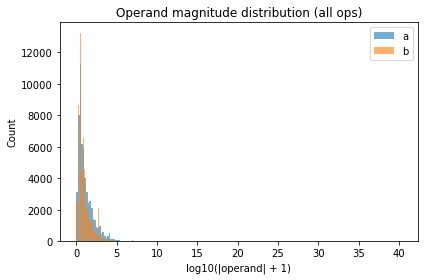

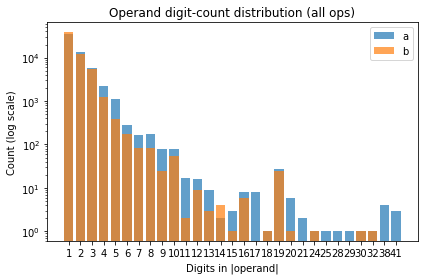

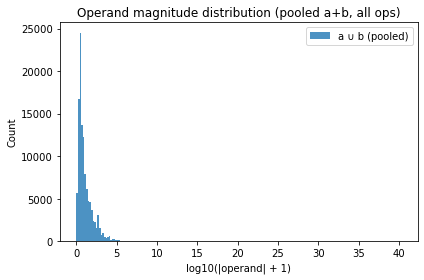

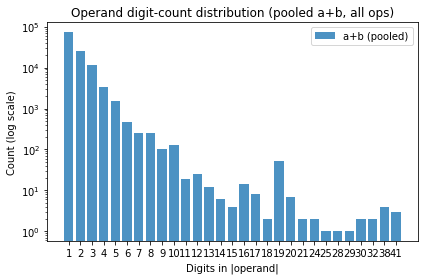

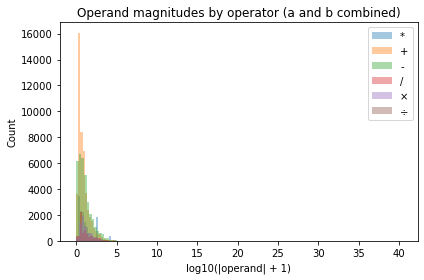

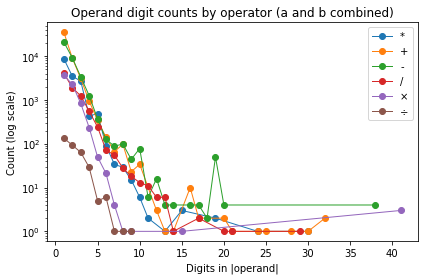

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# --- helpers that work for arbitrarily large Python ints ---
def digits_int(x) -> int:
    x = abs(int(x))
    return 1 if x == 0 else len(str(x))

def safe_log10_int(x) -> float:
    """log10(|x|+1) without converting huge ints to float unsafely."""
    x = abs(int(x))
    if x == 0:
        return 0.0  # log10(0+1)
    # compute log10(x+1) via bit_length trick
    n = x + 1
    k = n.bit_length()
    shift = max(k - 53, 0)
    m = n >> shift
    log2n = math.log2(m) + shift
    return log2n / math.log2(10)

# --- assume df already loaded safely (json.loads loop) ---
# df = pd.DataFrame(rows)

# normalize operator symbols a bit (optional)
df["op_norm"] = df["op"].astype(str).str.strip()

# compute operand features (as objects / python ints)
for col in ["a", "b"]:
    df[f"{col}_abs"] = df[col].map(lambda x: abs(int(x)))
    df[f"{col}_digits"] = df[col].map(digits_int)
    df[f"{col}_log10p1"] = df[col].map(safe_log10_int)

# =========================
# 1) Operand magnitude (log10(|x|+1)) — overall
# =========================
plt.figure()
plt.hist(df["a_log10p1"], bins=200, alpha=0.6, label="a")
plt.hist(df["b_log10p1"], bins=200, alpha=0.6, label="b")
plt.xlabel("log10(|operand| + 1)")
plt.ylabel("Count")
plt.title("Operand magnitude distribution (all ops)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 2) Operand digit counts — overall (with log y to see tails)
# =========================
a_counts = df["a_digits"].value_counts().sort_index()
b_counts = df["b_digits"].value_counts().sort_index()

plt.figure()
plt.bar(a_counts.index.astype(str), a_counts.values, alpha=0.7, label="a")
plt.bar(b_counts.index.astype(str), b_counts.values, alpha=0.7, label="b")
plt.yscale("log")
plt.xlabel("Digits in |operand|")
plt.ylabel("Count (log scale)")
plt.title("Operand digit-count distribution (all ops)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 1) Operand magnitude (log10(|x|+1)) — pooled a+b
# =========================
ab_log = pd.concat([df["a_log10p1"], df["b_log10p1"]], ignore_index=True)

plt.figure()
plt.hist(ab_log, bins=200, alpha=0.8, label="a ∪ b (pooled)")
plt.xlabel("log10(|operand| + 1)")
plt.ylabel("Count")
plt.title("Operand magnitude distribution (pooled a+b, all ops)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 2) Operand digit counts — pooled a+b (with log y)
# =========================
a_counts = df["a_digits"].value_counts().sort_index()
b_counts = df["b_digits"].value_counts().sort_index()
ab_counts = a_counts.add(b_counts, fill_value=0).sort_index().astype(int)

plt.figure()
plt.bar(ab_counts.index.astype(str), ab_counts.values, alpha=0.8, label="a+b (pooled)")
plt.yscale("log")
plt.xlabel("Digits in |operand|")
plt.ylabel("Count (log scale)")
plt.title("Operand digit-count distribution (pooled a+b, all ops)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 3) Same two views, split by operator
# =========================
ops = sorted(df["op_norm"].dropna().unique())

# 3a) magnitude by op (log10(|x|+1))
plt.figure()
for op in ops:
    sub = df[df["op_norm"] == op]
    # combine a and b into one series so you see overall operand sizes per op
    vals = pd.concat([sub["a_log10p1"], sub["b_log10p1"]], ignore_index=True)
    plt.hist(vals, bins=120, alpha=0.4, label=op)
plt.xlabel("log10(|operand| + 1)")
plt.ylabel("Count")
plt.title("Operand magnitudes by operator (a and b combined)")
plt.legend()
plt.tight_layout()
plt.show()

# 3b) digit counts by op (log y)
plt.figure()
for op in ops:
    sub = df[df["op_norm"] == op]
    d = pd.concat([sub["a_digits"], sub["b_digits"]], ignore_index=True)
    counts = d.value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker="o", linewidth=1, label=op)
plt.yscale("log")
plt.xlabel("Digits in |operand|")
plt.ylabel("Count (log scale)")
plt.title("Operand digit counts by operator (a and b combined)")
plt.legend()
plt.tight_layout()
plt.show()


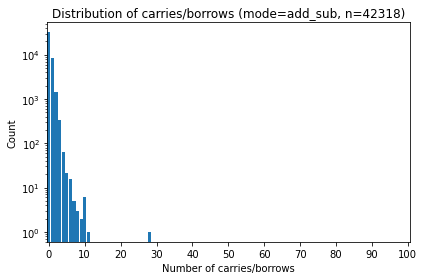

In [ ]:
# -----------------------------
# Carry / borrow counting utils
# -----------------------------
def count_carries_add(a: int, b: int) -> int:
    """Count base-10 carries when adding non-negative integers a + b."""
    a, b = abs(int(a)), abs(int(b))
    carries = 0
    carry = 0
    while a > 0 or b > 0:
        da, db = a % 10, b % 10
        if da + db + carry >= 10:
            carries += 1
            carry = 1
        else:
            carry = 0
        a //= 10
        b //= 10
    return carries

def count_borrows_sub(a: int, b: int) -> int:
    """
    Count base-10 borrows when subtracting non-negative integers a - b.
    If a < b, we count borrows for |a - b| by swapping (still meaningful as a difficulty proxy).
    """
    a, b = abs(int(a)), abs(int(b))
    if a < b:
        a, b = b, a
    borrows = 0
    borrow = 0
    while a > 0 or b > 0:
        da, db = a % 10, b % 10
        da -= borrow
        if da < db:
            borrows += 1
            borrow = 1
        else:
            borrow = 0
        a //= 10
        b //= 10
    return borrows

def count_carries_mul(a: int, b: int) -> int:
    """
    Optional: count carries in grade-school multiplication via partial products:
    sum over each digit of b of carries in (a * digit) and in adding shifted rows.
    This is a heuristic difficulty measure, not a universal definition.
    """
    a, b = abs(int(a)), abs(int(b))
    carries = 0

    # carries in each single-digit multiply row
    bb = b
    shift = 0
    partials = []
    while bb > 0:
        d = bb % 10
        bb //= 10
        carry = 0
        row_carries = 0
        aa = a
        place = 1
        row_val = 0
        while aa > 0:
            ad = aa % 10
            aa //= 10
            prod = ad * d + carry
            if prod >= 10:
                row_carries += 1
                carry = prod // 10
            else:
                carry = 0
            row_val += (prod % 10) * place
            place *= 10
        if carry > 0:
            # carry out at the end of the row counts as a carry event too
            row_carries += 1
            row_val += carry * place
        carries += row_carries
        partials.append(row_val * (10 ** shift))
        shift += 1

    # carries when summing partial products
    total = 0
    for p in partials:
        carries += count_carries_add(total, p)
        total += p

    return carries

def normalize_op(op: str) -> str:
    # normalize unicode multiplication sign
    return "*" if op in {"×", "x", "X", "*"} else op

def carry_metric_for_record(rec: dict, mode: str = "add_sub_mul"):
    """
    Returns carry/borrow count for a record, or None if op is unsupported in chosen mode.
    mode:
      - "add_only": only '+' carries
      - "add_sub": '+' carries and '-' borrows
      - "add_sub_mul": +, -, * (mul heuristic)
    """
    op = normalize_op(str(rec.get("op", "")).strip())
    a = rec.get("a")
    b = rec.get("b")

    if op == "+":
        return count_carries_add(a, b)

    if mode in {"add_sub", "add_sub_mul"} and op == "-":
        return count_borrows_sub(a, b)

    if mode == "add_sub_mul" and op == "*":
        return count_carries_mul(a, b)

    # You can decide what to do with division; usually no carries/borrows
    return None


# -----------------------------
# Load JSONL and compute counts
# -----------------------------
PATH = "pile_arith_matches_full_copy_backup.jsonl"   # <-- change to your file path
MODE = "add_sub"              # "add_only" | "add_sub" | "add_sub_mul"

counts = []
with open(PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        v = carry_metric_for_record(rec, mode=MODE)
        if v is not None:
            counts.append(v)

if not counts:
    raise ValueError("No carry/borrow counts computed. Check MODE/op values and input file.")

# -----------------------------
# Plot distribution
# -----------------------------
freq = Counter(counts)
max_x = 100
bins = list(range(0, max_x + 2))  # 0..101 so 100 has a full bin

plt.figure()
plt.hist(counts, bins=bins, align="left", rwidth=0.9)
plt.xlim(-0.5, max_x + 0.5)
plt.xticks(range(0, max_x + 1, 10))  # change step if you want
plt.xlabel("Number of carries/borrows")
plt.ylabel("Count")
plt.yscale("log")
plt.title(f"Distribution of carries/borrows (mode={MODE}, n={len(counts)})")
plt.tight_layout()
plt.show()

### Visualizations
- at first, don't log the y-axis
0. Distribution, line graph

1. Problem size
- digits of a + b, c
- log of ^ 

(4)

2. Across all 4 operations
- Binned by operations

(2)

3. Separately for <= 10, > 10
- Combined

(3)

(Standardize graphing convention)


### Find a power function for each of the curves, find r^2
- or fit linear function to log-log 


#### residuals
- perhaps bigger around culturally prominent numbers (e.g. around powers of 10)
- 

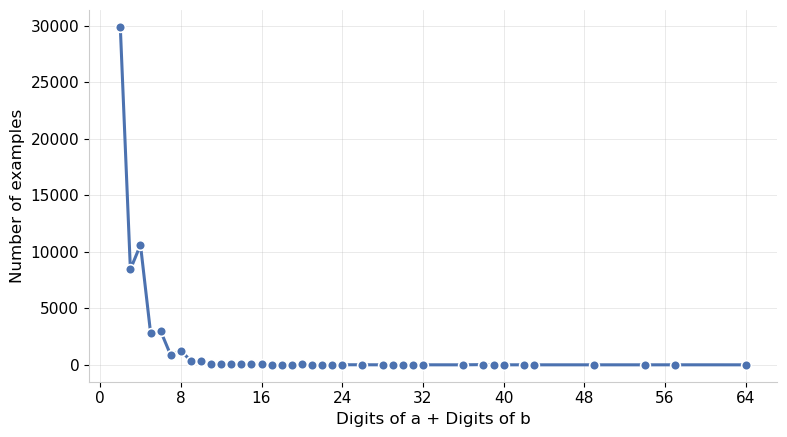

✓ 1a saved


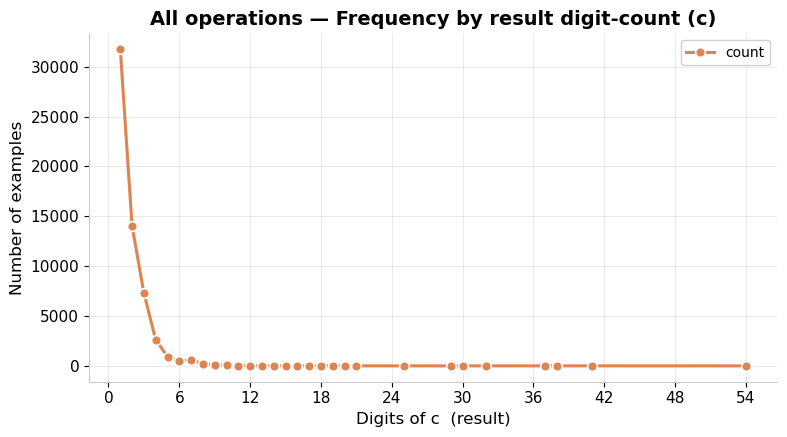

✓ 1b saved


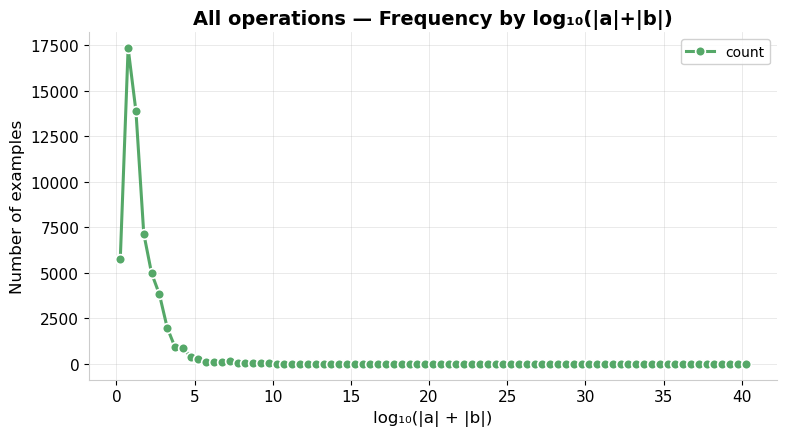

✓ 1c saved


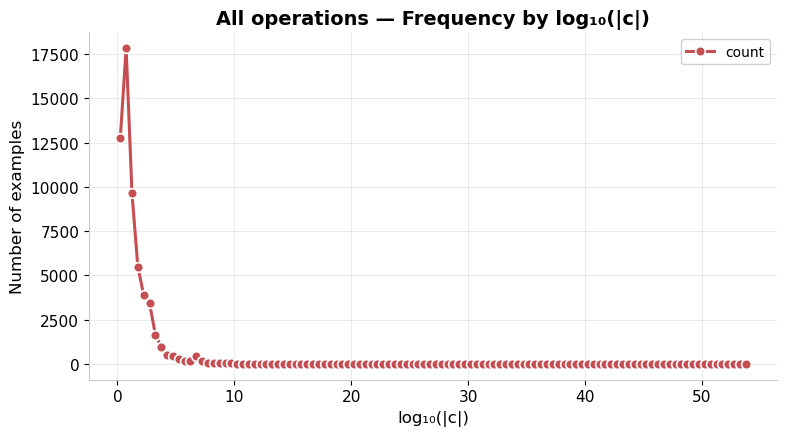

✓ 1d saved


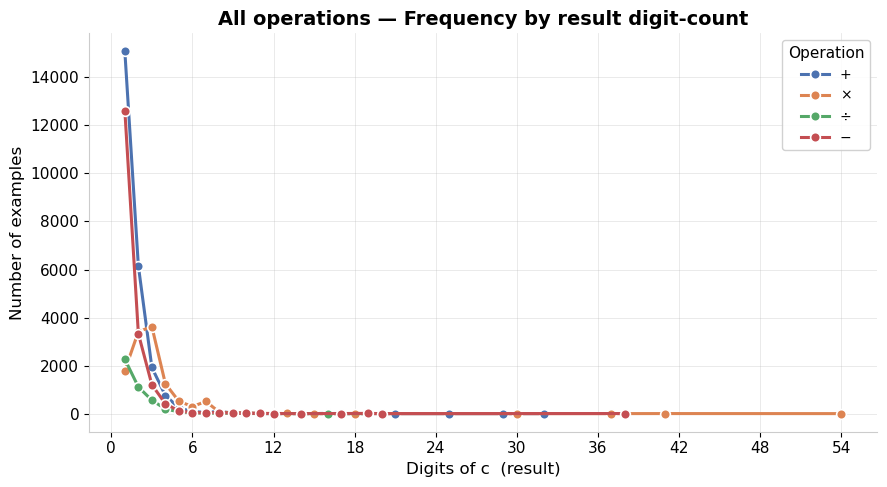

✓ 2a saved


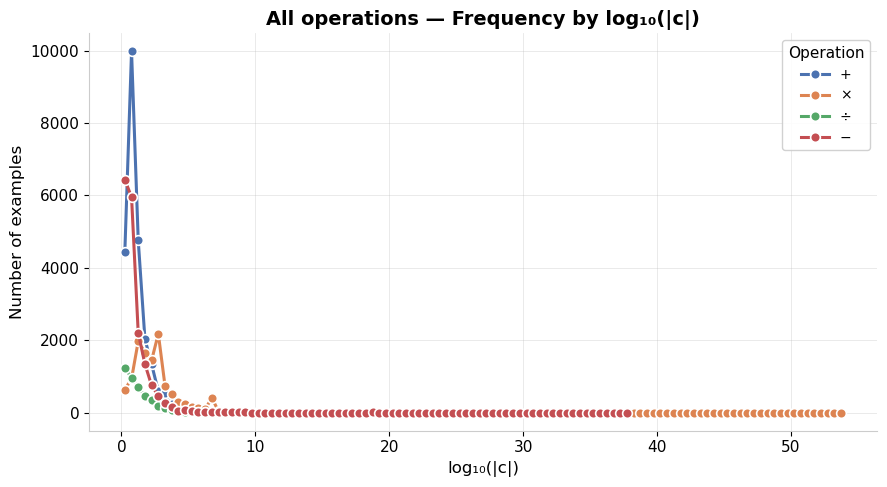

✓ 2b saved


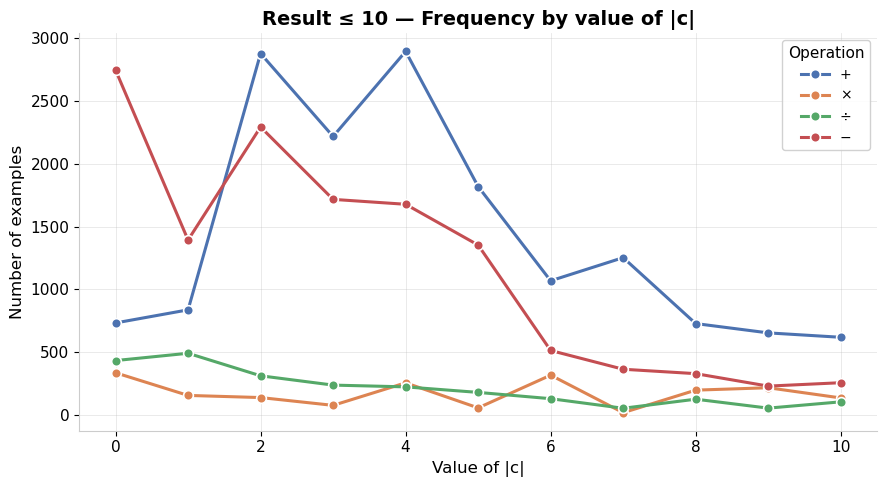

✓ 3a saved


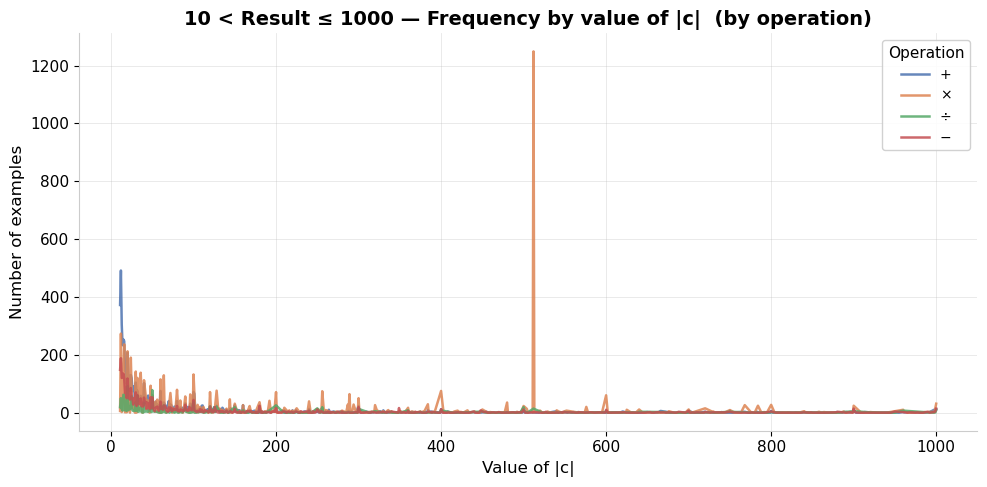

✓ 3b saved


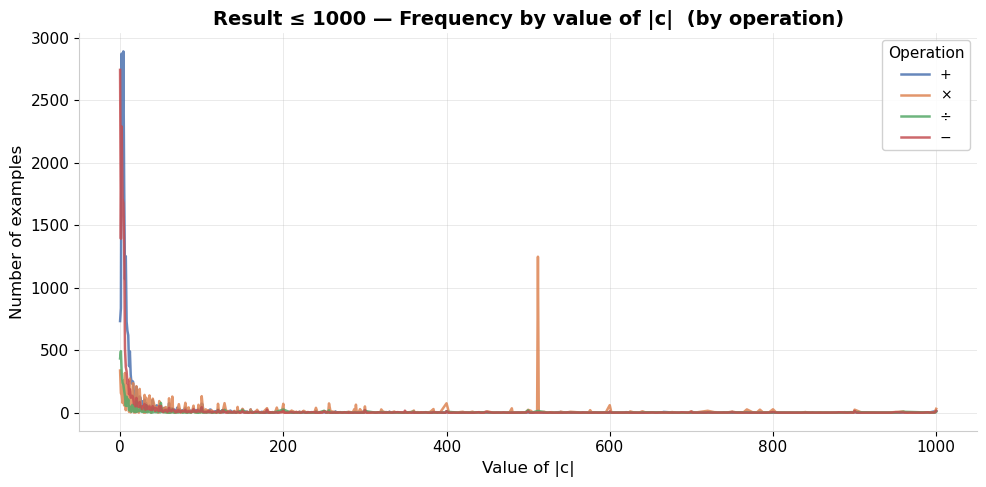

✓ 3c saved


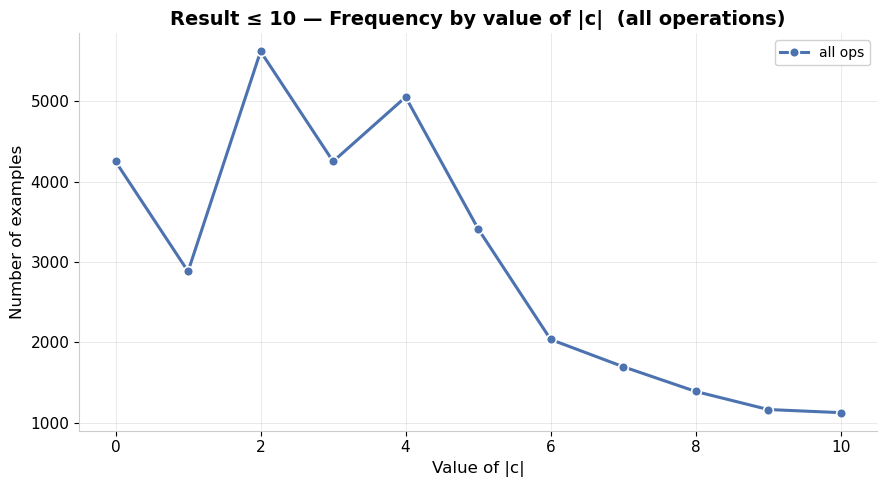

✓ 3d saved


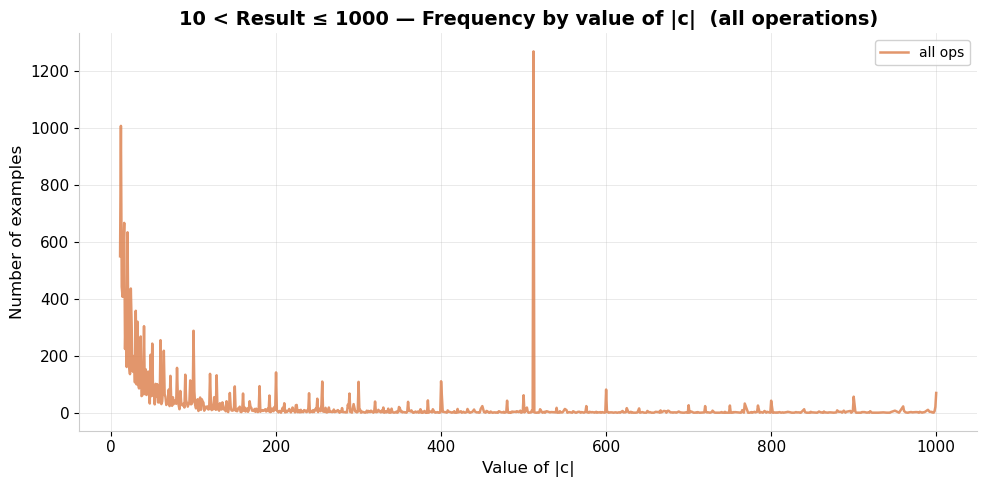

✓ 3e saved


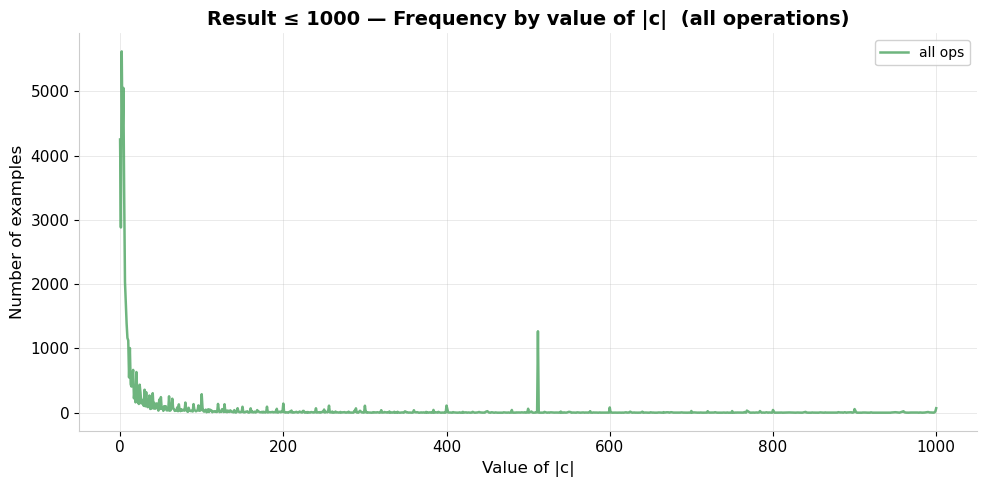

✓ 3f saved

🎉  All 12 plots saved as PNG files in the current directory.


In [17]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
# 0.  Global style
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.alpha":         0.30,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     14,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "0.8",
    "figure.dpi":         100,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]

MARKER_DEFAULTS = dict(
    markersize=7,
    markeredgecolor="white",
    markeredgewidth=1.2,
    linewidth=2.2,
)

def nice_line(ax, x, y, *, label=None, color=None, idx=0, **kw):
    """Plot a line with dots at every data point."""
    c = color or PALETTE[idx % len(PALETTE)]
    ax.plot(x, y, marker="o", color=c, label=label, **MARKER_DEFAULTS, **kw)


# ─────────────────────────────────────────────
# 1.  Load & prep data
# ─────────────────────────────────────────────
path = "pile_arith_matches_full_copy_backup.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# Normalise operator column
df["op_norm"] = df["op"].astype(str).str.strip()

# Cast operands
for col in ("a", "b", "c"):
    df[col] = df[col].apply(lambda x: int(x))

df["c_abs"] = df["c"].abs()
df["a_abs"] = df["a"].abs()
df["b_abs"] = df["b"].abs()

# Derived columns  (safe for zero / negative via abs+1)
df["digits_a"]   = df["a_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_b"]   = df["b_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_c"]   = df["c_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_ab"]  = df["digits_a"] + df["digits_b"]          # combined digit count
df["log_ab"]     = np.log10((df["a_abs"] + df["b_abs"] + 1).astype(float))  # +1 to avoid log(0)
df["log_c"]      = np.log10((df["c_abs"] + 1).astype(float))

# Addition subset
df_add = df[df["op_norm"].isin({"+", "\uff0b"})].copy()

# Helper: canonical op labels
OP_MAP = {"+": "+", "\uff0b": "+", "-": "−", "\uff0d": "−",
          "*": "×", "\uff0a": "×", "×": "×",
          "/": "÷", "\uff0f": "÷", "÷": "÷"}
df["op_label"] = df["op_norm"].map(OP_MAP).fillna(df["op_norm"])


# ═══════════════════════════════════════════════
# SECTION 1 — Problem‑size plots  (addition only)
# ═══════════════════════════════════════════════

def binned_mean(series, values, min_count=30):
    """Return (bin_centres, means) after grouping *values* by integer *series*."""
    tmp = pd.DataFrame({"x": series, "y": values}).dropna()
    g = tmp.groupby("x")["y"]
    stats = g.agg(["mean", "count"]).reset_index()
    stats = stats[stats["count"] >= min_count]
    return stats["x"].values, stats["mean"].values


# 1a  Frequency vs digits_ab  (digits of a + digits of b)
fig, ax = plt.subplots(figsize=(8, 4.5))
counts = df["digits_ab"].value_counts().sort_index()
nice_line(ax, counts.index, counts.values, label="count", idx=0)
ax.set_xlabel("Digits of a + Digits of b")
ax.set_ylabel("Number of examples")
# ax.set_title("All operations — Frequency by operand digit‑count (a + b)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# ax.legend()
fig.tight_layout()
fig.savefig("1a_freq_vs_digits_ab.png")
plt.show()
print("✓ 1a saved")


# 1b  Frequency vs digits_c
fig, ax = plt.subplots(figsize=(8, 4.5))
counts = df["digits_c"].value_counts().sort_index()
nice_line(ax, counts.index, counts.values, label="count", idx=1)
ax.set_xlabel("Digits of c  (result)")
ax.set_ylabel("Number of examples")
ax.set_title("All operations — Frequency by result digit‑count (c)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
fig.tight_layout()
fig.savefig("1b_freq_vs_digits_c.png")
plt.show()
print("✓ 1b saved")


# 1c  Frequency vs log(a+b)
fig, ax = plt.subplots(figsize=(8, 4.5))
bins_log = np.arange(0, df["log_ab"].max() + 0.5, 0.5)
hist_vals, bin_edges = np.histogram(df["log_ab"], bins=bins_log)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
nice_line(ax, bin_centres, hist_vals, label="count", idx=2)
ax.set_xlabel("log₁₀(|a| + |b|)")
ax.set_ylabel("Number of examples")
ax.set_title("All operations — Frequency by log₁₀(|a|+|b|)")
ax.legend()
fig.tight_layout()
fig.savefig("1c_freq_vs_log_ab.png")
plt.show()
print("✓ 1c saved")


# 1d  Frequency vs log(c)
fig, ax = plt.subplots(figsize=(8, 4.5))
bins_log_c = np.arange(0, df["log_c"].max() + 0.5, 0.5)
hist_vals, bin_edges = np.histogram(df["log_c"], bins=bins_log_c)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
nice_line(ax, bin_centres, hist_vals, label="count", idx=3)
ax.set_xlabel("log₁₀(|c|)")
ax.set_ylabel("Number of examples")
ax.set_title("All operations — Frequency by log₁₀(|c|)")
ax.legend()
fig.tight_layout()
fig.savefig("1d_freq_vs_log_c.png")
plt.show()
print("✓ 1d saved")


# ═══════════════════════════════════════════════
# SECTION 2 — All 4 operations, binned
# ═══════════════════════════════════════════════

# 2a  Frequency by digits_c, one line per operation
fig, ax = plt.subplots(figsize=(9, 5))
for i, (op, grp) in enumerate(df.groupby("op_label")):
    counts = grp["digits_c"].value_counts().sort_index()
    nice_line(ax, counts.index, counts.values, label=op, idx=i)
ax.set_xlabel("Digits of c  (result)")
ax.set_ylabel("Number of examples")
ax.set_title("All operations — Frequency by result digit‑count")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("2a_ops_digits_c.png")
plt.show()
print("✓ 2a saved")


# 2b  Frequency by log(c), one line per operation
fig, ax = plt.subplots(figsize=(9, 5))
for i, (op, grp) in enumerate(df.groupby("op_label")):
    bins_log_c = np.arange(0, grp["log_c"].max() + 0.5, 0.5)
    if len(bins_log_c) < 2:
        continue
    hv, be = np.histogram(grp["log_c"], bins=bins_log_c)
    bc = 0.5 * (be[:-1] + be[1:])
    nice_line(ax, bc, hv, label=op, idx=i)
ax.set_xlabel("log₁₀(|c|)")
ax.set_ylabel("Number of examples")
ax.set_title("All operations — Frequency by log₁₀(|c|)")
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("2b_ops_log_c.png")
plt.show()
print("✓ 2b saved")


# ═══════════════════════════════════════════════
# SECTION 3 — Split by result size  (≤10 vs >10)
#   3a: c ≤ 10, count by each value of c, per operation
#   3b: c > 10, count by each value of c, per operation
#   3c: combined (all c), count by each value of c, per operation
# ═══════════════════════════════════════════════

df_small = df[df["c_abs"] <= 10].copy()
df_large = df[df["c_abs"] >  10].copy()

# 3a  c ≤ 10 — count by value of c, per operation
fig, ax = plt.subplots(figsize=(9, 5))
for i, (op, grp) in enumerate(df_small.groupby("op_label")):
    counts = grp["c_abs"].value_counts().sort_index()
    nice_line(ax, counts.index, counts.values, label=op, idx=i)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title("Result ≤ 10 — Frequency by value of |c|")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("3a_small_c_by_op.png")
plt.show()
print("✓ 3a saved")


# 3b  10 < c ≤ 1000 — raw count by value of c, per operation
#     Hard cutoff at 1000 (captures ~80% of >10 data); no markers due to density
CUTOFF = 1000
df_mid = df[(df["c_abs"] > 10) & (df["c_abs"] <= CUTOFF)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for i, (op, grp) in enumerate(df_mid.groupby("op_label")):
    counts = grp["c_abs"].value_counts().sort_index()
    ax.plot(counts.index, counts.values, color=PALETTE[i % len(PALETTE)],
            label=op, linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"10 < Result ≤ {CUTOFF} — Frequency by value of |c|  (by operation)")
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("3b_mid_c_by_op.png")
plt.show()
print("✓ 3b saved")


# 3c  All c ≤ 1000 — raw count by value of c, per operation
df_all_cut = df[df["c_abs"] <= CUTOFF].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for i, (op, grp) in enumerate(df_all_cut.groupby("op_label")):
    counts = grp["c_abs"].value_counts().sort_index()
    ax.plot(counts.index, counts.values, color=PALETTE[i % len(PALETTE)],
            label=op, linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"Result ≤ {CUTOFF} — Frequency by value of |c|  (by operation)")
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("3c_combined_by_op.png")
plt.show()
print("✓ 3c saved")


# 3d  c ≤ 10 — all operations combined, single line
fig, ax = plt.subplots(figsize=(9, 5))
counts = df_small["c_abs"].value_counts().sort_index()
nice_line(ax, counts.index, counts.values, label="all ops", idx=0)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title("Result ≤ 10 — Frequency by value of |c|  (all operations)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
fig.tight_layout()
fig.savefig("3d_small_c_all_ops.png")
plt.show()
print("✓ 3d saved")


# 3e  10 < c ≤ 1000 — all operations combined, single line
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_mid["c_abs"].value_counts().sort_index()
ax.plot(counts.index, counts.values, color=PALETTE[1], label="all ops",
        linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"10 < Result ≤ {CUTOFF} — Frequency by value of |c|  (all operations)")
ax.legend()
fig.tight_layout()
fig.savefig("3e_mid_c_all_ops.png")
plt.show()
print("✓ 3e saved")


# 3f  All c ≤ 1000 — all operations combined, single line
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_all_cut["c_abs"].value_counts().sort_index()
ax.plot(counts.index, counts.values, color=PALETTE[2], label="all ops",
        linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"Result ≤ {CUTOFF} — Frequency by value of |c|  (all operations)")
ax.legend()
fig.tight_layout()
fig.savefig("3f_combined_all_ops.png")
plt.show()
print("✓ 3f saved")


print("\n🎉  All 12 plots saved as PNG files in the current directory.")

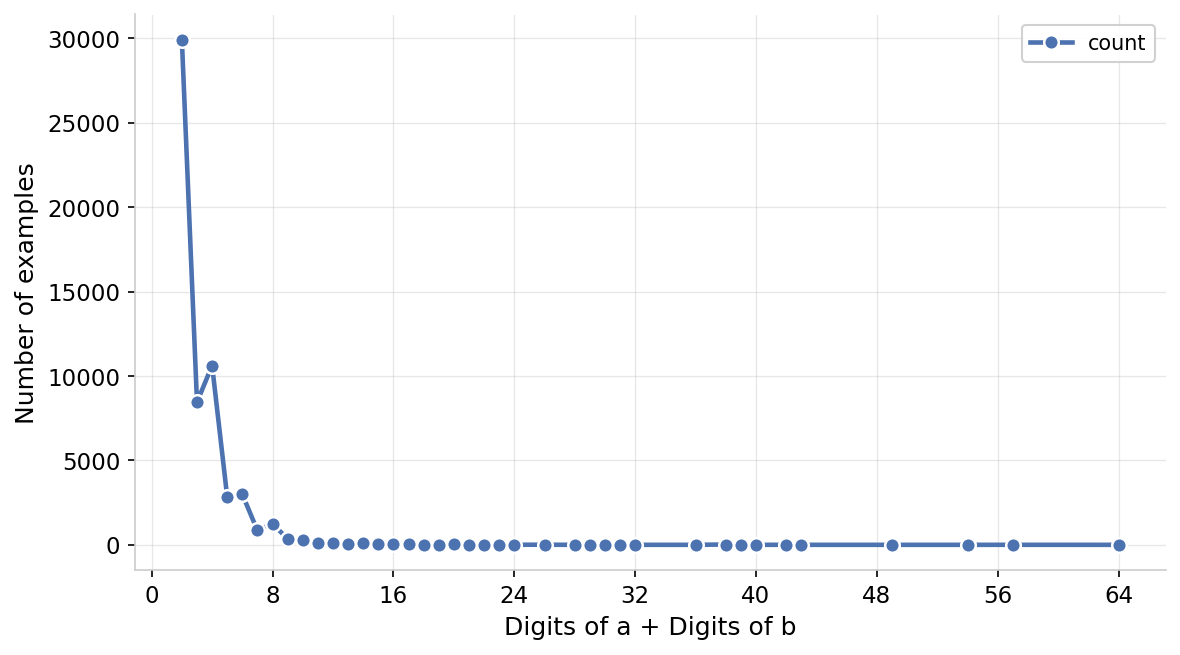

✓ 1a saved


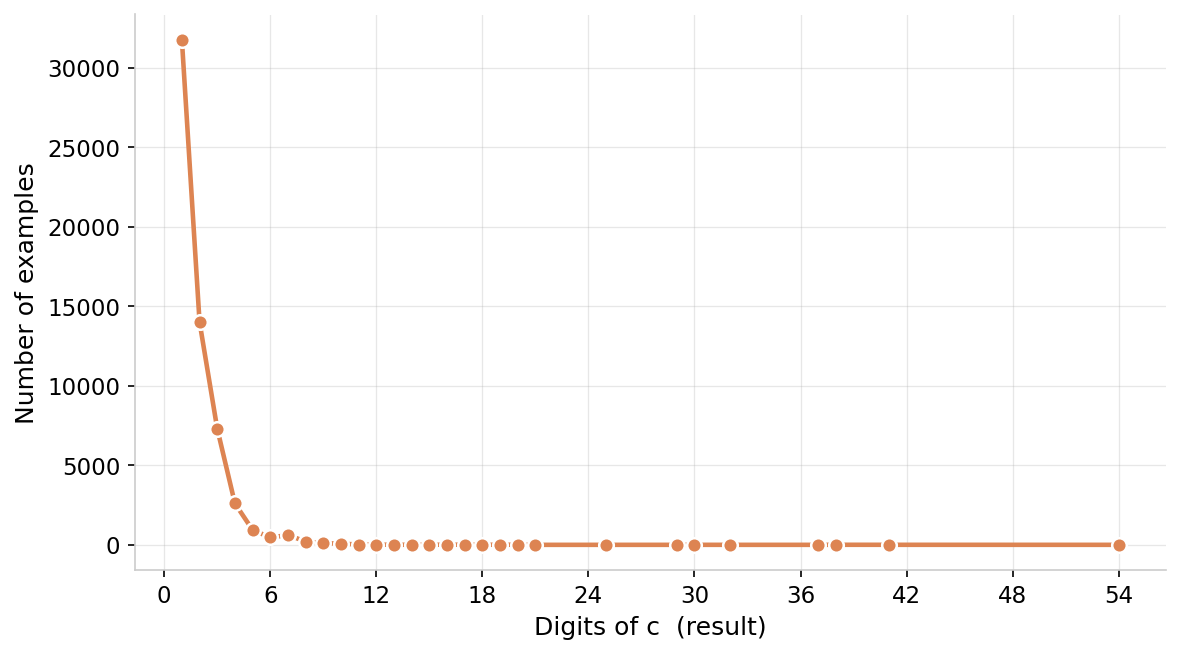

✓ 1b saved


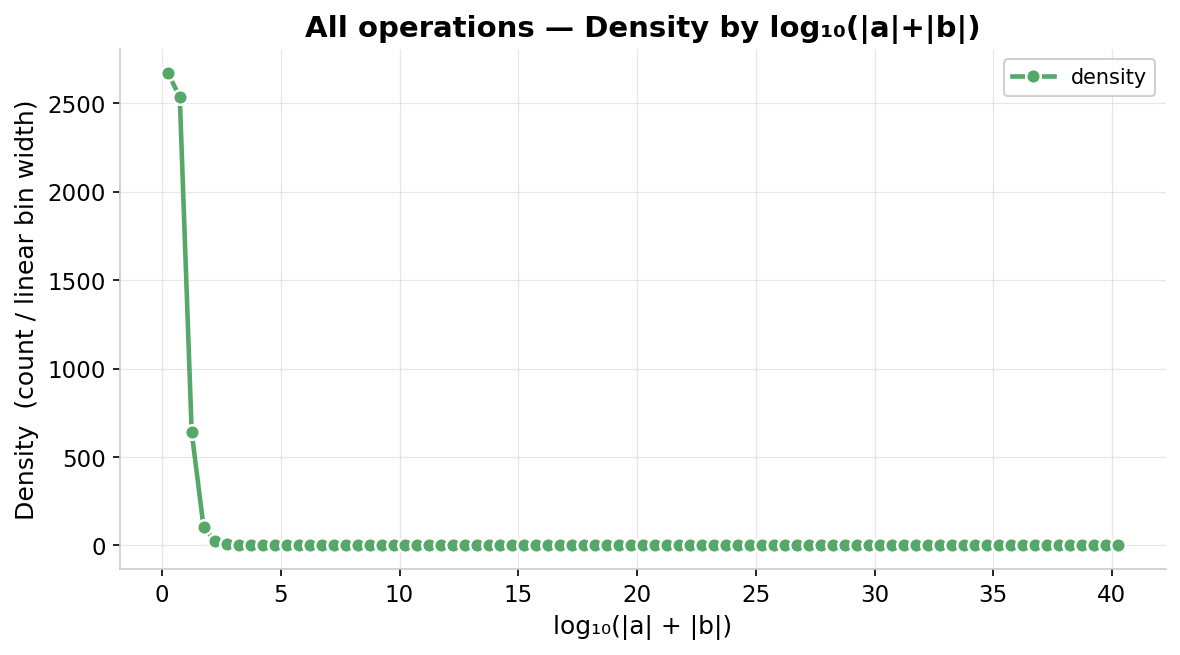

✓ 1c saved


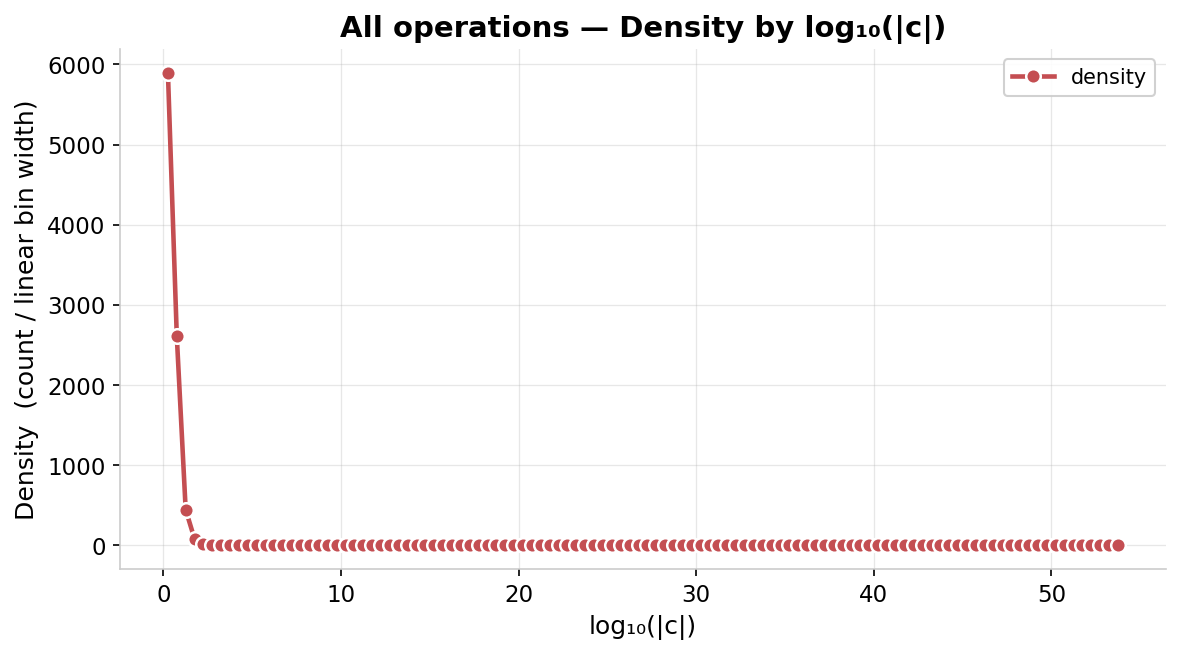

✓ 1d saved


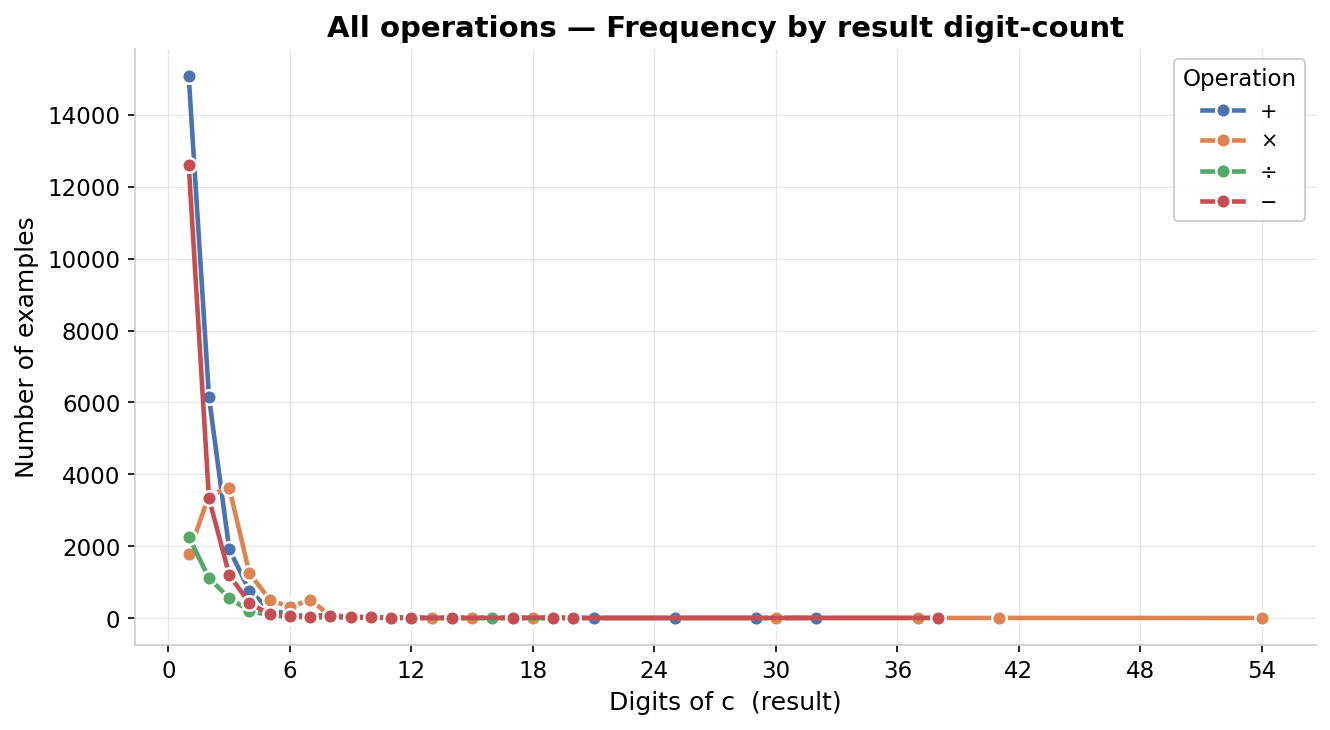

✓ 2a saved


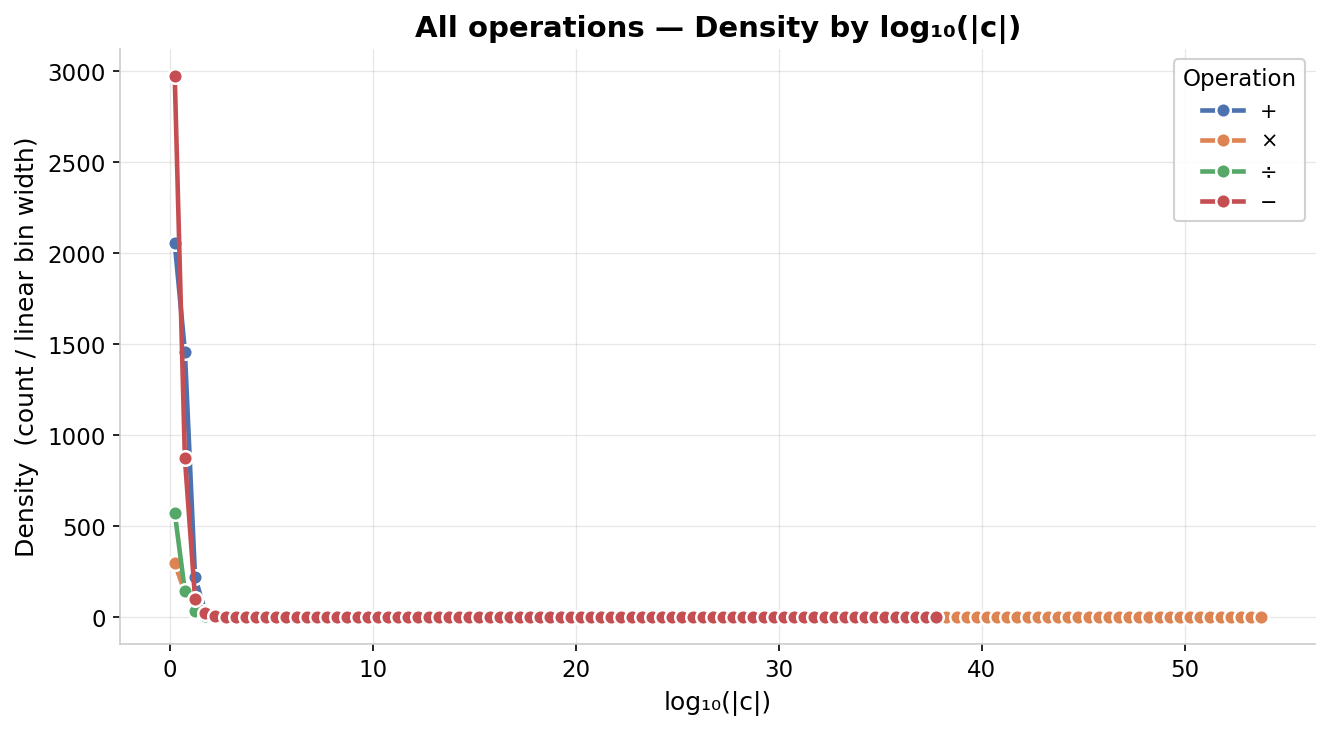

✓ 2b saved


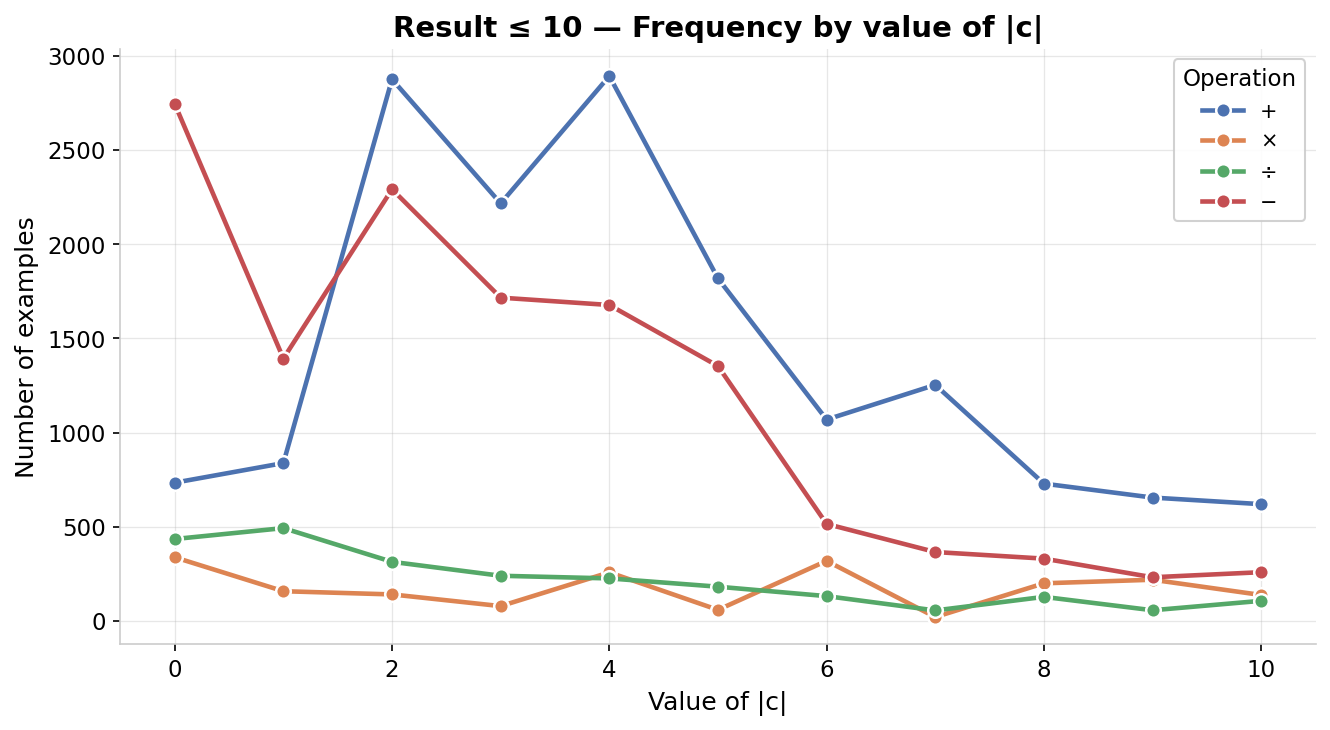

✓ 3a saved


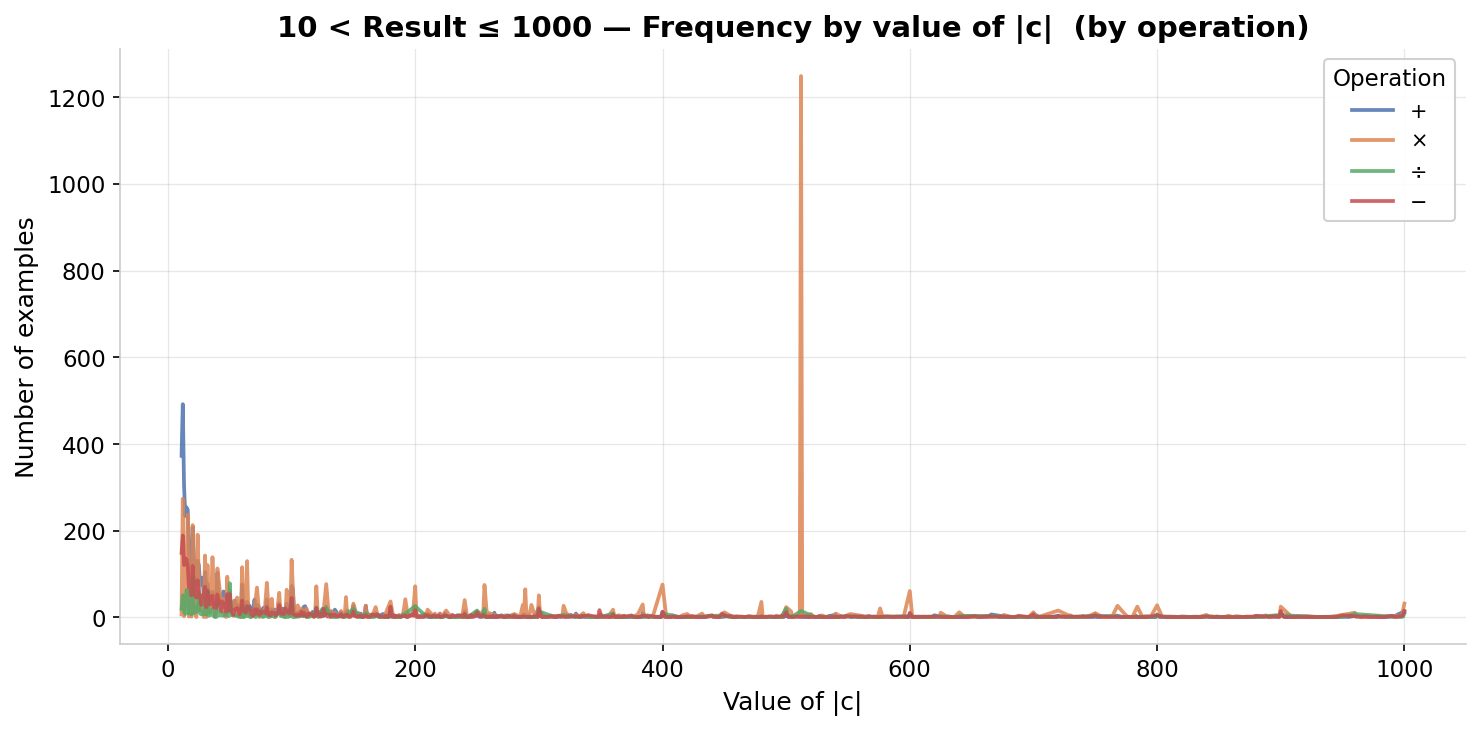

✓ 3b saved


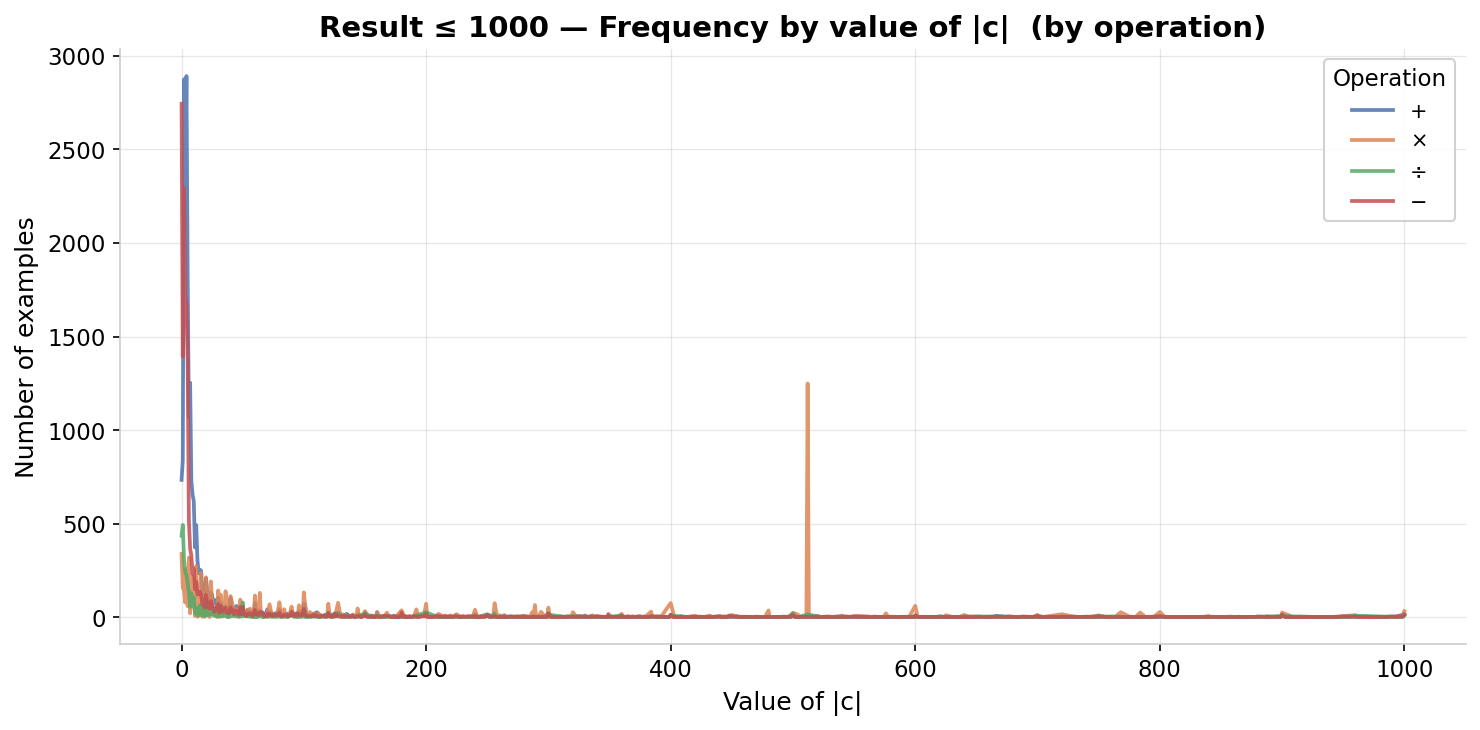

✓ 3c saved


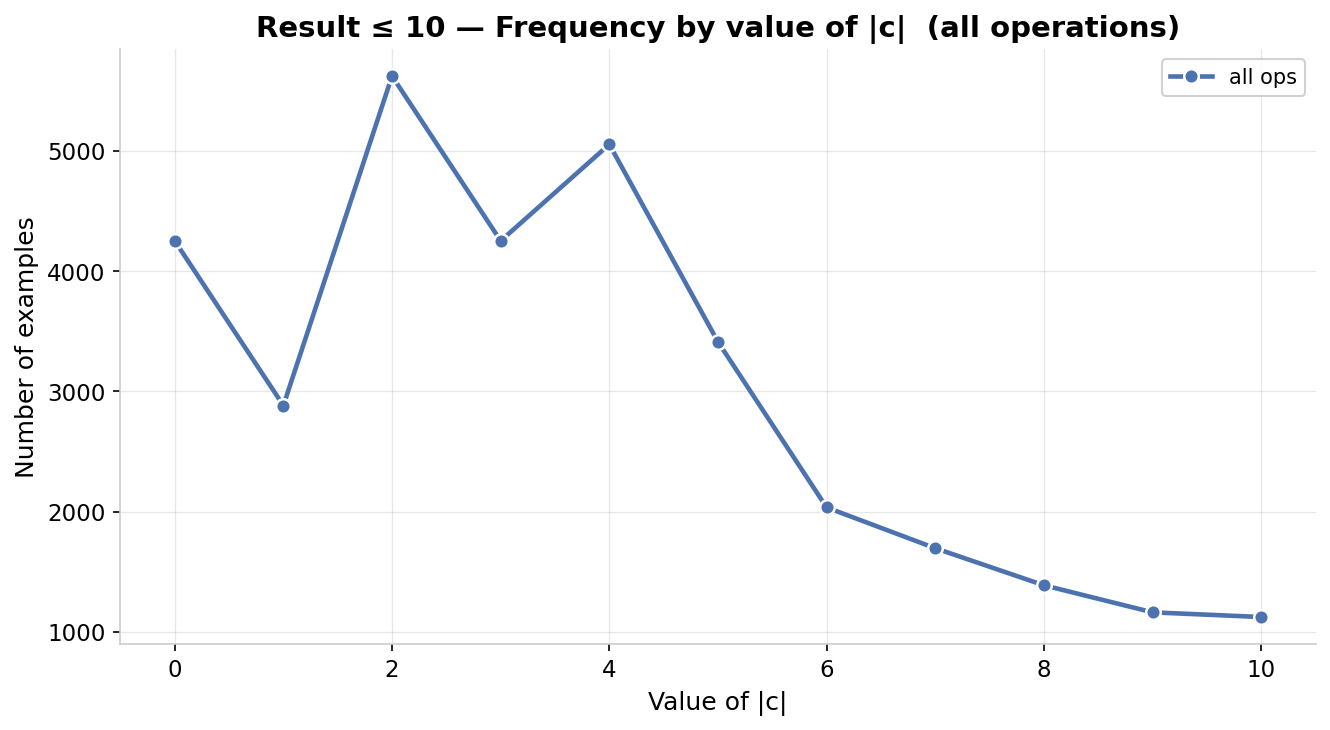

✓ 3d saved


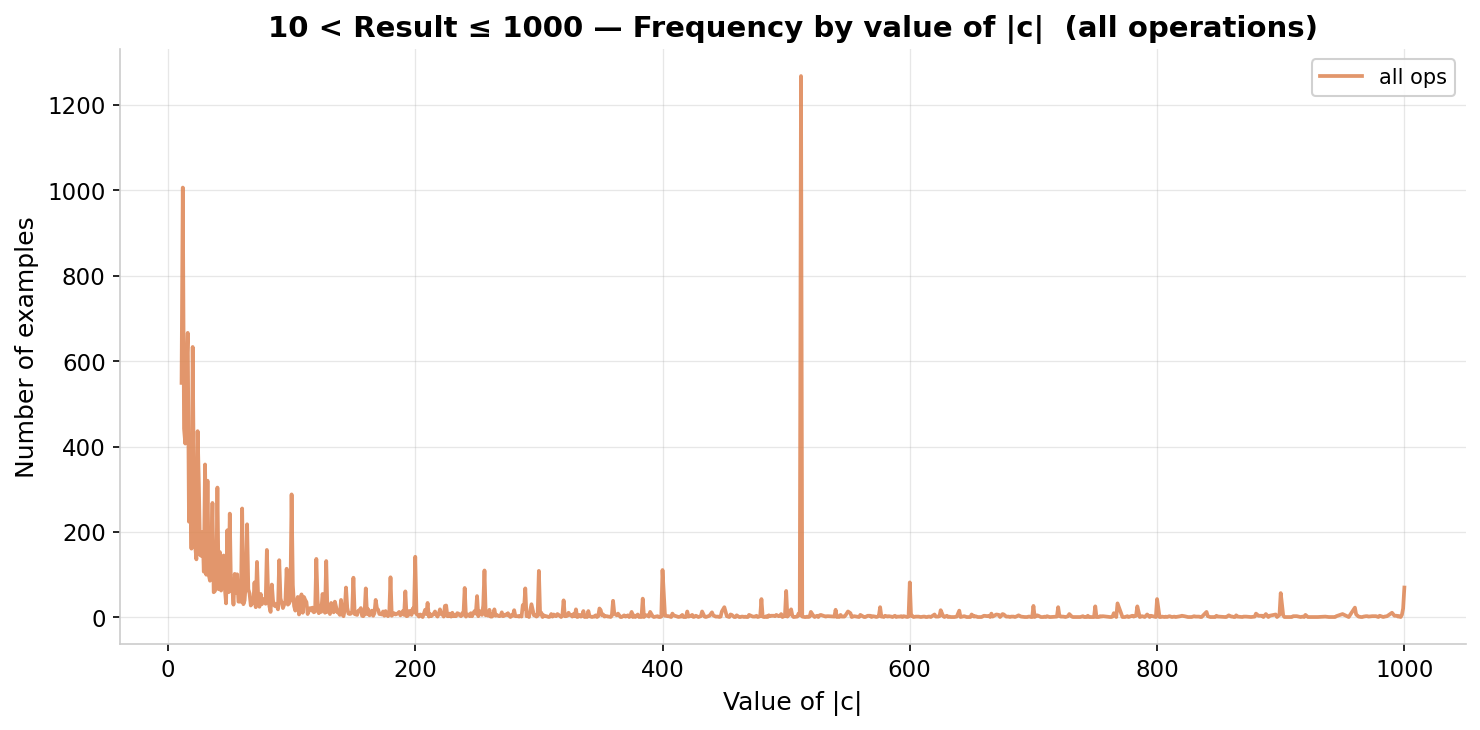

✓ 3e saved


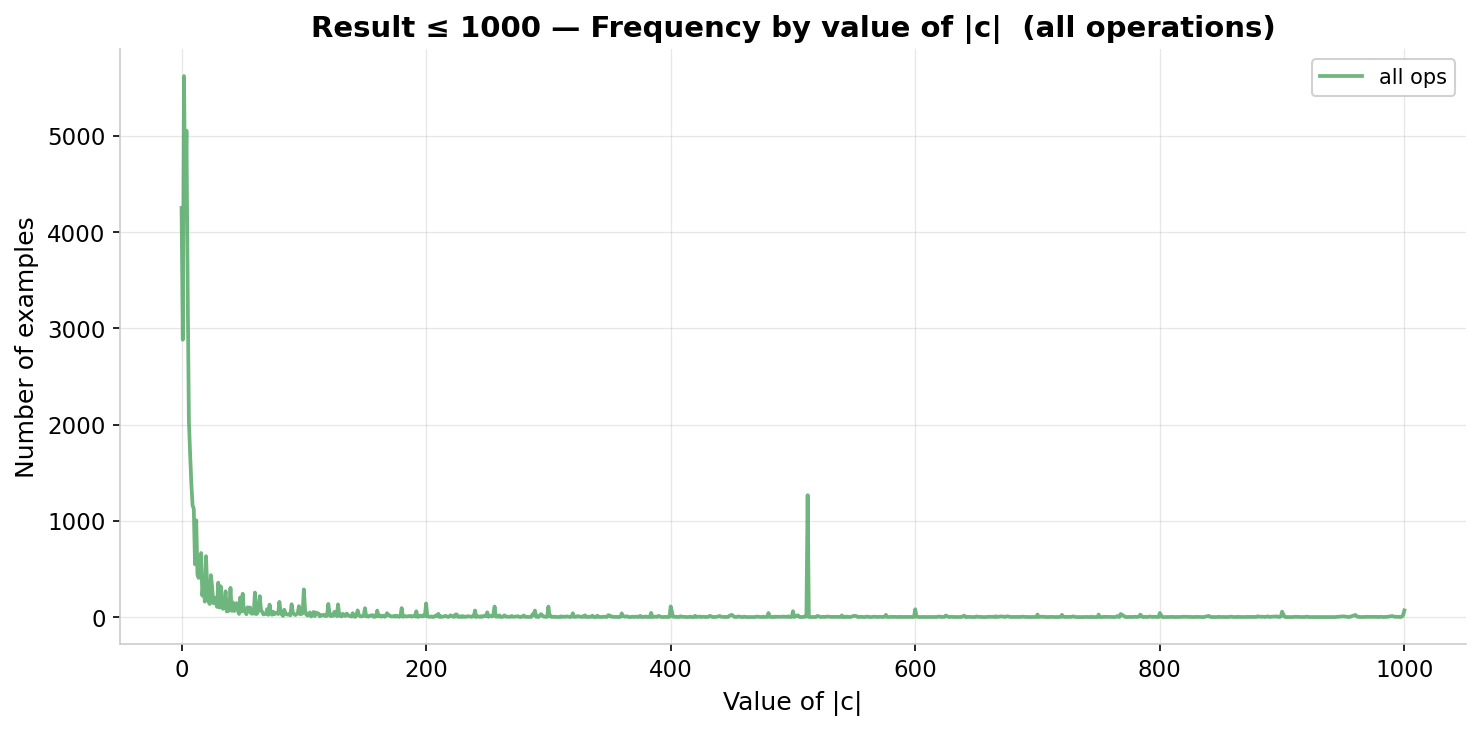

✓ 3f saved

🎉  All 12 plots saved as PNG files in the current directory.


In [20]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
# 0.  Global style
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.alpha":         0.30,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     14,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "0.8",
    "figure.dpi":         150,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]

MARKER_DEFAULTS = dict(
    markersize=7,
    markeredgecolor="white",
    markeredgewidth=1.2,
    linewidth=2.2,
)

def nice_line(ax, x, y, *, label=None, color=None, idx=0, **kw):
    """Plot a line with dots at every data point."""
    c = color or PALETTE[idx % len(PALETTE)]
    ax.plot(x, y, marker="o", color=c, label=label, **MARKER_DEFAULTS, **kw)


# ─────────────────────────────────────────────
# 1.  Load & prep data
# ─────────────────────────────────────────────
path = "pile_arith_matches_full_copy_backup.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# Normalise operator column
df["op_norm"] = df["op"].astype(str).str.strip()

# Cast operands
for col in ("a", "b", "c"):
    df[col] = df[col].apply(lambda x: int(x))

df["c_abs"] = df["c"].abs()
df["a_abs"] = df["a"].abs()
df["b_abs"] = df["b"].abs()

# Derived columns  (safe for zero / negative via abs+1)
df["digits_a"]   = df["a_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_b"]   = df["b_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_c"]   = df["c_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_ab"]  = df["digits_a"] + df["digits_b"]          # combined digit count
df["log_ab"]     = np.log10((df["a_abs"] + df["b_abs"] + 1).astype(float))  # +1 to avoid log(0)
df["log_c"]      = np.log10((df["c_abs"] + 1).astype(float))

# Addition subset
df_add = df[df["op_norm"].isin({"+", "\uff0b"})].copy()

# Helper: canonical op labels
OP_MAP = {"+": "+", "\uff0b": "+", "-": "−", "\uff0d": "−",
          "*": "×", "\uff0a": "×", "×": "×",
          "/": "÷", "\uff0f": "÷", "÷": "÷"}
df["op_label"] = df["op_norm"].map(OP_MAP).fillna(df["op_norm"])


# ═══════════════════════════════════════════════
# SECTION 1 — Problem‑size plots  (addition only)
# ═══════════════════════════════════════════════

def binned_mean(series, values, min_count=30):
    """Return (bin_centres, means) after grouping *values* by integer *series*."""
    tmp = pd.DataFrame({"x": series, "y": values}).dropna()
    g = tmp.groupby("x")["y"]
    stats = g.agg(["mean", "count"]).reset_index()
    stats = stats[stats["count"] >= min_count]
    return stats["x"].values, stats["mean"].values


# 1a  Frequency vs digits_ab  (digits of a + digits of b)
fig, ax = plt.subplots(figsize=(8, 4.5))
counts = df["digits_ab"].value_counts().sort_index()
nice_line(ax, counts.index, counts.values, label="count", idx=0)
ax.set_xlabel("Digits of a + Digits of b")
ax.set_ylabel("Number of examples")
# ax.set_title("All operations — Frequency by operand digit‑count (a + b)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
fig.tight_layout()
fig.savefig("1a_freq_vs_digits_ab.png")
plt.show()
print("✓ 1a saved")


# 1b  Frequency vs digits_c
fig, ax = plt.subplots(figsize=(8, 4.5))
counts = df["digits_c"].value_counts().sort_index()
nice_line(ax, counts.index, counts.values, label="count", idx=1)
ax.set_xlabel("Digits of c  (result)")
ax.set_ylabel("Number of examples")
# ax.set_title("All operations — Frequency by result digit‑count (c)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# ax.legend()
fig.tight_layout()
fig.savefig("1b_freq_vs_digits_c.png")
plt.show()
print("✓ 1b saved")


# 1c  Density vs log(a+b)  — normalised by linear bin width
fig, ax = plt.subplots(figsize=(8, 4.5))
bins_log = np.arange(0, df["log_ab"].max() + 0.5, 0.5)
hist_vals, bin_edges = np.histogram(df["log_ab"], bins=bins_log)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
lin_widths = 10**bin_edges[1:] - 10**bin_edges[:-1]   # width in linear space
density = hist_vals / lin_widths
nice_line(ax, bin_centres, density, label="density", idx=2)
ax.set_xlabel("log₁₀(|a| + |b|)")
ax.set_ylabel("Density  (count / linear bin width)")
ax.set_title("All operations — Density by log₁₀(|a|+|b|)")
ax.legend()
fig.tight_layout()
fig.savefig("1c_density_vs_log_ab.png")
plt.show()
print("✓ 1c saved")


# 1d  Density vs log(c)
fig, ax = plt.subplots(figsize=(8, 4.5))
bins_log_c = np.arange(0, df["log_c"].max() + 0.5, 0.5)
hist_vals, bin_edges = np.histogram(df["log_c"], bins=bins_log_c)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
lin_widths = 10**bin_edges[1:] - 10**bin_edges[:-1]
density = hist_vals / lin_widths
nice_line(ax, bin_centres, density, label="density", idx=3)
ax.set_xlabel("log₁₀(|c|)")
ax.set_ylabel("Density  (count / linear bin width)")
ax.set_title("All operations — Density by log₁₀(|c|)")
ax.legend()
fig.tight_layout()
fig.savefig("1d_density_vs_log_c.png")
plt.show()
print("✓ 1d saved")


# ═══════════════════════════════════════════════
# SECTION 2 — All 4 operations, binned
# ═══════════════════════════════════════════════

# 2a  Frequency by digits_c, one line per operation
fig, ax = plt.subplots(figsize=(9, 5))
for i, (op, grp) in enumerate(df.groupby("op_label")):
    counts = grp["digits_c"].value_counts().sort_index()
    nice_line(ax, counts.index, counts.values, label=op, idx=i)
ax.set_xlabel("Digits of c  (result)")
ax.set_ylabel("Number of examples")
ax.set_title("All operations — Frequency by result digit‑count")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("2a_ops_digits_c.png")
plt.show()
print("✓ 2a saved")


# 2b  Density by log(c), one line per operation
fig, ax = plt.subplots(figsize=(9, 5))
for i, (op, grp) in enumerate(df.groupby("op_label")):
    bins_log_c = np.arange(0, grp["log_c"].max() + 0.5, 0.5)
    if len(bins_log_c) < 2:
        continue
    hv, be = np.histogram(grp["log_c"], bins=bins_log_c)
    bc = 0.5 * (be[:-1] + be[1:])
    lin_widths = 10**be[1:] - 10**be[:-1]
    density = hv / lin_widths
    nice_line(ax, bc, density, label=op, idx=i)
ax.set_xlabel("log₁₀(|c|)")
ax.set_ylabel("Density  (count / linear bin width)")
ax.set_title("All operations — Density by log₁₀(|c|)")
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("2b_ops_density_log_c.png")
plt.show()
print("✓ 2b saved")


# ═══════════════════════════════════════════════
# SECTION 3 — Split by result size  (≤10 vs >10)
#   3a: c ≤ 10, count by each value of c, per operation
#   3b: c > 10, count by each value of c, per operation
#   3c: combined (all c), count by each value of c, per operation
# ═══════════════════════════════════════════════

df_small = df[df["c_abs"] <= 10].copy()
df_large = df[df["c_abs"] >  10].copy()

# 3a  c ≤ 10 — count by value of c, per operation
fig, ax = plt.subplots(figsize=(9, 5))
for i, (op, grp) in enumerate(df_small.groupby("op_label")):
    counts = grp["c_abs"].value_counts().sort_index()
    nice_line(ax, counts.index, counts.values, label=op, idx=i)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title("Result ≤ 10 — Frequency by value of |c|")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("3a_small_c_by_op.png")
plt.show()
print("✓ 3a saved")


# 3b  10 < c ≤ 1000 — raw count by value of c, per operation
#     Hard cutoff at 1000 (captures ~80% of >10 data); no markers due to density
CUTOFF = 1000
df_mid = df[(df["c_abs"] > 10) & (df["c_abs"] <= CUTOFF)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for i, (op, grp) in enumerate(df_mid.groupby("op_label")):
    counts = grp["c_abs"].value_counts().sort_index()
    ax.plot(counts.index, counts.values, color=PALETTE[i % len(PALETTE)],
            label=op, linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"10 < Result ≤ {CUTOFF} — Frequency by value of |c|  (by operation)")
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("3b_mid_c_by_op.png")
plt.show()
print("✓ 3b saved")


# 3c  All c ≤ 1000 — raw count by value of c, per operation
df_all_cut = df[df["c_abs"] <= CUTOFF].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for i, (op, grp) in enumerate(df_all_cut.groupby("op_label")):
    counts = grp["c_abs"].value_counts().sort_index()
    ax.plot(counts.index, counts.values, color=PALETTE[i % len(PALETTE)],
            label=op, linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"Result ≤ {CUTOFF} — Frequency by value of |c|  (by operation)")
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("3c_combined_by_op.png")
plt.show()
print("✓ 3c saved")


# 3d  c ≤ 10 — all operations combined, single line
fig, ax = plt.subplots(figsize=(9, 5))
counts = df_small["c_abs"].value_counts().sort_index()
nice_line(ax, counts.index, counts.values, label="all ops", idx=0)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title("Result ≤ 10 — Frequency by value of |c|  (all operations)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
fig.tight_layout()
fig.savefig("3d_small_c_all_ops.png")
plt.show()
print("✓ 3d saved")


# 3e  10 < c ≤ 1000 — all operations combined, single line
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_mid["c_abs"].value_counts().sort_index()
ax.plot(counts.index, counts.values, color=PALETTE[1], label="all ops",
        linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"10 < Result ≤ {CUTOFF} — Frequency by value of |c|  (all operations)")
ax.legend()
fig.tight_layout()
fig.savefig("3e_mid_c_all_ops.png")
plt.show()
print("✓ 3e saved")


# 3f  All c ≤ 1000 — all operations combined, single line
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_all_cut["c_abs"].value_counts().sort_index()
ax.plot(counts.index, counts.values, color=PALETTE[2], label="all ops",
        linewidth=1.8, alpha=0.85)
ax.set_xlabel("Value of |c|")
ax.set_ylabel("Number of examples")
ax.set_title(f"Result ≤ {CUTOFF} — Frequency by value of |c|  (all operations)")
ax.legend()
fig.tight_layout()
fig.savefig("3f_combined_all_ops.png")
plt.show()
print("✓ 3f saved")


print("\n🎉  All 12 plots saved as PNG files in the current directory.")

### Orange spike (3b, 3e):
- 1 * 512, 512 is very common in computing

In [ ]:
import json
import pandas as pd

# ─────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────
path = "pile_arith_matches_full_copy_backup.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["c"] = df["c"].apply(lambda x: int(x))
df["c_abs"] = df["c"].abs()

OP_MAP = {"+": "+", "\uff0b": "+", "-": "−", "\uff0d": "−",
          "*": "×", "\uff0a": "×", "×": "×",
          "/": "÷", "\uff0f": "÷", "÷": "÷"}
df["op_label"] = df["op"].astype(str).str.strip().map(OP_MAP).fillna(df["op"])

print(f"Total rows: {len(df):,}")
print(f"Unique c values: {df['c'].nunique():,}")
print(f"Unique |c| values: {df['c_abs'].nunique():,}")

# ─────────────────────────────────────────────
# Top 30 most common c (signed)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 30 MOST COMMON c VALUES (signed)")
print("=" * 60)
top_c = df["c"].value_counts().head(30)
for rank, (val, count) in enumerate(top_c.items(), 1):
    pct = count / len(df) * 100
    ops = df[df["c"] == val]["op_label"].value_counts()
    ops_str = ", ".join(f"{op}:{n}" for op, n in ops.items())
    print(f"  {rank:>2}. c = {str(val):>12}  |  {count:>5} ({pct:4.1f}%)  |  {ops_str}")

# ─────────────────────────────────────────────
# Top 30 most common |c| (absolute)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 30 MOST COMMON |c| VALUES (absolute)")
print("=" * 60)
top_abs = df["c_abs"].value_counts().head(30)
for rank, (val, count) in enumerate(top_abs.items(), 1):
    pct = count / len(df) * 100
    ops = df[df["c_abs"] == val]["op_label"].value_counts()
    ops_str = ", ".join(f"{op}:{n}" for op, n in ops.items())
    print(f"  {rank:>2}. |c| = {str(val):>10}  |  {count:>5} ({pct:4.1f}%)  |  {ops_str}")

# ─────────────────────────────────────────────
# Top 15 per operation
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 15 PER OPERATION")
print("=" * 60)
for op in ["+", "−", "×", "÷"]:
    sub = df[df["op_label"] == op]
    print(f"\n  --- {op} ({len(sub):,} rows) ---")
    top = sub["c"].value_counts().head(15)
    for rank, (val, count) in enumerate(top.items(), 1):
        pct = count / len(sub) * 100
        print(f"    {rank:>2}. c = {str(val):>12}  |  {count:>5} ({pct:4.1f}%)")

Total rows: 58,167
Unique c values: 3,355
Unique |c| values: 3,180

TOP 30 MOST COMMON c VALUES (signed)
   1. c =            2  |   4368 ( 7.5%)  |  +:2528, −:1394, ÷:309, ×:137
   2. c =            0  |   4251 ( 7.3%)  |  −:2744, +:734, ÷:435, ×:338
   3. c =            4  |   3965 ( 6.8%)  |  +:2608, −:876, ×:257, ÷:224
   4. c =            3  |   3188 ( 5.5%)  |  +:1905, −:969, ÷:237, ×:77
   5. c =            5  |   2507 ( 4.3%)  |  +:1563, −:706, ÷:182, ×:56
   6. c =            1  |   2479 ( 4.3%)  |  −:1074, +:772, ÷:488, ×:145
   7. c =            6  |   1831 ( 3.1%)  |  +:1002, −:386, ×:313, ÷:130
   8. c =            7  |   1570 ( 2.7%)  |  +:1212, −:281, ÷:56, ×:21
   9. c =            8  |   1282 ( 2.2%)  |  +:704, −:256, ×:196, ÷:126
  10. c =          512  |   1265 ( 2.2%)  |  ×:1249, ÷:15, −:1
  11. c =           -2  |   1253 ( 2.2%)  |  −:897, +:347, ÷:5, ×:4
  12. c =           -4  |   1088 ( 1.9%)  |  −:801, +:284, ÷:2, ×:1
  13. c =            9  |   1084 ( 1.9%)  |

POWER LAW FITS  (log-binned density)
  density(|c|) = a · |c|^b
                 a   b (slope)        R²
        ──────────  ──────────  ────────
   All      283.86     -1.0929    0.9963
     +      311.78     -1.1232    0.9944
     −      140.55     -1.0917    0.9925
     ×      136.02     -1.0816    0.9967
     ÷      415.67     -1.2093    0.9935

RAW VALUE FITS  (log(count) vs log(|c|), per unique |c|)
  count(|c|) = a · |c|^b
                 a   b (slope)        R²
        ──────────  ──────────  ────────
   All        3.27     -0.0472    0.0803
     +        3.81     -0.0745    0.1065
     −        3.05     -0.0472    0.0783
     ×        3.09     -0.0449    0.0833
     ÷        4.43     -0.0977    0.1545


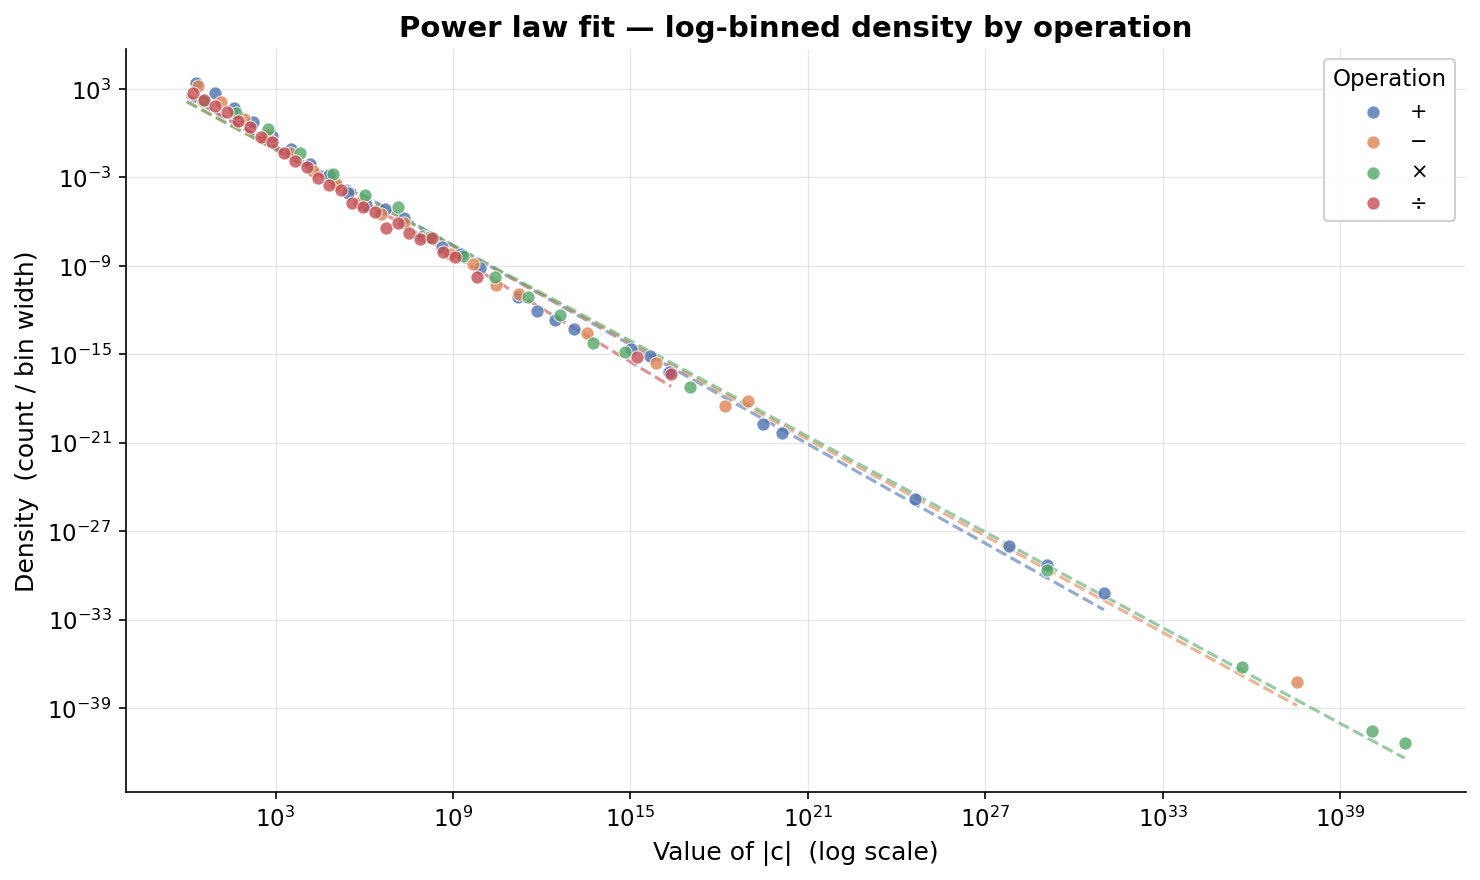

✓ A1 saved


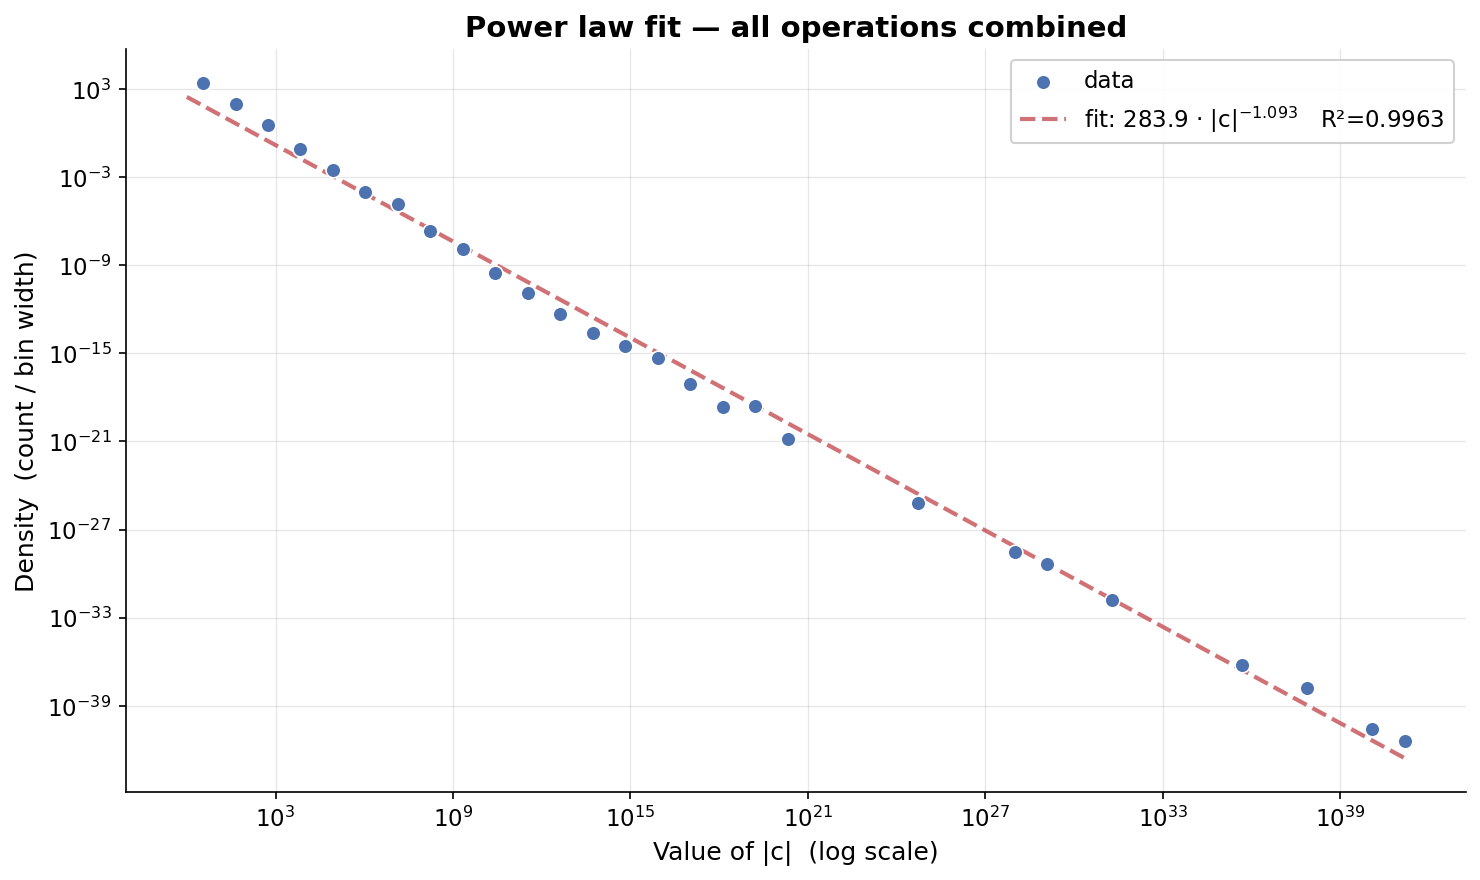

✓ A2 saved


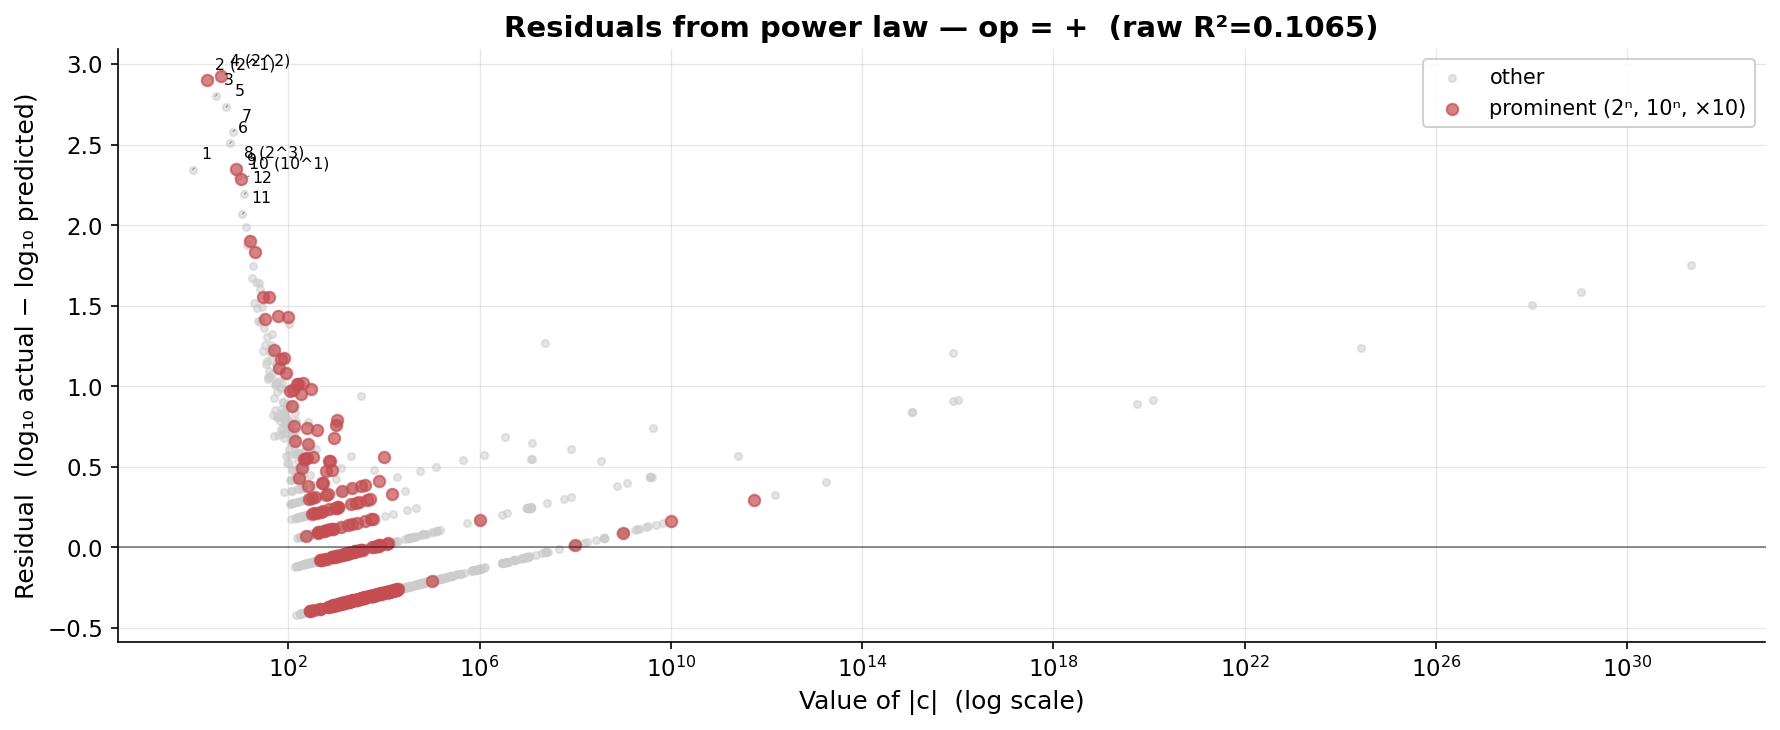

✓ fit_B_residuals_add.png saved


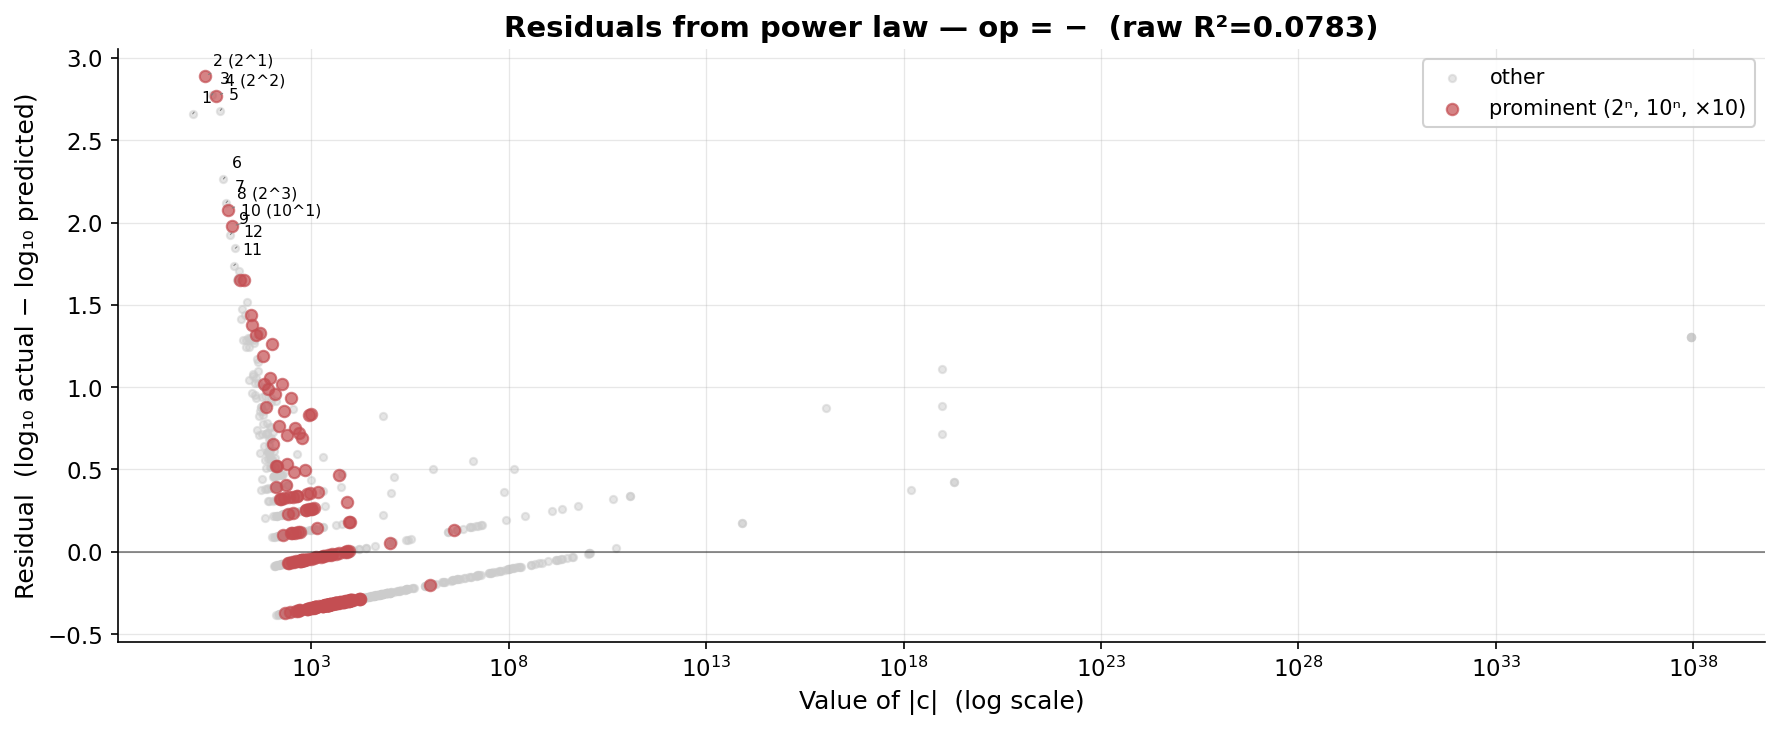

✓ fit_B_residuals_sub.png saved


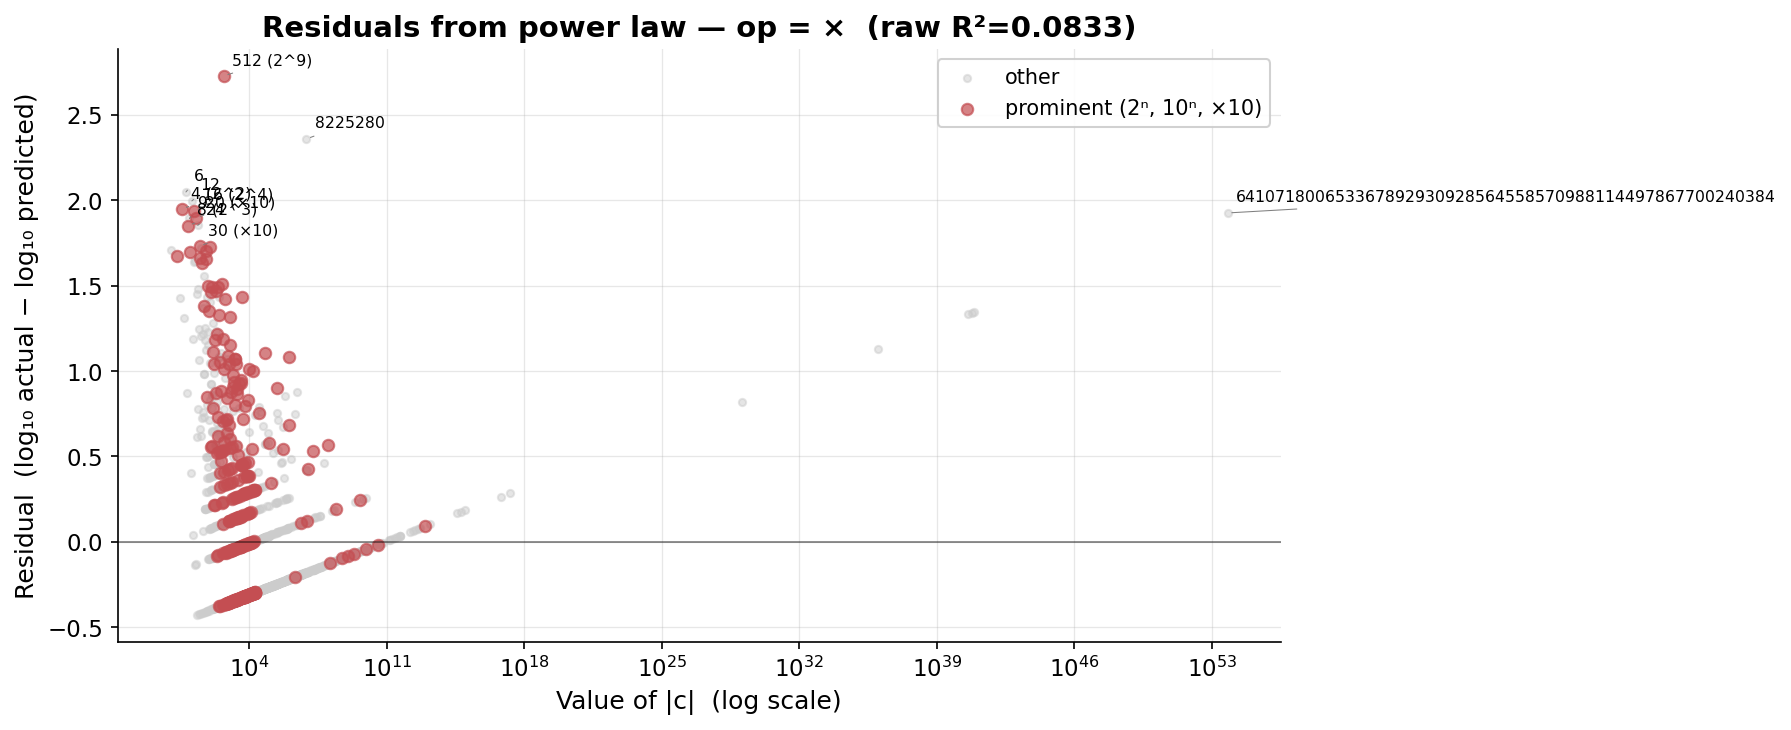

✓ fit_B_residuals_mul.png saved


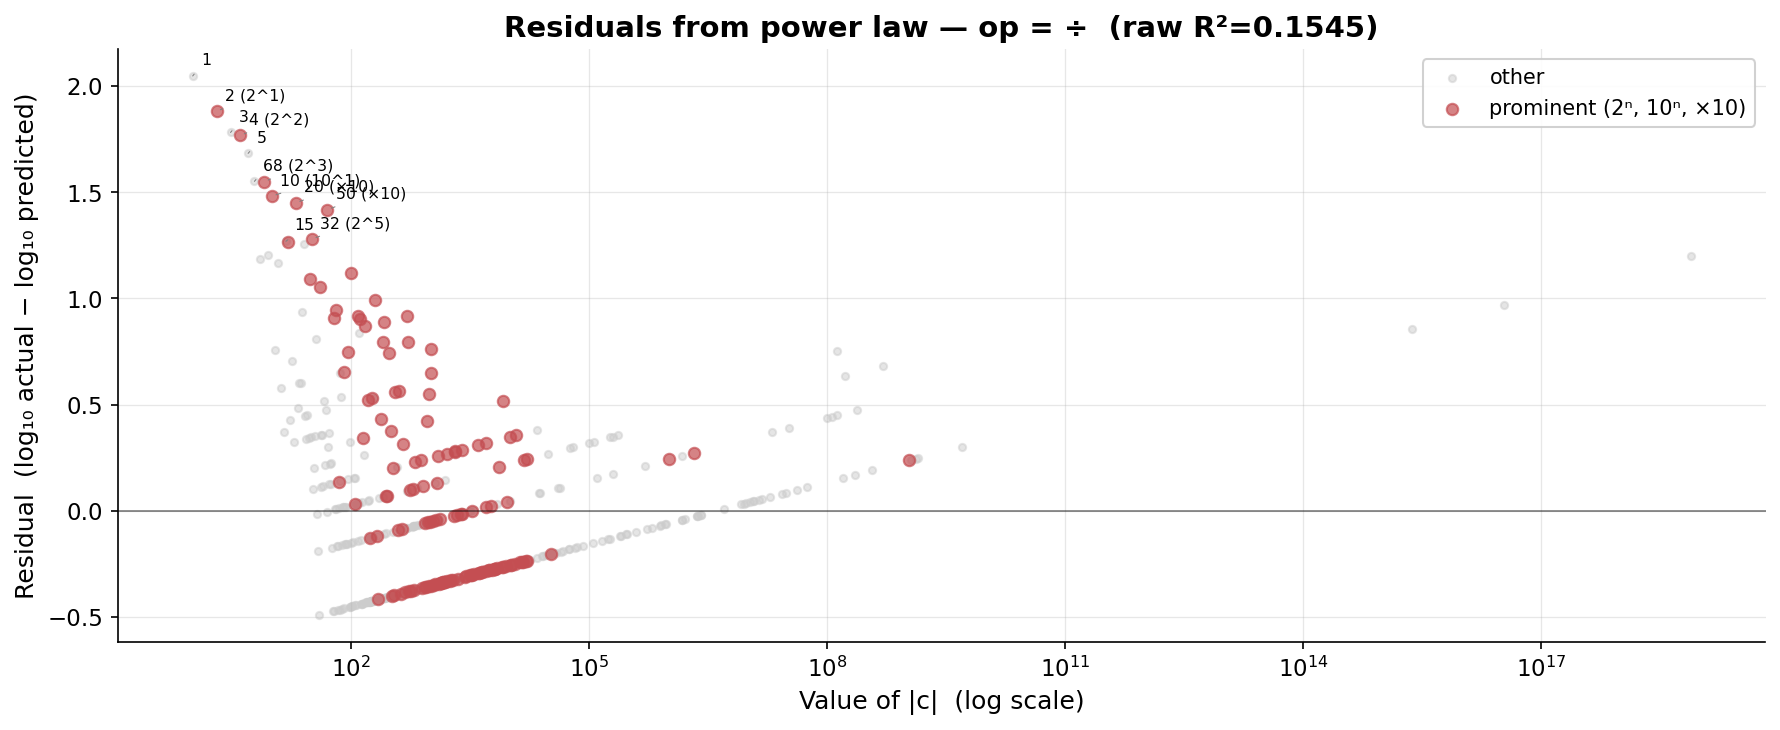

✓ fit_B_residuals_div.png saved


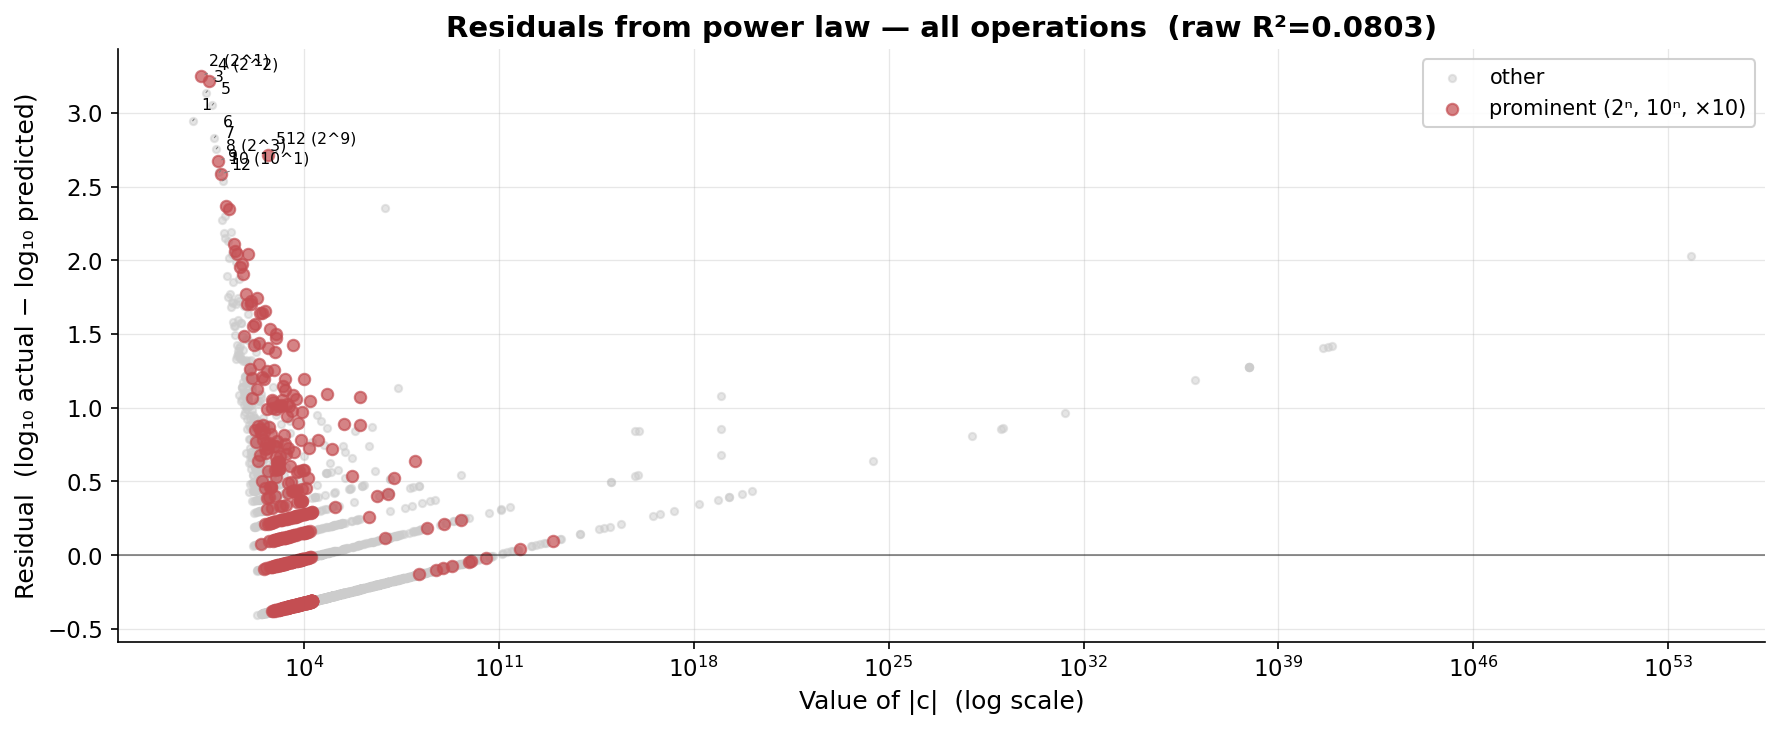

✓ fit_B_residuals_All.png saved


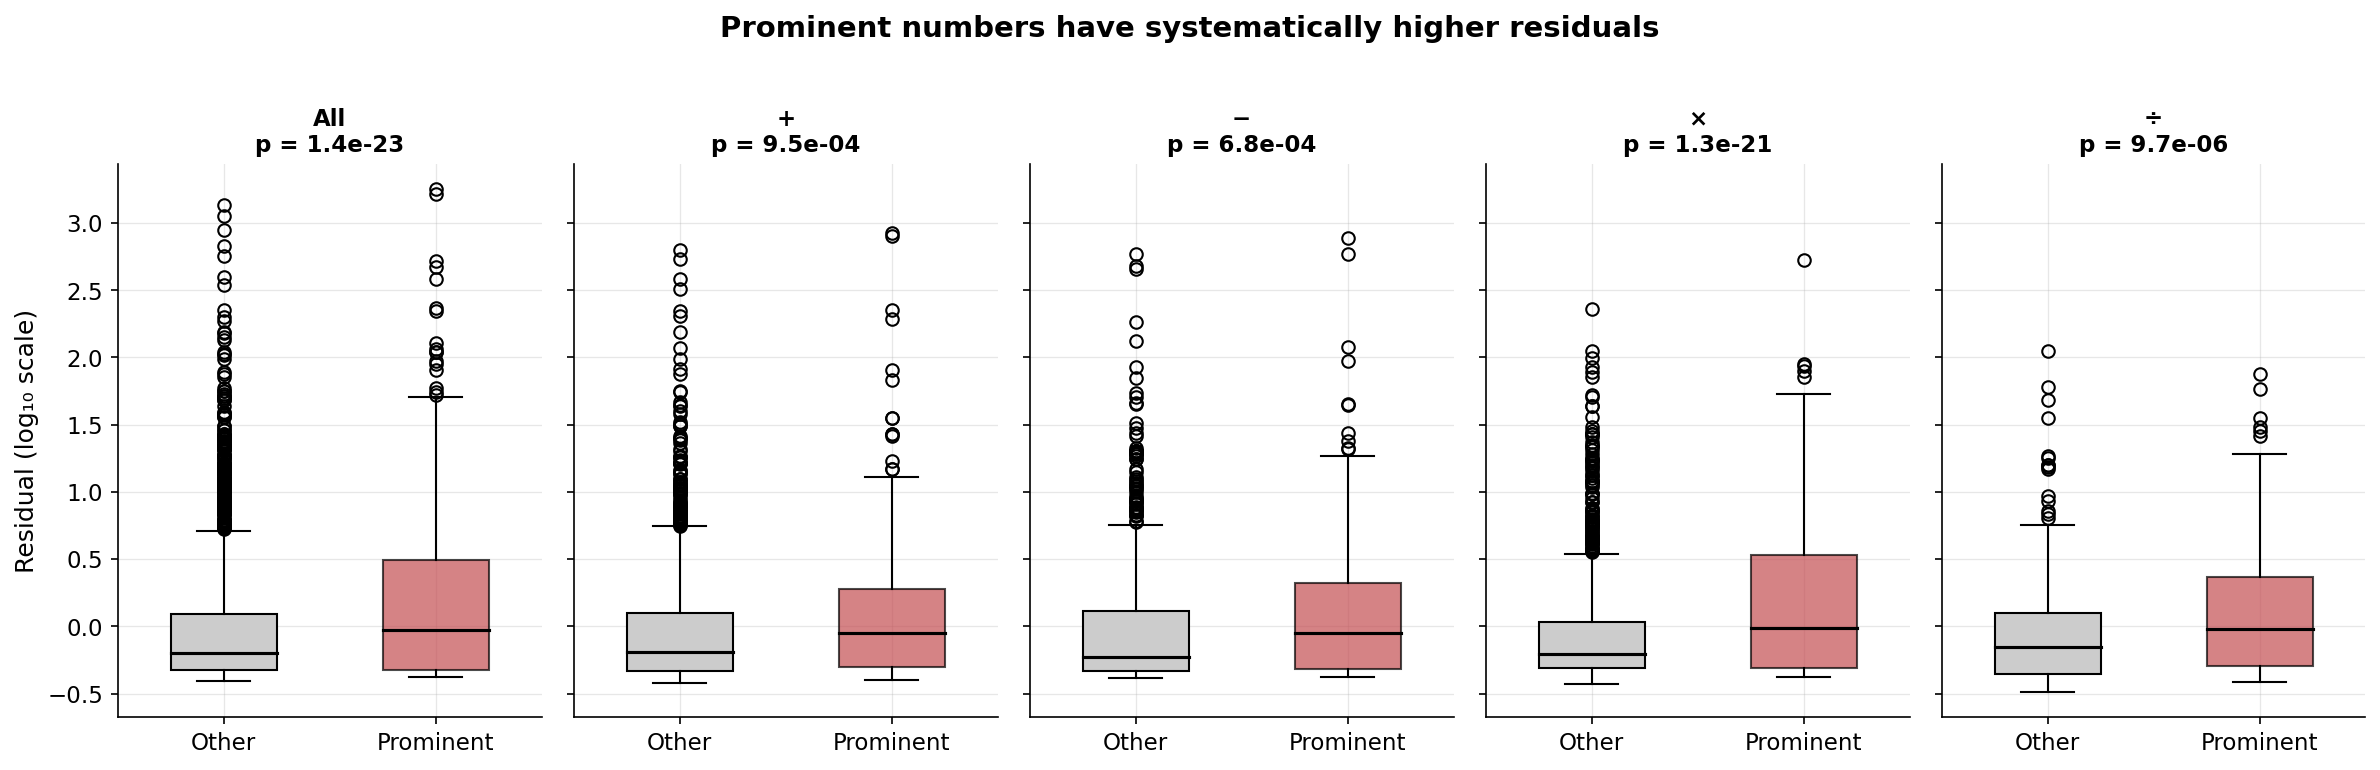

✓ C saved


TOP 15 POSITIVE RESIDUALS PER CURVE  (more frequent than power law predicts)

  --- All (raw R²=0.0803) ---
  Rank           |c|    Count  Expected   Ratio    Resid             Note
     1             2     5621       3.2  1776.8x    3.250              2^1
     2             4     5053       3.1  1650.4x    3.218              2^2
     3             3     4251       3.1  1369.7x    3.137                 
     4             5     3412       3.0  1126.2x    3.052                 
     5             1     2882       3.3  881.7x    2.945                 
     6             6     2035       3.0  677.5x    2.831                 
     7             7     1696       3.0  568.8x    2.755                 
     8           512     1267       2.4  520.4x    2.716              2^9
     9             8     1388       3.0  468.4x    2.671              2^3
    10             9     1163       2.9  394.7x    2.596                 
    11            10     1124       2.9  383.4x    2.584      

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# ─────────────────────────────────────────────
# 0.  Global style
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.alpha":         0.30,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     14,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "0.8",
    "figure.dpi":         150,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]

# ─────────────────────────────────────────────
# 1.  Load & prep data
# ─────────────────────────────────────────────
path = "pile_arith_matches_full_copy_backup.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["c"] = df["c"].apply(lambda x: int(x))
df["c_abs"] = df["c"].abs()

OP_MAP = {"+": "+", "\uff0b": "+", "-": "−", "\uff0d": "−",
          "*": "×", "\uff0a": "×", "×": "×",
          "/": "÷", "\uff0f": "÷", "÷": "÷"}
df["op_label"] = df["op"].astype(str).str.strip().map(OP_MAP).fillna(df["op"])


# ─────────────────────────────────────────────
# 2.  Define prominent / culturally notable numbers
# ─────────────────────────────────────────────
powers_of_2  = {2**i for i in range(1, 60)}
powers_of_10 = {10**i for i in range(1, 20)}
multiples_of_10  = {i * 10 for i in range(1, 2000)}
multiples_of_100 = {i * 100 for i in range(1, 200)}
prominent = powers_of_2 | powers_of_10 | multiples_of_10

def label_number(v):
    """Return a short label for culturally notable numbers."""
    v = int(v)
    parts = []
    if v in powers_of_2:
        parts.append(f"2^{int(np.log2(v))}")
    if v in powers_of_10:
        parts.append(f"10^{int(np.log10(v))}")
    elif v in multiples_of_100:
        parts.append("×100")
    elif v in multiples_of_10:
        parts.append("×10")
    return ", ".join(parts) if parts else ""


# ─────────────────────────────────────────────
# 3.  Helper: log-binned density + power law fit
# ─────────────────────────────────────────────
N_BINS = 50

def fit_power_law(values, n_bins=N_BINS):
    """
    Bin *values* into log-spaced bins, compute density (count / bin_width),
    then fit log10(density) = slope * log10(bin_centre) + intercept.
    Returns dict with fit params, bin data, and per-raw-value residuals.
    """
    vals = values[values >= 1].astype(float)
    bins = np.logspace(0, np.log10(vals.max() + 1), n_bins)
    hv, be = np.histogram(vals, bins=bins)
    widths = be[1:] - be[:-1]
    density = hv / widths
    bc = np.sqrt(be[:-1] * be[1:])  # geometric midpoint

    mask = hv > 0
    log_x = np.log10(bc[mask])
    log_y = np.log10(density[mask])

    slope, intercept, r, p, se = stats.linregress(log_x, log_y)

    # Per-raw-value residuals  (for the residual scatter plots)
    counts_raw = pd.Series(values[values >= 1]).value_counts().sort_index()
    cx = counts_raw.index.values.astype(float)
    cy = counts_raw.values.astype(float)
    predicted_log_count = slope * np.log10(cx) + intercept + np.log10(
        1.0)  # density ≈ count when bin_width=1 (only approximate)
    # Better: predict count from density * approx_local_bin_width
    # For per-value residuals, just use log(count) vs linear fit in log-log
    log_cx = np.log10(cx)
    log_cy = np.log10(cy)
    slope_raw, intercept_raw, r_raw, _, _ = stats.linregress(log_cx, log_cy)
    predicted_raw = slope_raw * log_cx + intercept_raw
    residuals_raw = log_cy - predicted_raw

    return {
        "slope": slope, "intercept": intercept, "r2": r**2,
        "a": 10**intercept, "b": slope,
        "bin_centres": bc[mask], "bin_density": density[mask],
        "log_x": log_x, "log_y": log_y,
        # raw-value level (for residual analysis)
        "raw_x": cx, "raw_y": cy, "raw_residuals": residuals_raw,
        "raw_slope": slope_raw, "raw_intercept": intercept_raw, "raw_r2": r_raw**2,
    }


# ─────────────────────────────────────────────
# 4.  Fit all curves
# ─────────────────────────────────────────────
datasets = {}
for op in ["+", "−", "×", "÷"]:
    vals = df[df["op_label"] == op]["c_abs"].values
    datasets[op] = fit_power_law(vals)

datasets["All"] = fit_power_law(df["c_abs"].values)

# Print summary table
print("=" * 75)
print("POWER LAW FITS  (log-binned density)")
print("  density(|c|) = a · |c|^b")
print("=" * 75)
print(f"  {'':>4}  {'a':>10}  {'b (slope)':>10}  {'R²':>8}")
print(f"  {'':>4}  {'─'*10}  {'─'*10}  {'─'*8}")
for name in ["All", "+", "−", "×", "÷"]:
    d = datasets[name]
    print(f"  {name:>4}  {d['a']:>10.2f}  {d['b']:>10.4f}  {d['r2']:>8.4f}")

print("\n" + "=" * 75)
print("RAW VALUE FITS  (log(count) vs log(|c|), per unique |c|)")
print("  count(|c|) = a · |c|^b")
print("=" * 75)
print(f"  {'':>4}  {'a':>10}  {'b (slope)':>10}  {'R²':>8}")
print(f"  {'':>4}  {'─'*10}  {'─'*10}  {'─'*8}")
for name in ["All", "+", "−", "×", "÷"]:
    d = datasets[name]
    print(f"  {name:>4}  {10**d['raw_intercept']:>10.2f}  {d['raw_slope']:>10.4f}  {d['raw_r2']:>8.4f}")


# ═══════════════════════════════════════════════
# PLOT A — Log-log density with power law fit lines
# ═══════════════════════════════════════════════

# A1: All operations on one plot
fig, ax = plt.subplots(figsize=(10, 6))
for i, name in enumerate(["+", "−", "×", "÷"]):
    d = datasets[name]
    ax.scatter(d["bin_centres"], d["bin_density"], color=PALETTE[i],
               s=40, zorder=3, label=name, alpha=0.8, edgecolors="white", linewidths=0.5)
    # fit line
    x_fit = np.logspace(0, np.log10(d["bin_centres"].max()), 200)
    y_fit = d["a"] * x_fit ** d["b"]
    ax.plot(x_fit, y_fit, color=PALETTE[i], linewidth=1.5, alpha=0.6, linestyle="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Value of |c|  (log scale)")
ax.set_ylabel("Density  (count / bin width)")
ax.set_title("Power law fit — log-binned density by operation")
ax.legend(title="Operation")
fig.tight_layout()
fig.savefig("fit_A1_loglog_by_op.png")
plt.show()
print("✓ A1 saved")

# A2: All combined
fig, ax = plt.subplots(figsize=(10, 6))
d = datasets["All"]
ax.scatter(d["bin_centres"], d["bin_density"], color=PALETTE[0],
           s=50, zorder=3, label="data", edgecolors="white", linewidths=0.8)
x_fit = np.logspace(0, np.log10(d["bin_centres"].max()), 200)
y_fit = d["a"] * x_fit ** d["b"]
ax.plot(x_fit, y_fit, color=PALETTE[3], linewidth=2, alpha=0.8, linestyle="--",
        label=f"fit: {d['a']:.1f} · |c|$^{{{d['b']:.3f}}}$   R²={d['r2']:.4f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Value of |c|  (log scale)")
ax.set_ylabel("Density  (count / bin width)")
ax.set_title("Power law fit — all operations combined")
ax.legend(fontsize=11)
fig.tight_layout()
fig.savefig("fit_A2_loglog_all.png")
plt.show()
print("✓ A2 saved")


# ═══════════════════════════════════════════════
# PLOT B — Residuals from raw count fit, highlighting prominent numbers
# ═══════════════════════════════════════════════

for plot_name, names_to_plot in [("by_op", ["+", "−", "×", "÷"]), ("all", ["All"])]:
    for name in names_to_plot:
        d = datasets[name]
        cx = d["raw_x"]
        residuals = d["raw_residuals"]
        r2 = d["raw_r2"]

        prom_mask = np.array([int(v) in prominent for v in cx])
        other_mask = ~prom_mask

        fig, ax = plt.subplots(figsize=(12, 5))

        # Other points (grey)
        ax.scatter(cx[other_mask], residuals[other_mask], color="#CCCCCC",
                   s=12, alpha=0.5, zorder=1, label="other")
        # Prominent points (red)
        ax.scatter(cx[prom_mask], residuals[prom_mask], color=PALETTE[3],
                   s=30, alpha=0.7, zorder=2, label="prominent (2ⁿ, 10ⁿ, ×10)")

        # Annotate the top outliers
        top_n = 12
        top_idx = np.argsort(residuals)[::-1][:top_n]
        for idx in top_idx:
            v = int(cx[idx])
            lbl = label_number(v)
            txt = f"{v}" + (f" ({lbl})" if lbl else "")
            ax.annotate(txt, (cx[idx], residuals[idx]),
                        fontsize=7.5, ha="left", va="bottom",
                        xytext=(4, 4), textcoords="offset points",
                        arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))

        ax.axhline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel("Value of |c|  (log scale)")
        ax.set_ylabel("Residual  (log₁₀ actual − log₁₀ predicted)")
        title_op = f"op = {name}" if name != "All" else "all operations"
        ax.set_title(f"Residuals from power law — {title_op}  (raw R²={r2:.4f})")
        ax.legend(loc="upper right")
        fig.tight_layout()
        fname = f"fit_B_residuals_{name.replace('÷','div').replace('×','mul').replace('+','add').replace('−','sub')}.png"
        fig.savefig(fname)
        plt.show()
        print(f"✓ {fname} saved")


# ═══════════════════════════════════════════════
# PLOT C — Residual distributions: prominent vs other (box / violin)
# ═══════════════════════════════════════════════

fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)
for i, name in enumerate(["All", "+", "−", "×", "÷"]):
    d = datasets[name]
    cx = d["raw_x"]
    residuals = d["raw_residuals"]

    prom_mask = np.array([int(v) in prominent for v in cx])
    res_prom = residuals[prom_mask]
    res_other = residuals[~prom_mask]

    ax = axes[i]
    bp = ax.boxplot([res_other, res_prom], labels=["Other", "Prominent"],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.5))
    bp["boxes"][0].set_facecolor("#CCCCCC")
    bp["boxes"][1].set_facecolor(PALETTE[3])
    bp["boxes"][1].set_alpha(0.7)

    # t-test
    t_stat, t_p = stats.ttest_ind(res_prom, res_other)
    ax.set_title(f"{name}\np = {t_p:.1e}", fontsize=11)
    if i == 0:
        ax.set_ylabel("Residual (log₁₀ scale)")

fig.suptitle("Prominent numbers have systematically higher residuals", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("fit_C_boxplot_prominent_vs_other.png")
plt.show()
print("✓ C saved")


# ═══════════════════════════════════════════════
# Summary table: top residuals with annotations
# ═══════════════════════════════════════════════

print("\n\n" + "=" * 85)
print("TOP 15 POSITIVE RESIDUALS PER CURVE  (more frequent than power law predicts)")
print("=" * 85)
for name in ["All", "+", "−", "×", "÷"]:
    d = datasets[name]
    cx = d["raw_x"]
    cy = d["raw_y"]
    residuals = d["raw_residuals"]
    predicted = d["raw_slope"] * np.log10(cx) + d["raw_intercept"]

    top_idx = np.argsort(residuals)[::-1][:15]
    print(f"\n  --- {name} (raw R²={d['raw_r2']:.4f}) ---")
    print(f"  {'Rank':>4}  {'|c|':>12}  {'Count':>7}  {'Expected':>8}  {'Ratio':>6}  {'Resid':>7}  {'Note':>15}")
    for rank, idx in enumerate(top_idx, 1):
        v = int(cx[idx])
        actual = int(cy[idx])
        exp = 10 ** predicted[idx]
        ratio = actual / exp
        res = residuals[idx]
        note = label_number(v)
        print(f"  {rank:>4}  {v:>12}  {actual:>7}  {exp:>8.1f}  {ratio:>5.1f}x  {res:>7.3f}  {note:>15}")

SECTION 1 — Problem-size (all operations)


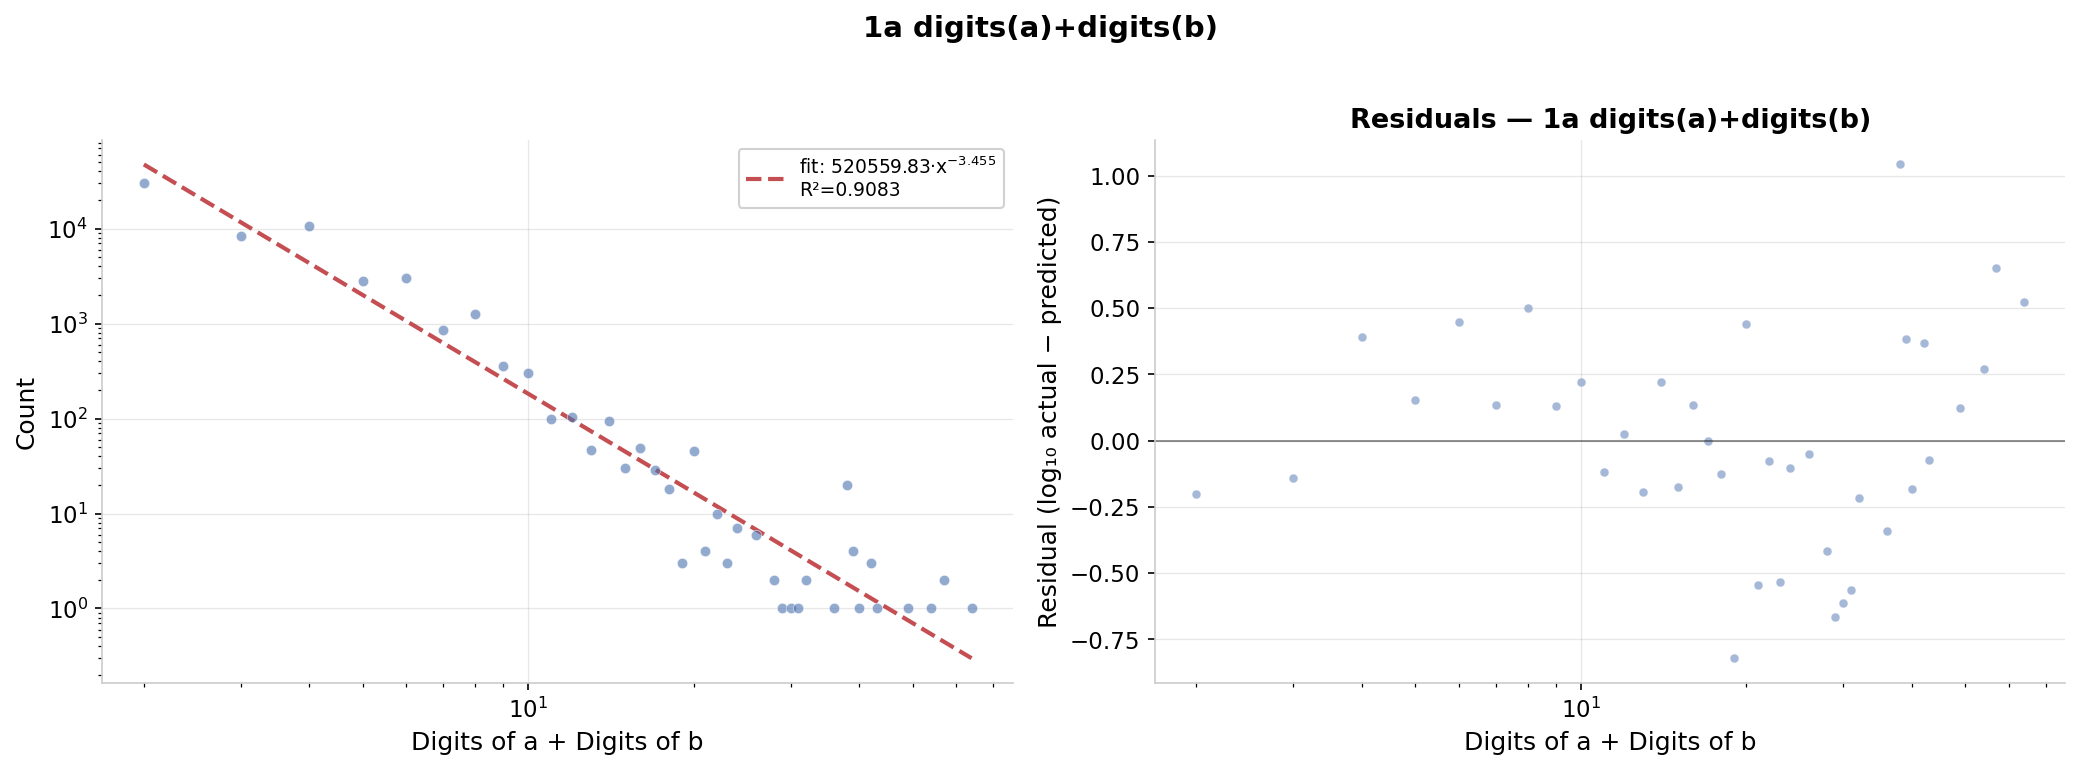

  ✓ 1a digits(a)+digits(b): slope=-3.4550, R²=0.9083


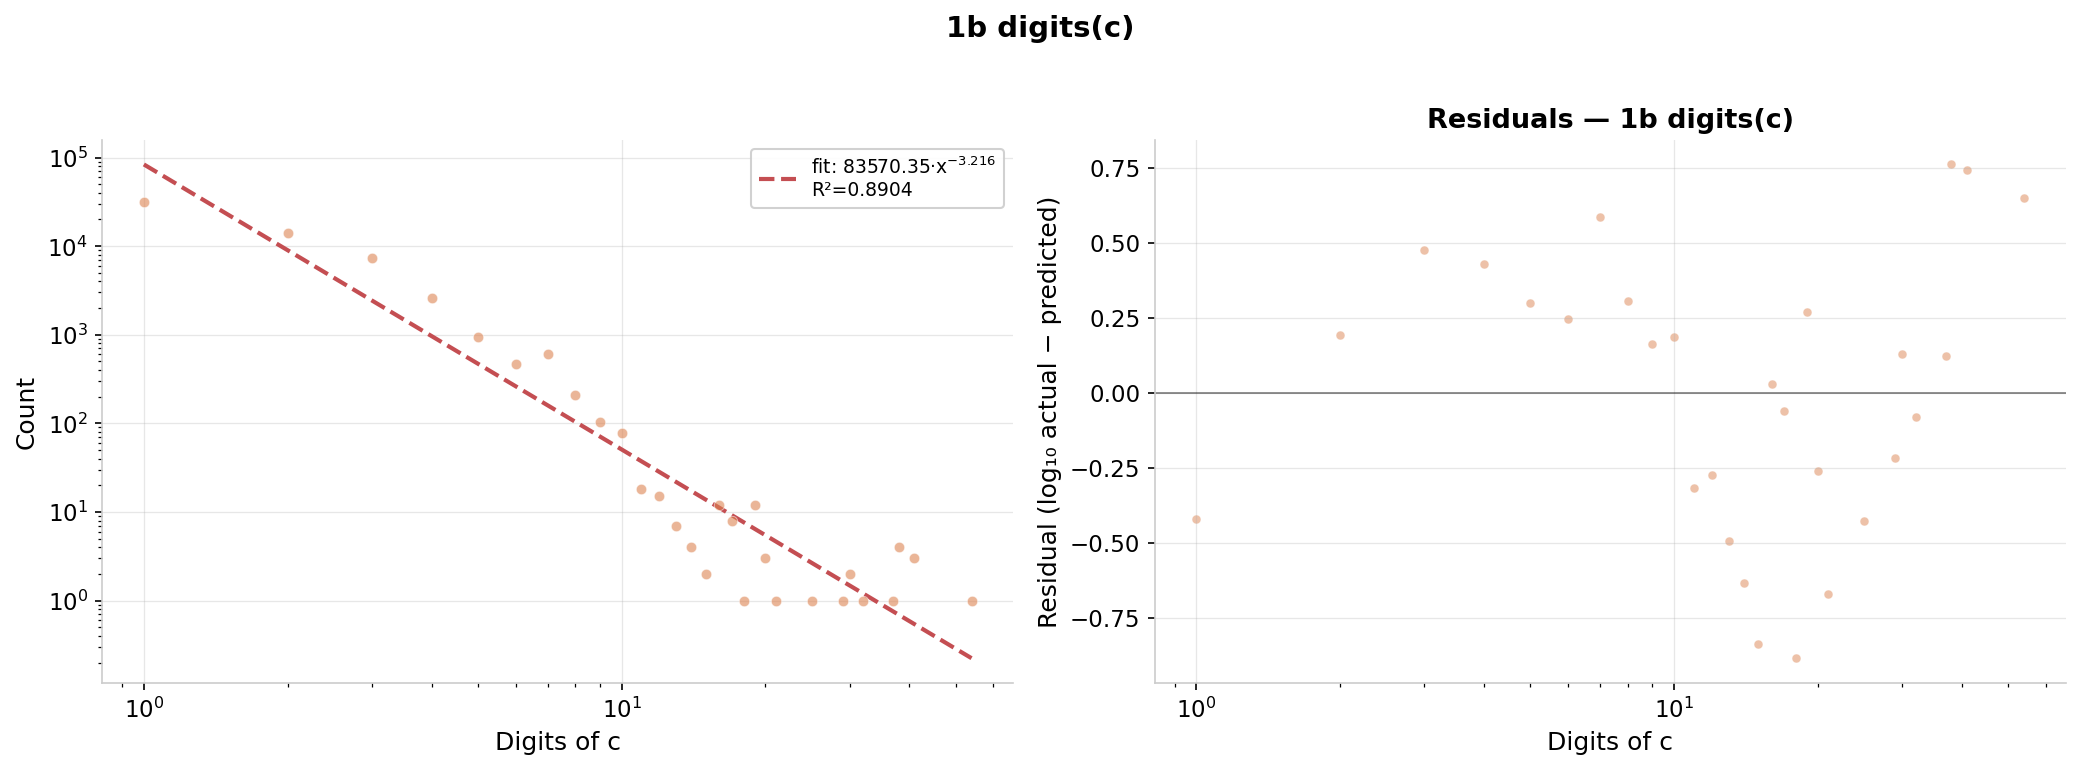

  ✓ 1b digits(c): slope=-3.2161, R²=0.8904


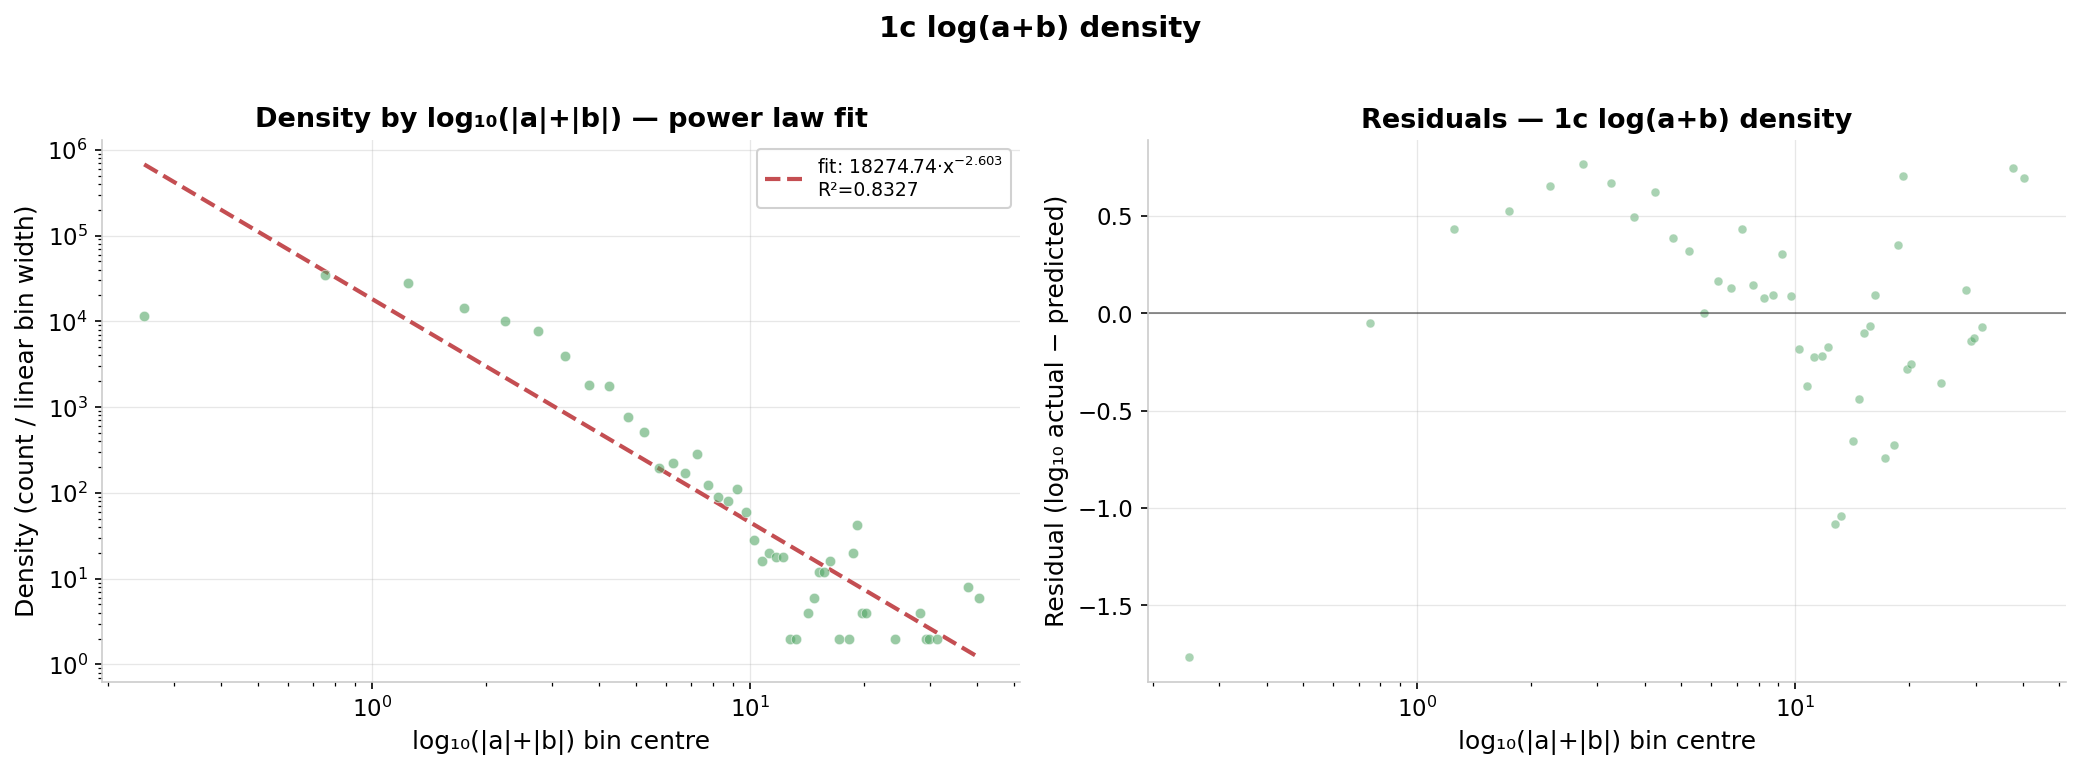

  ✓ 1c log(a+b) density: slope=-2.6033, R²=0.8327
[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5
 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20.  20.5
 21.  21.5 22.  22.5 23.  23.5 24.  24.5 25.  25.5 26.  26.5 27.  27.5
 28.  28.5 29.  29.5 30.  30.5 31.  31.5 32.  32.5 33.  33.5 34.  34.5
 35.  35.5 36.  36.5 37.  37.5 38.  38.5 39.  39.5 40.  40.5 41.  41.5
 42.  42.5 43.  43.5 44.  44.5 45.  45.5 46.  46.5 47.  47.5 48.  48.5
 49.  49.5 50.  50.5 51.  51.5 52.  52.5 53.  53.5 54. ]


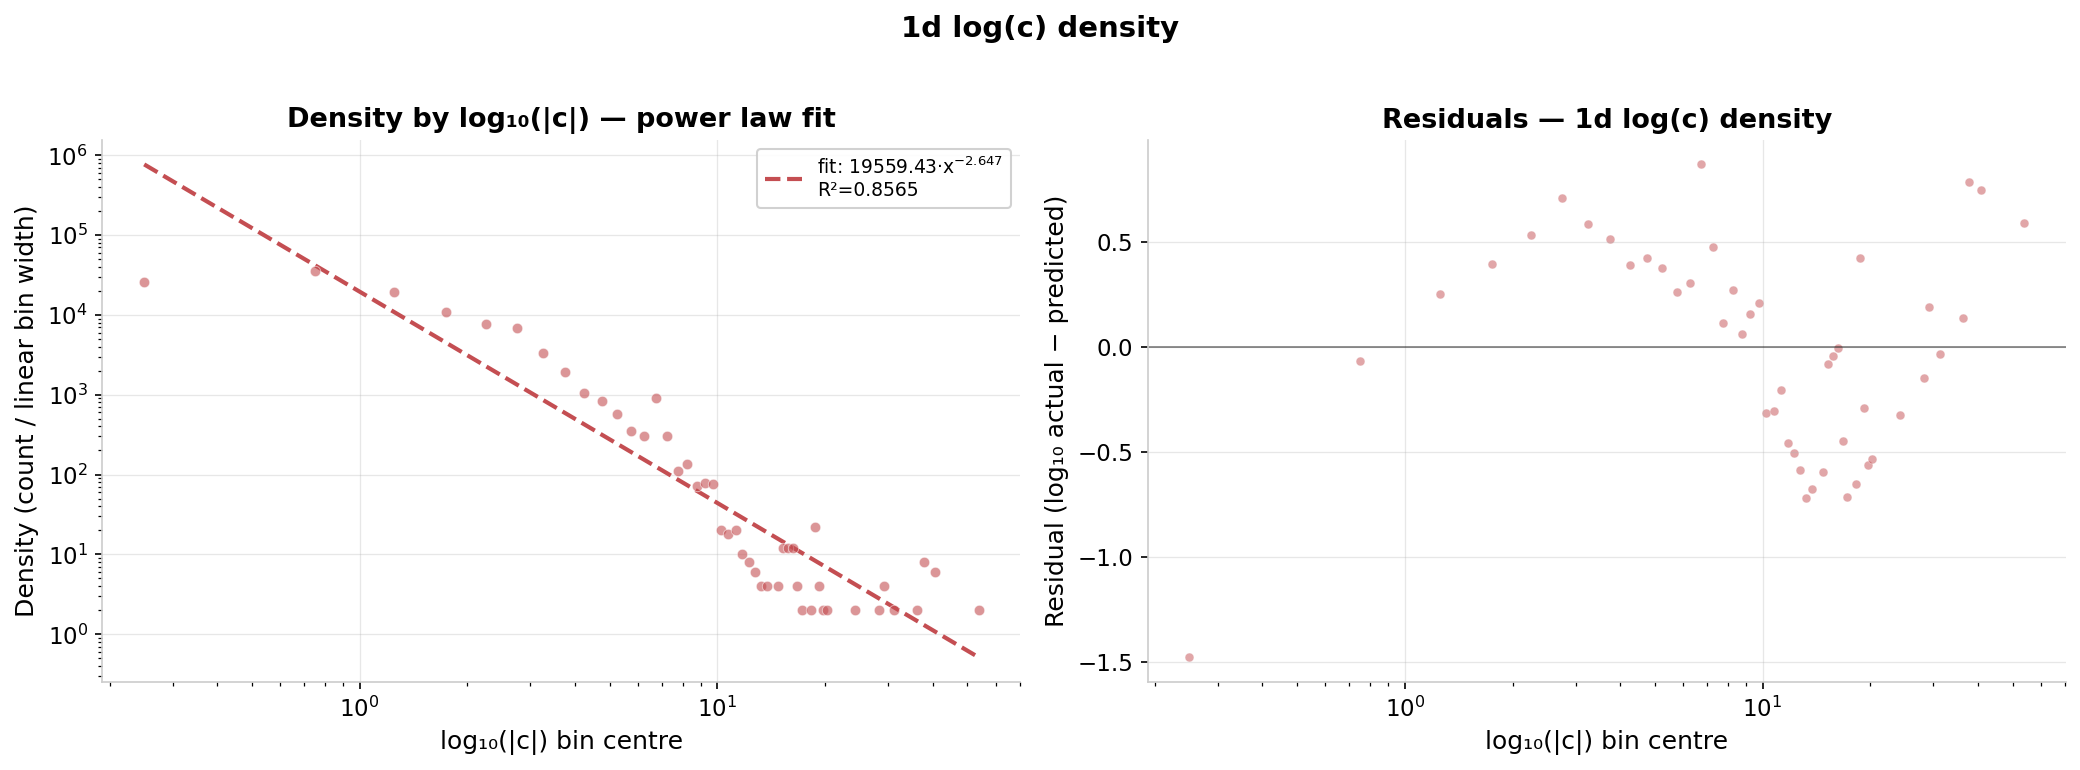

  ✓ 1d log(c) density: slope=-2.6471, R²=0.8565

SECTION 2 — By operation


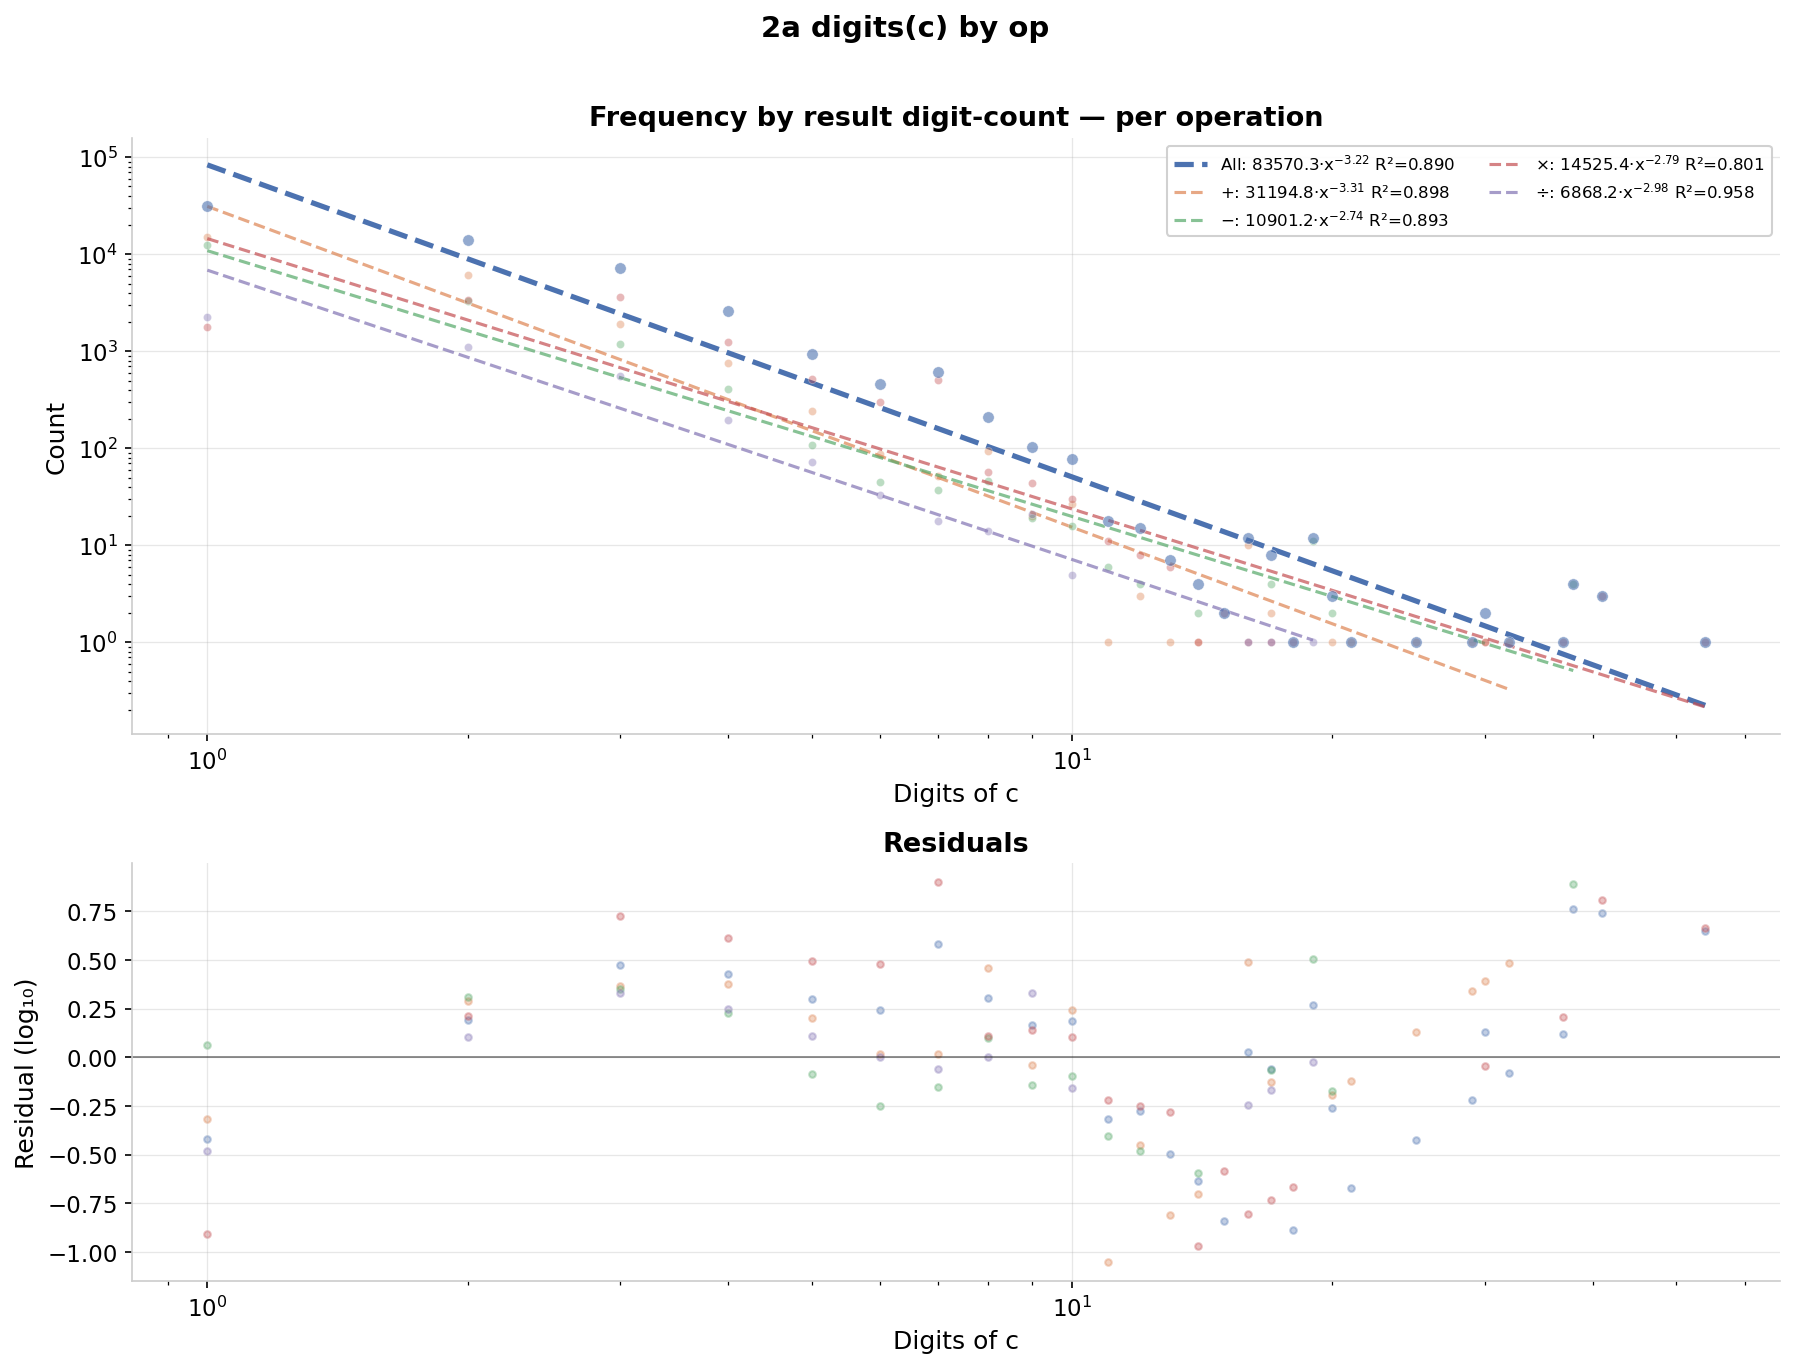

  ✓ 2a digits(c) by op:
       All: slope=-3.2161, R²=0.8904
         +: slope=-3.3067, R²=0.8984
         −: slope=-2.7396, R²=0.8929
         ×: slope=-2.7869, R²=0.8005
         ÷: slope=-2.9824, R²=0.9584


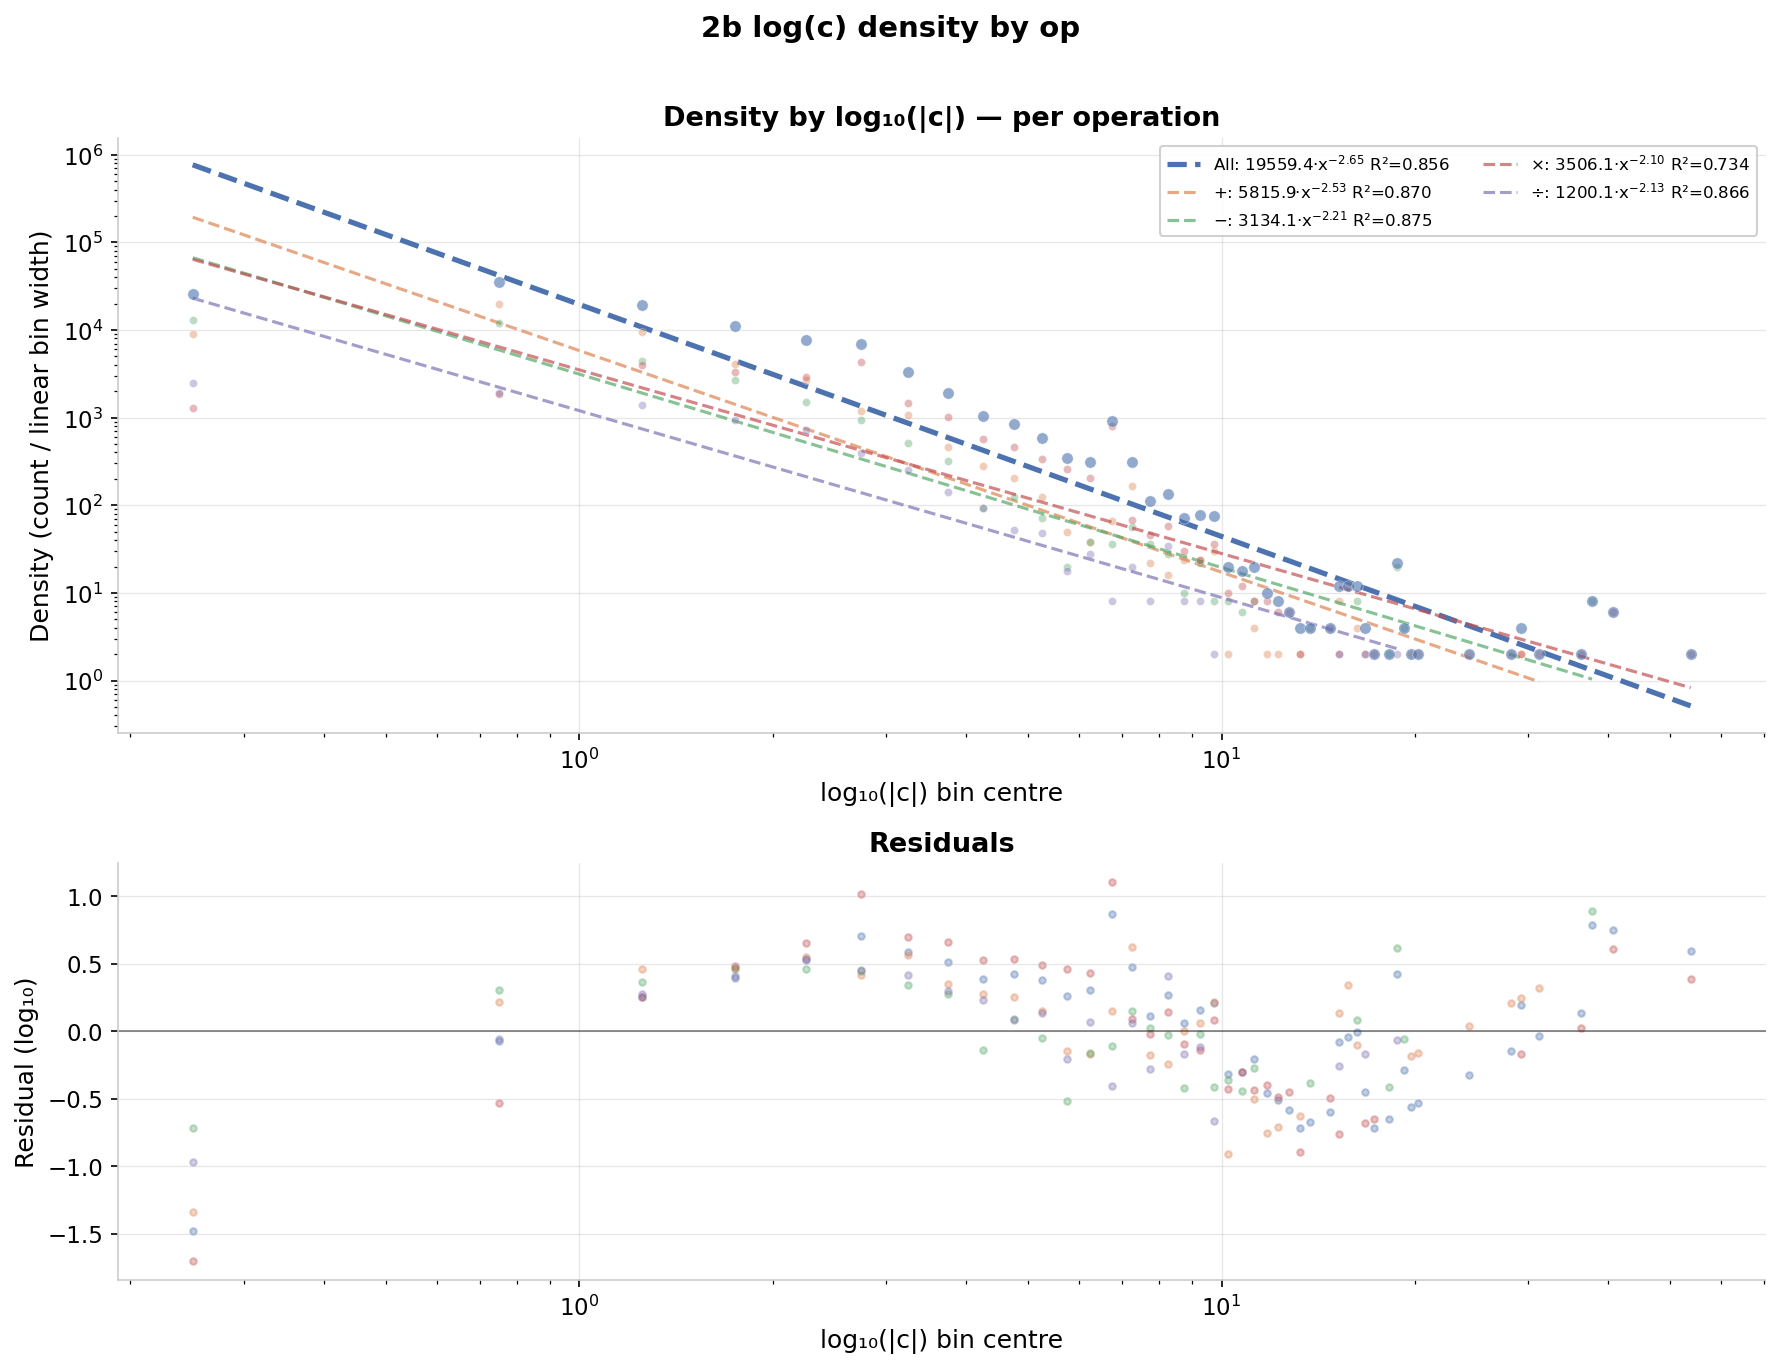

  ✓ 2b log(c) density by op:
       All: slope=-2.6471, R²=0.8565
         +: slope=-2.5288, R²=0.8698
         −: slope=-2.2068, R²=0.8747
         ×: slope=-2.0958, R²=0.7341
         ÷: slope=-2.1328, R²=0.8662

SECTION 3 — By value of |c|


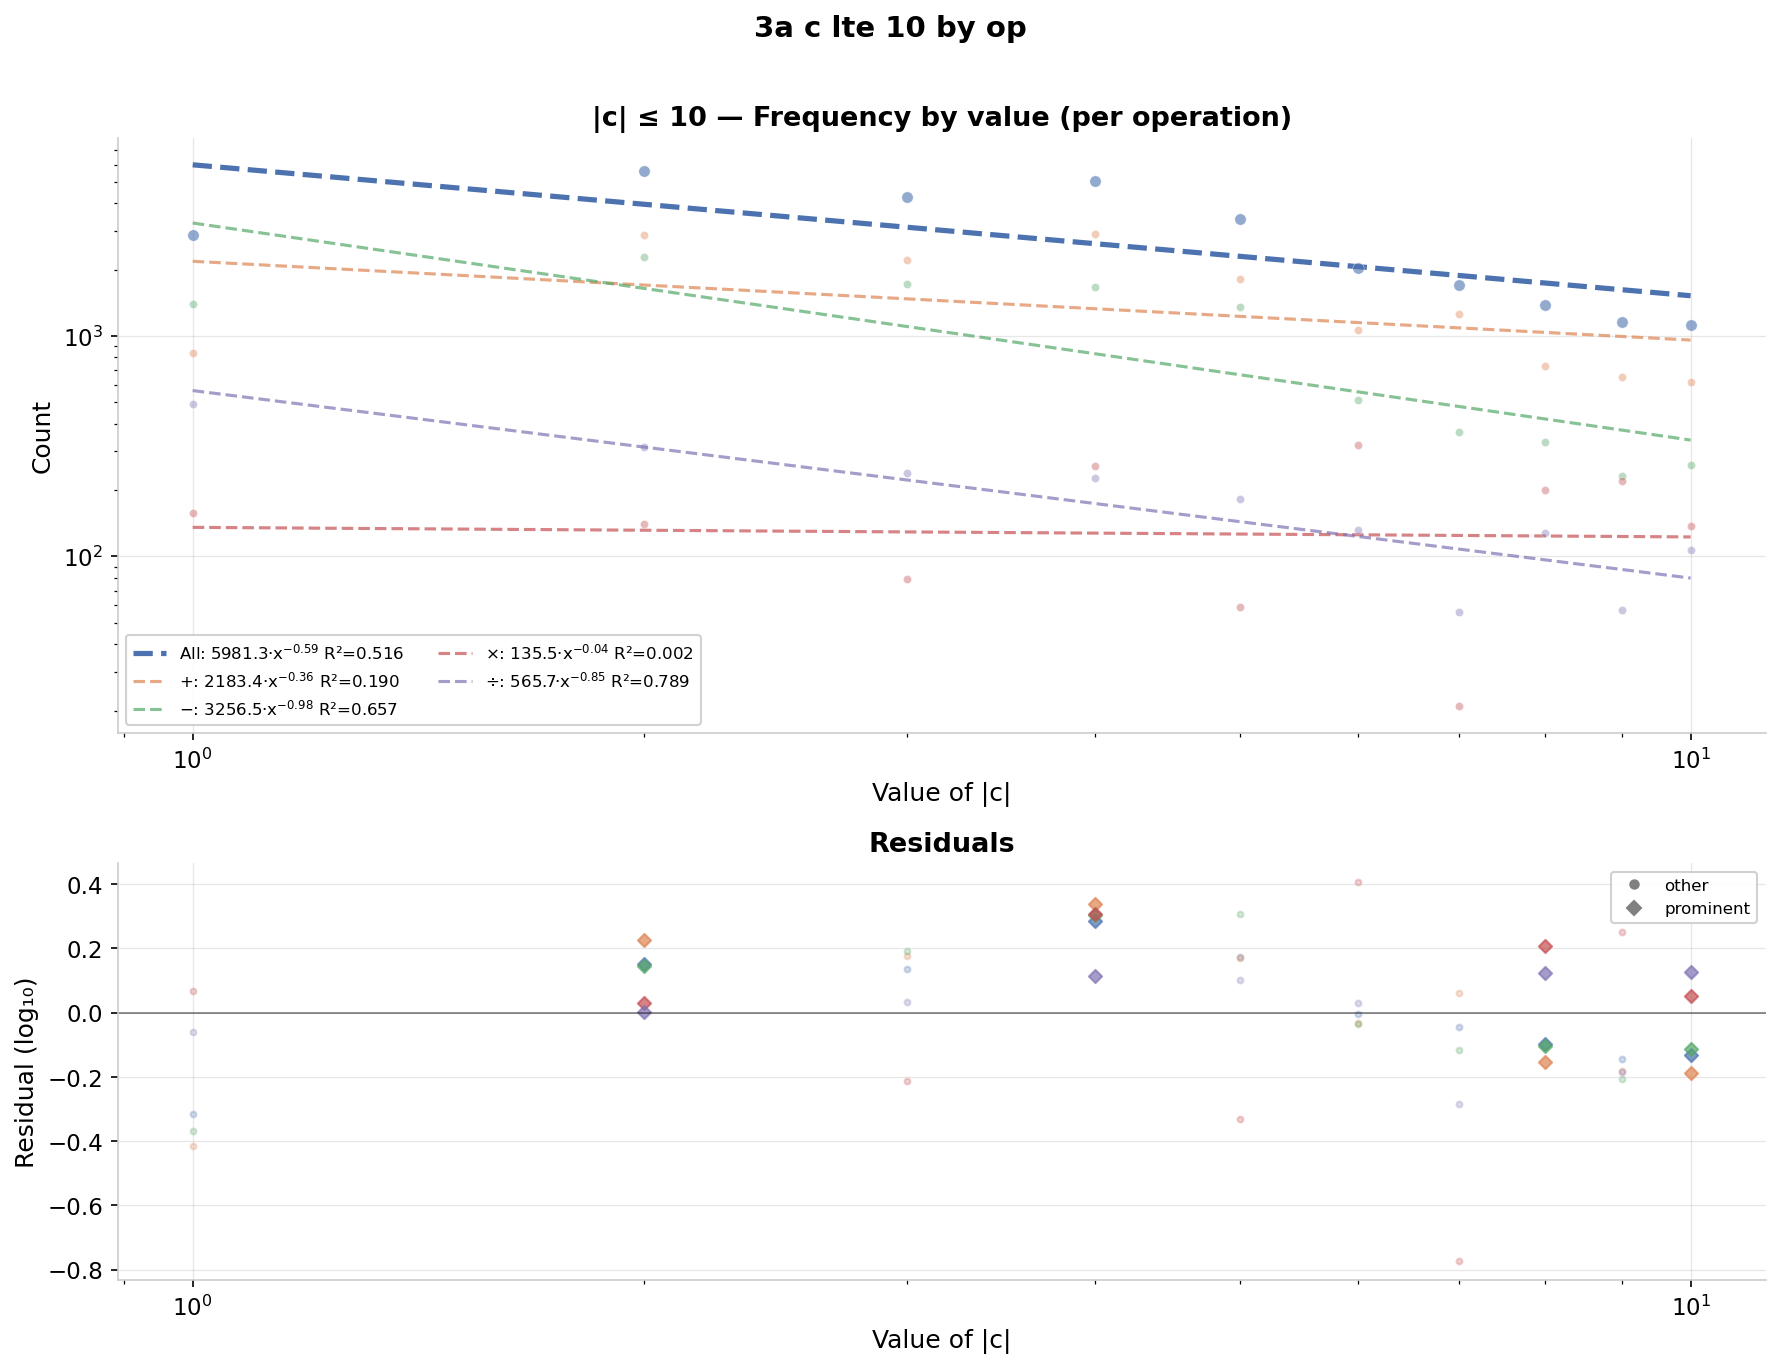

  ✓ 3a c lte 10 by op:
       All: slope=-0.5940, R²=0.5158
         +: slope=-0.3575, R²=0.1903
         −: slope=-0.9847, R²=0.6567
         ×: slope=-0.0434, R²=0.0015
         ÷: slope=-0.8507, R²=0.7895


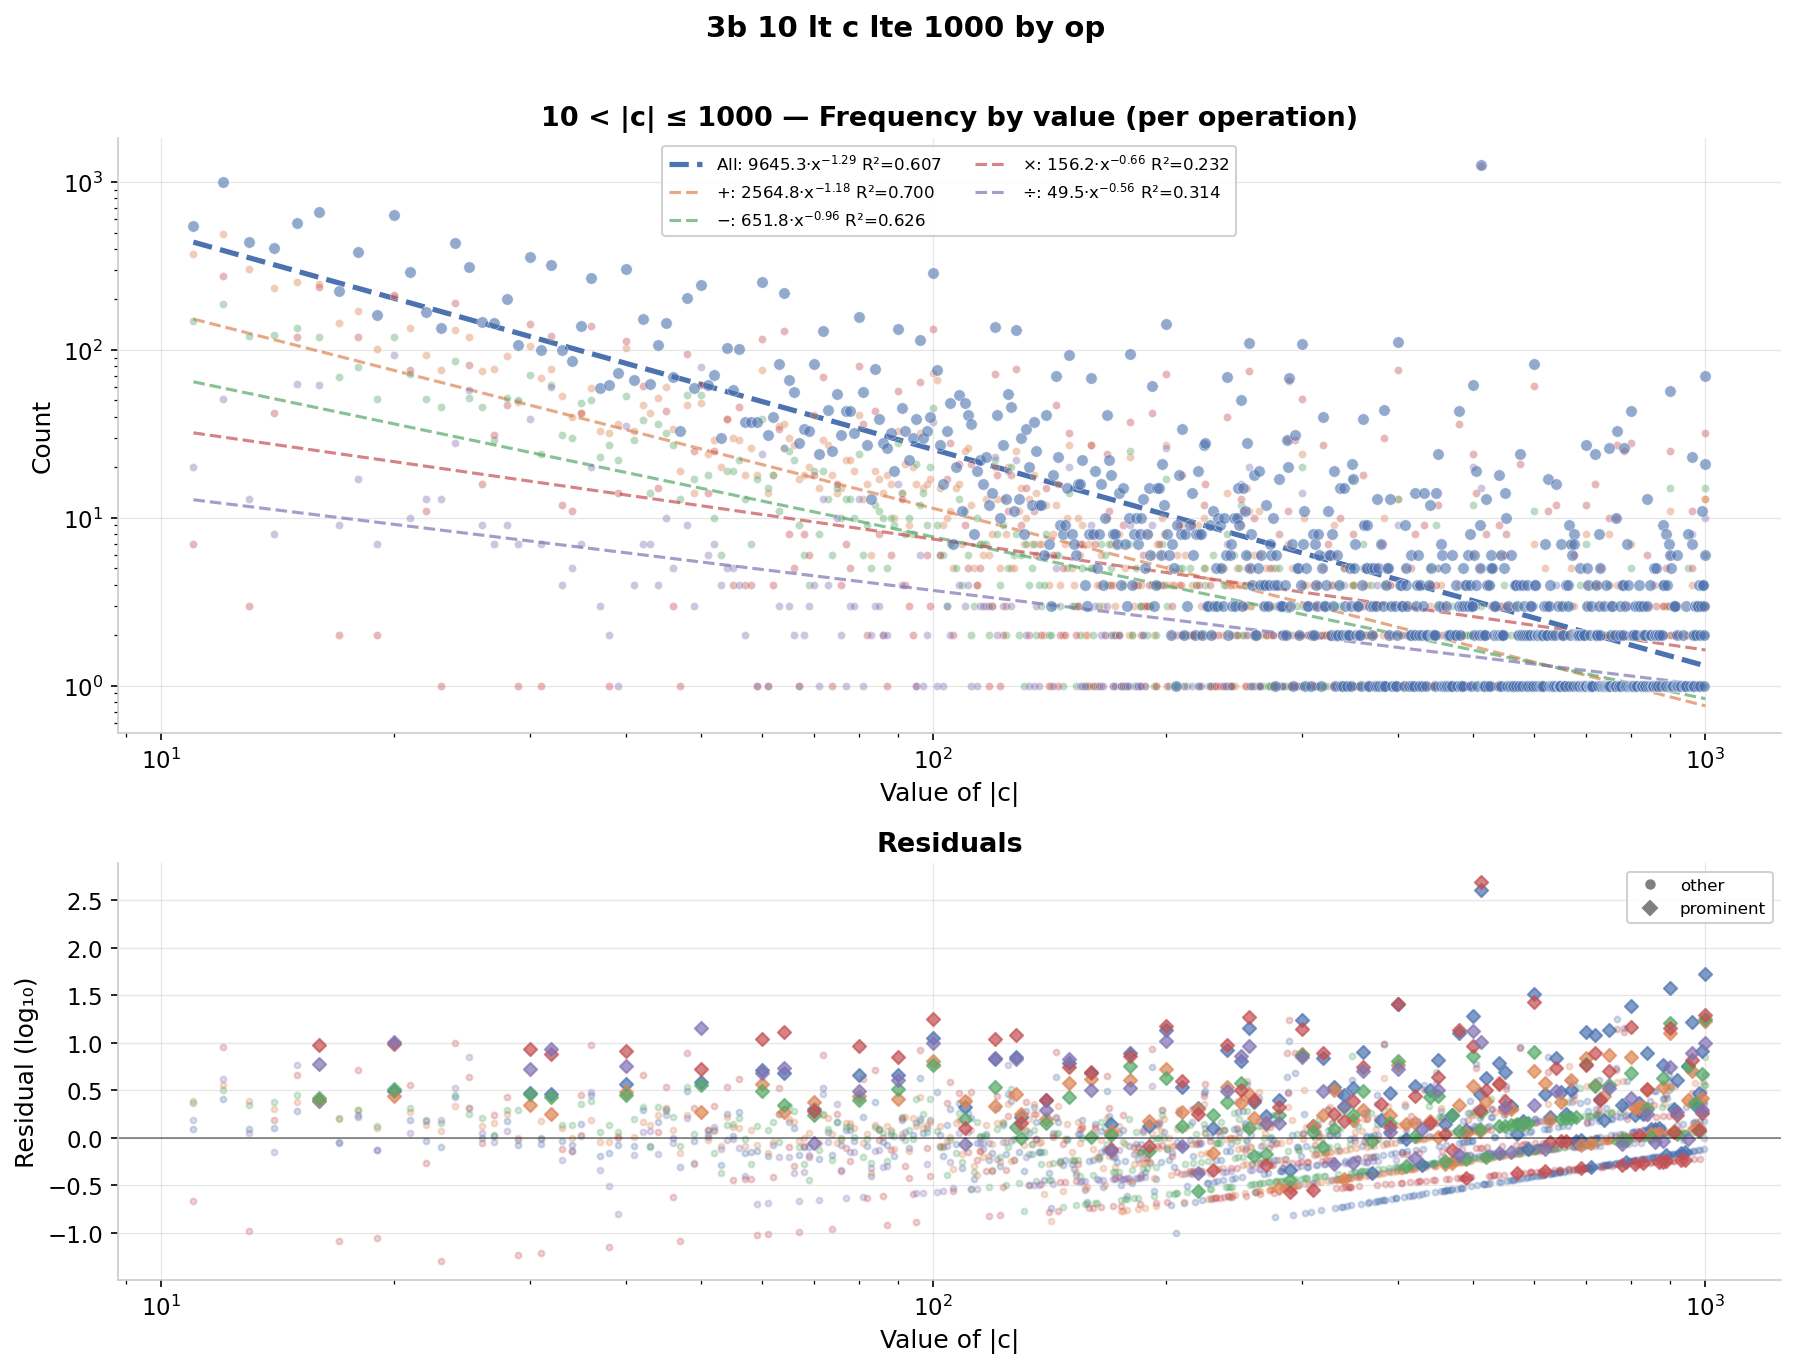

  ✓ 3b 10 lt c lte 1000 by op:
       All: slope=-1.2888, R²=0.6067
         +: slope=-1.1764, R²=0.7004
         −: slope=-0.9640, R²=0.6263
         ×: slope=-0.6604, R²=0.2324
         ÷: slope=-0.5638, R²=0.3140


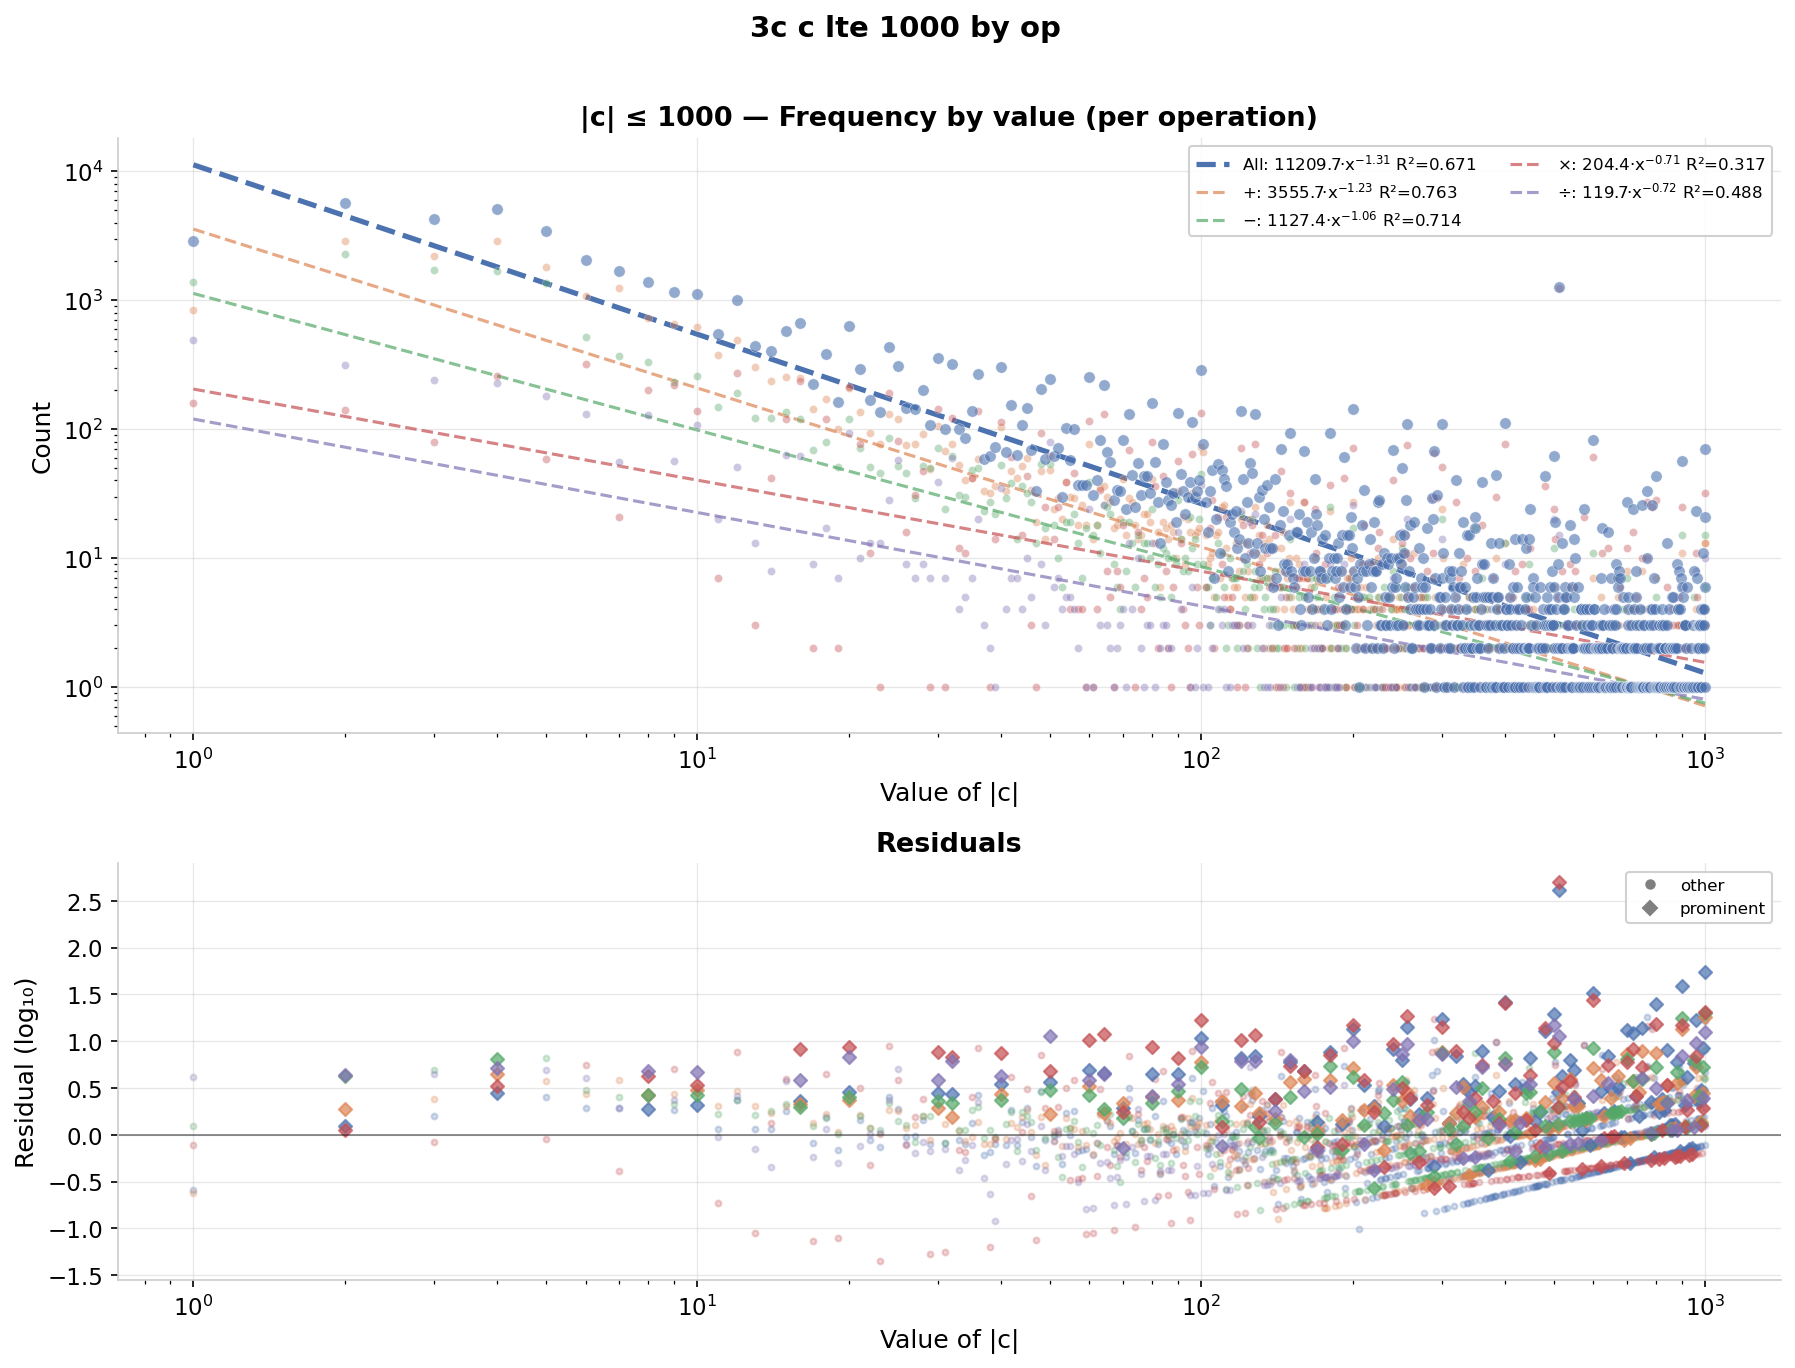

  ✓ 3c c lte 1000 by op:
       All: slope=-1.3138, R²=0.6713
         +: slope=-1.2323, R²=0.7632
         −: slope=-1.0592, R²=0.7141
         ×: slope=-0.7064, R²=0.3169
         ÷: slope=-0.7245, R²=0.4877


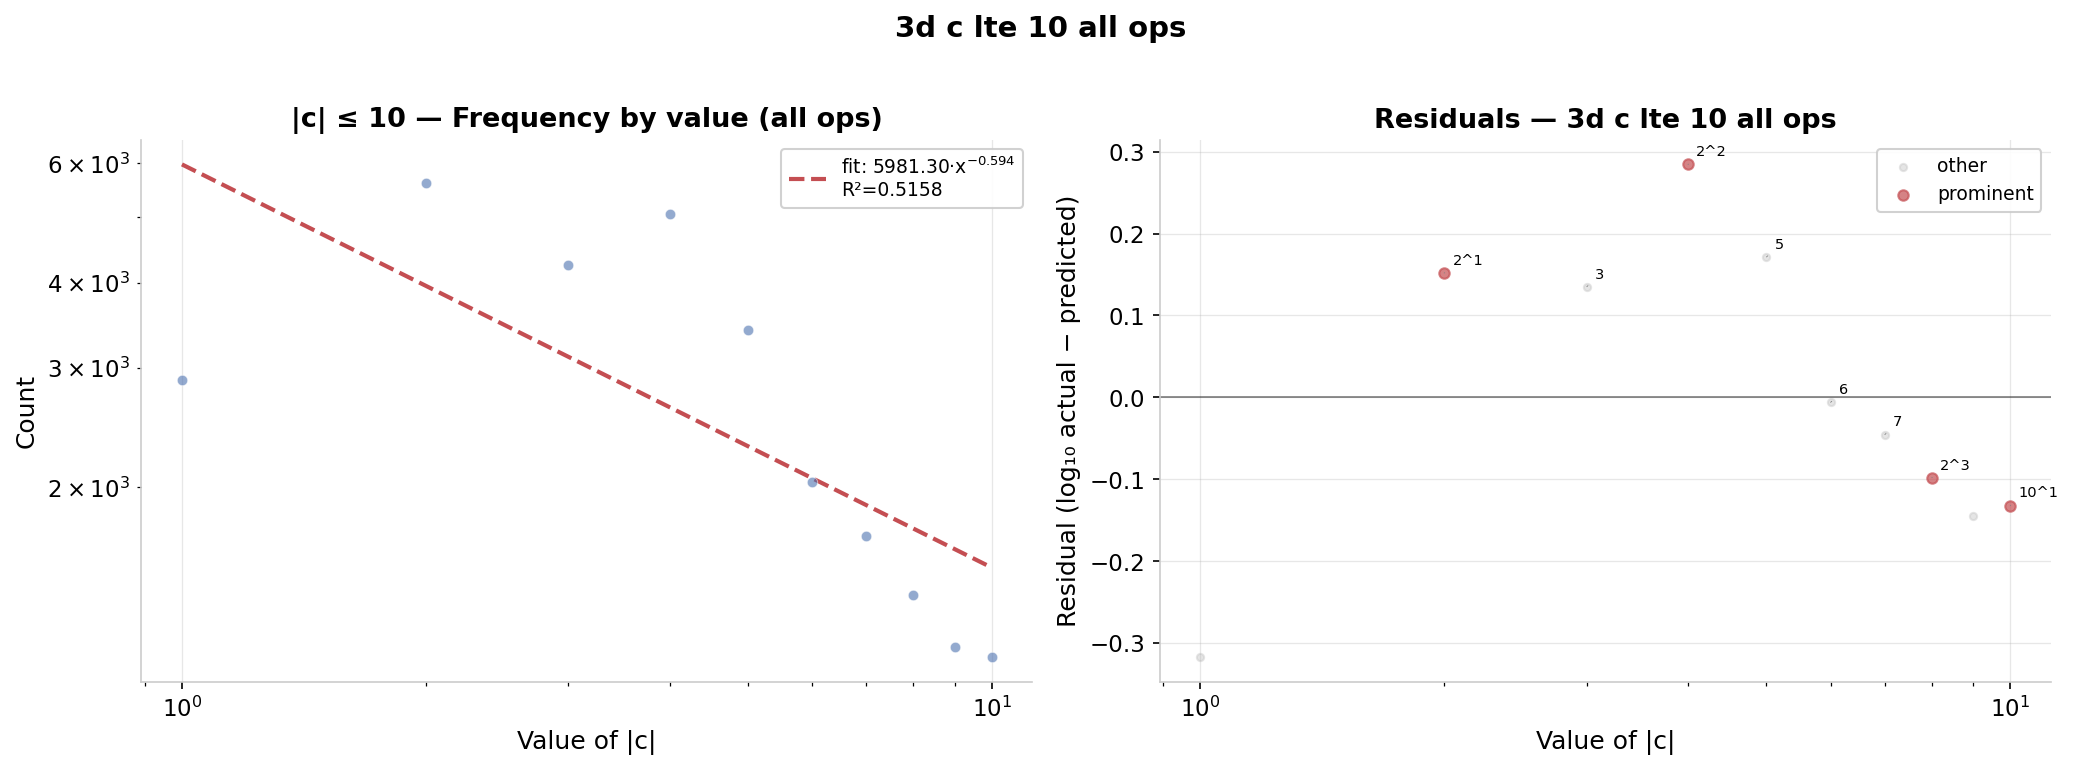

  ✓ 3d c lte 10 all ops: slope=-0.5940, R²=0.5158


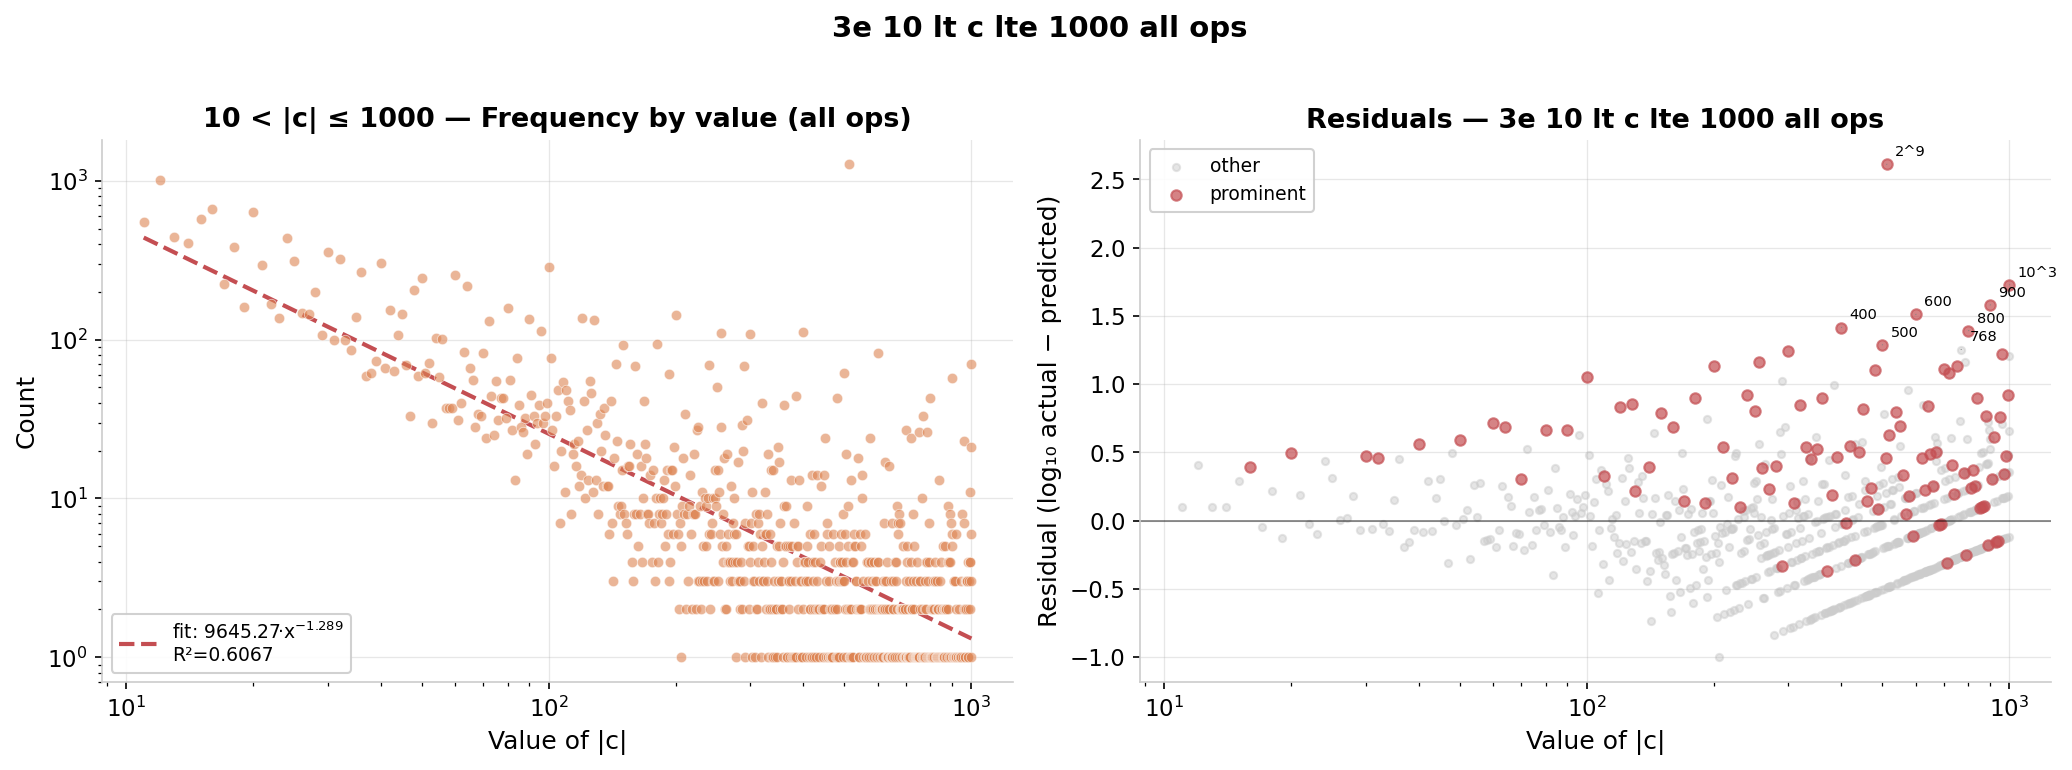

  ✓ 3e 10 lt c lte 1000 all ops: slope=-1.2888, R²=0.6067


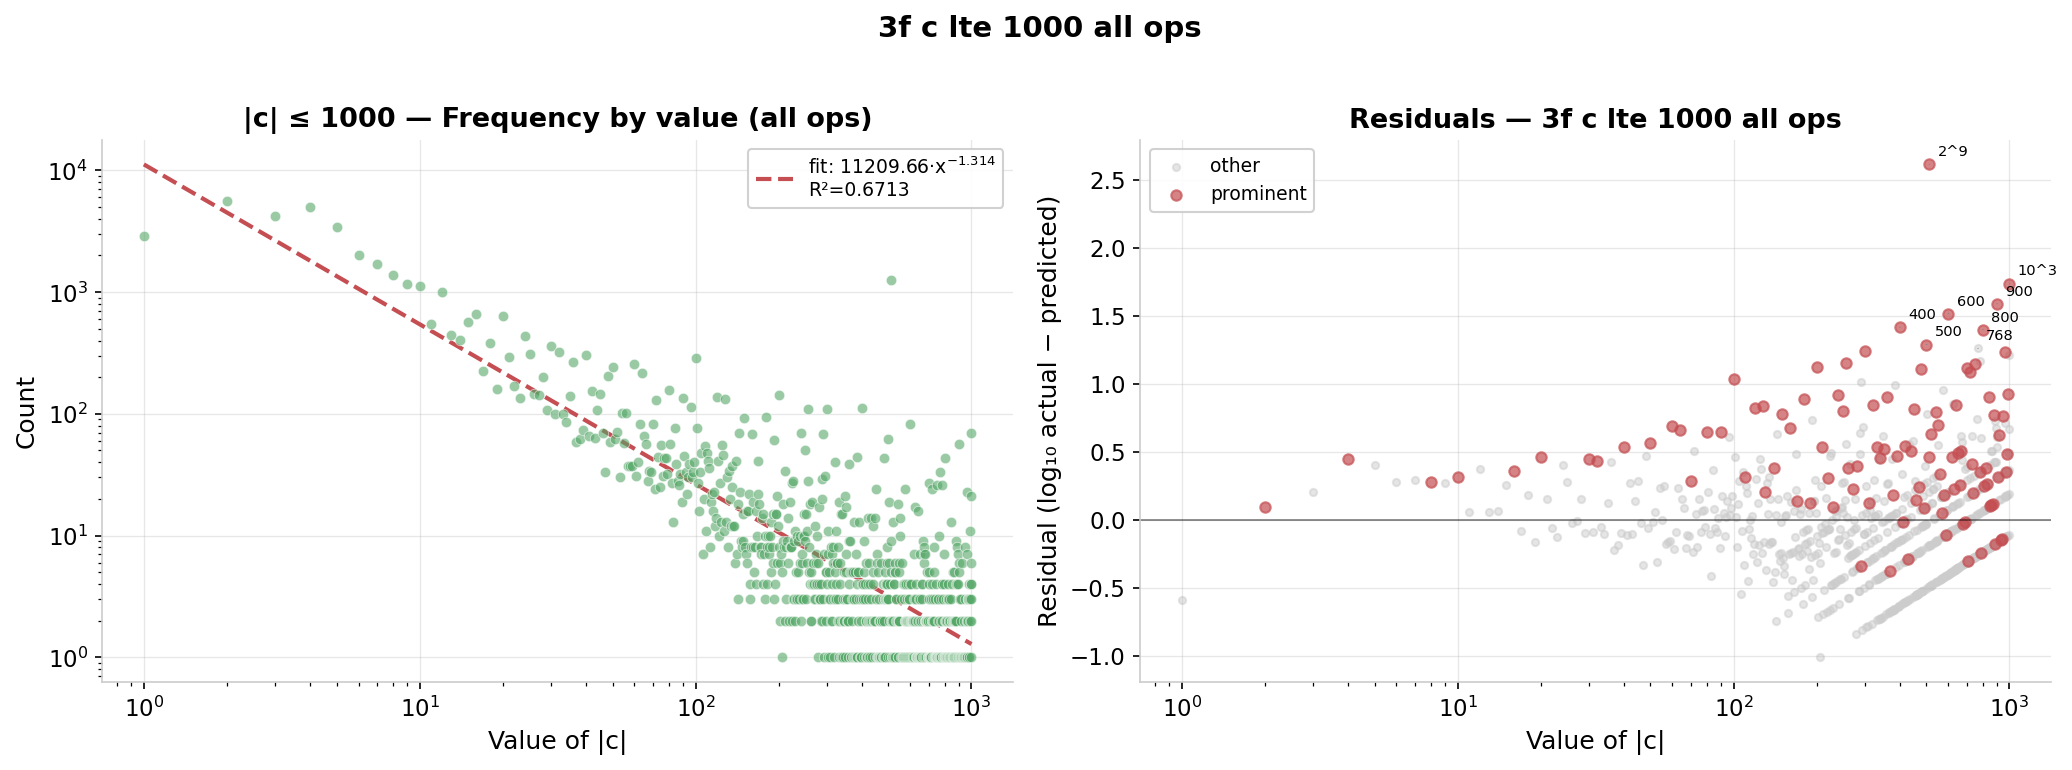

  ✓ 3f c lte 1000 all ops: slope=-1.3138, R²=0.6713


DONE — all fit + residual plots saved as PNGs.


In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# ─────────────────────────────────────────────
# 0.  Global style
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.alpha":         0.30,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "legend.fontsize":    9,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "0.8",
    "figure.dpi":         150,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]

# ─────────────────────────────────────────────
# 1.  Load & prep data
# ─────────────────────────────────────────────
path = "pile_arith_matches_full_copy_backup.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["op_norm"] = df["op"].astype(str).str.strip()
for col in ("a", "b", "c"):
    df[col] = df[col].apply(lambda x: int(x))

df["c_abs"] = df["c"].abs()
df["a_abs"] = df["a"].abs()
df["b_abs"] = df["b"].abs()
df["digits_a"]  = df["a_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_b"]  = df["b_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_c"]  = df["c_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_ab"] = df["digits_a"] + df["digits_b"]
df["log_ab"]    = np.log10((df["a_abs"] + df["b_abs"] + 1).astype(float))
df["log_c"]     = np.log10((df["c_abs"] + 1).astype(float))

OP_MAP = {"+": "+", "\uff0b": "+", "-": "−", "\uff0d": "−",
          "*": "×", "\uff0a": "×", "×": "×",
          "/": "÷", "\uff0f": "÷", "÷": "÷"}
df["op_label"] = df["op_norm"].map(OP_MAP).fillna(df["op_norm"])

# Prominent numbers
powers_of_2  = {2**i for i in range(1, 60)}
powers_of_10 = {10**i for i in range(1, 20)}
multiples_of_10 = {i * 10 for i in range(1, 2000)}
prominent = powers_of_2 | powers_of_10 | multiples_of_10

CUTOFF = 1000


# ─────────────────────────────────────────────
# 2.  Helper: power law fit + residual plot
# ─────────────────────────────────────────────

def power_law_fit_and_plot(x, y, *,
                           plot_id, title, xlabel, ylabel,
                           x_min_fit=None, color=PALETTE[0],
                           check_prominent=False,
                           prominent_field="x"):
    """
    Fit y = a * x^b in log-log space.
    - Plots data + fit line + residuals side by side.
    - If check_prominent, highlights prominent numbers in residuals.
    - x_min_fit: only fit on x >= this value (for tail fits).
    Returns dict with fit results.
    """
    # Remove zeros/negatives for log
    mask_valid = (x > 0) & (y > 0)
    x, y = x[mask_valid], y[mask_valid]

    log_x = np.log10(x.astype(float))
    log_y = np.log10(y.astype(float))

    # Determine fit range
    if x_min_fit is not None:
        fit_mask = x >= x_min_fit
    else:
        fit_mask = np.ones(len(x), dtype=bool)

    if fit_mask.sum() < 3:
        print(f"  ⚠ {plot_id}: too few points for fitting ({fit_mask.sum()}), skipping.")
        return None

    slope, intercept, r, p, se = stats.linregress(log_x[fit_mask], log_y[fit_mask])
    r2 = r ** 2
    a = 10 ** intercept

    # Predicted & residuals (over full range)
    predicted = slope * log_x + intercept
    residuals = log_y - predicted

    # ── Figure: 2 panels ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: data + fit
    ax1.scatter(x, y, color=color, s=25, alpha=0.6, edgecolors="white",
                linewidths=0.4, zorder=3)
    x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    y_line = a * x_line ** slope
    ax1.plot(x_line, y_line, color=PALETTE[3], linewidth=2, linestyle="--",
             label=f"fit: {a:.2f}·x$^{{{slope:.3f}}}$\nR²={r2:.4f}")
    if x_min_fit is not None:
        ax1.axvline(x_min_fit, color="grey", linewidth=1, linestyle=":", alpha=0.6,
                     label=f"fit from x≥{x_min_fit}")
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_title(f"{title}")
    ax1.legend(fontsize=9)

    # Right panel: residuals
    if check_prominent:
        prom_mask = np.array([int(v) in prominent for v in x])
        other_mask = ~prom_mask
        ax2.scatter(x[other_mask], residuals[other_mask], color="#CCCCCC",
                    s=12, alpha=0.5, zorder=1, label="other")
        ax2.scatter(x[prom_mask], residuals[prom_mask], color=PALETTE[3],
                    s=25, alpha=0.7, zorder=2, label="prominent")
        # Annotate top outliers
        top_idx = np.argsort(residuals)[::-1][:8]
        for idx in top_idx:
            v = int(x[idx])
            lbl = ""
            if v in powers_of_2: lbl = f"2^{int(np.log2(v))}"
            elif v in powers_of_10: lbl = f"10^{int(np.log10(v))}"
            elif v % 10 == 0: lbl = f"{v}"
            else: lbl = str(v)
            ax2.annotate(lbl, (x[idx], residuals[idx]), fontsize=7,
                         xytext=(4, 4), textcoords="offset points",
                         arrowprops=dict(arrowstyle="-", color="grey", lw=0.4))
    else:
        ax2.scatter(x, residuals, color=color, s=18, alpha=0.5, edgecolors="white",
                    linewidths=0.3)

    ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax2.set_xscale("log")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Residual (log₁₀ actual − predicted)")
    ax2.set_title(f"Residuals — {plot_id}")
    if check_prominent:
        ax2.legend(fontsize=9)

    fig.suptitle(f"{plot_id}", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fname = f"fit_{plot_id.replace(' ','_').replace('≤','lte').replace('>','gt').replace('|','')}.png"
    fig.savefig(fname)
    plt.show()
    print(f"  ✓ {plot_id}: slope={slope:.4f}, R²={r2:.4f}")

    return {"slope": slope, "intercept": intercept, "r2": r2, "a": a,
            "residuals": residuals, "x": x, "y": y}


def multi_op_fit_and_plot(get_xy_func, *,
                          plot_id, title, xlabel, ylabel,
                          x_min_fit=None, check_prominent=False):
    """
    Same as above but fits one curve per operation + all combined.
    Produces a 2-row figure: top = data+fits, bottom = residuals.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9),
                                     gridspec_kw={"height_ratios": [1, 0.7]})
    results = {}

    for i, name in enumerate(["All", "+", "−", "×", "÷"]):
        if name == "All":
            sub = df
        else:
            sub = df[df["op_label"] == name]

        x, y = get_xy_func(sub)
        mask_valid = (x > 0) & (y > 0)
        x, y = x[mask_valid], y[mask_valid]
        if len(x) < 3:
            continue

        log_x = np.log10(x.astype(float))
        log_y = np.log10(y.astype(float))

        fit_mask = (x >= x_min_fit) if x_min_fit is not None else np.ones(len(x), dtype=bool)
        if fit_mask.sum() < 3:
            continue

        slope, intercept, r, p, se = stats.linregress(log_x[fit_mask], log_y[fit_mask])
        r2 = r ** 2
        a_val = 10 ** intercept
        predicted = slope * log_x + intercept
        residuals = log_y - predicted

        col = PALETTE[0] if name == "All" else PALETTE[i]
        lw = 2.5 if name == "All" else 1.5
        alph = 1.0 if name == "All" else 0.7

        # Top: data + fit
        ax1.scatter(x, y, color=col, s=15 if name != "All" else 30,
                    alpha=0.4 if name != "All" else 0.6,
                    edgecolors="white", linewidths=0.3, zorder=2 if name != "All" else 3)
        x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
        y_line = a_val * x_line ** slope
        lbl = f"{name}: {a_val:.1f}·x$^{{{slope:.2f}}}$ R²={r2:.3f}"
        ax1.plot(x_line, y_line, color=col, linewidth=lw, linestyle="--",
                 alpha=alph, label=lbl)

        # Bottom: residuals
        if check_prominent:
            prom_mask = np.array([int(v) in prominent for v in x])
            ax2.scatter(x[~prom_mask], residuals[~prom_mask], color=col,
                        s=8, alpha=0.25, zorder=1)
            ax2.scatter(x[prom_mask], residuals[prom_mask], color=col,
                        s=20, alpha=0.7, zorder=2, marker="D")
        else:
            ax2.scatter(x, residuals, color=col, s=10, alpha=0.35)

        results[name] = {"slope": slope, "r2": r2, "a": a_val}

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_title(title)
    ax1.legend(fontsize=8, ncol=2)

    ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax2.set_xscale("log")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Residual (log₁₀)")
    ax2.set_title("Residuals")
    if check_prominent:
        from matplotlib.lines import Line2D
        handles = [Line2D([0],[0], marker="o", color="grey", markersize=4, linestyle="None", label="other"),
                   Line2D([0],[0], marker="D", color="grey", markersize=5, linestyle="None", label="prominent")]
        ax2.legend(handles=handles, fontsize=8)

    fig.suptitle(plot_id, fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    fname = f"fit_{plot_id.replace(' ','_').replace('≤','lte').replace('>','gt').replace('|','')}.png"
    fig.savefig(fname)
    plt.show()

    print(f"  ✓ {plot_id}:")
    for name, r in results.items():
        print(f"      {name:>4}: slope={r['slope']:.4f}, R²={r['r2']:.4f}")

    return results


# ═══════════════════════════════════════════════
# SECTION 1 — Problem-size plots (all ops combined)
# ═══════════════════════════════════════════════

print("=" * 70)
print("SECTION 1 — Problem-size (all operations)")
print("=" * 70)

# 1a: digits_ab vs count
counts_1a = df["digits_ab"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_1a.index.values.astype(float),
    counts_1a.values.astype(float),
    plot_id="1a digits(a)+digits(b)",
    title="",
    xlabel="Digits of a + Digits of b",
    ylabel="Count",
    color=PALETTE[0],
)
    # title="Frequency by operand digit-count — power law fit",
# 1b: digits_c vs count
counts_1b = df["digits_c"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_1b.index.values.astype(float),
    counts_1b.values.astype(float),
    plot_id="1b digits(c)",
    title="",
    xlabel="Digits of c",
    ylabel="Count",
    color=PALETTE[1],
)
#Frequency by result digit-count — power law fit",

# 1c: log(a+b) bins — use density (count / linear bin width) to correct for unequal bin coverage
bins_log = np.arange(0, df["log_ab"].max() + 0.5, 0.5)
hv, be = np.histogram(df["log_ab"], bins=bins_log)
bc = 0.5 * (be[:-1] + be[1:])
lin_widths = be[1:] - be[:-1]
density = hv / lin_widths
mask_nz = density > 0
power_law_fit_and_plot(
    bc[mask_nz], density[mask_nz],
    plot_id="1c log(a+b) density",
    title="Density by log₁₀(|a|+|b|) — power law fit",
    xlabel="log₁₀(|a|+|b|) bin centre",
    ylabel="Density (count / linear bin width)",
    color=PALETTE[2],
)

# 1d: log(c) bins — use density
bins_log_c = np.arange(0, df["log_c"].max() + 0.5, 0.5)
hv2, be2 = np.histogram(df["log_c"], bins=bins_log_c)
print(be2)
bc2 = 0.5 * (be2[:-1] + be2[1:])
lin_widths2 = be2[1:] - be2[:-1]
density2 = hv2 / lin_widths2
mask_nz2 = density2 > 0
power_law_fit_and_plot(
    bc2[mask_nz2], density2[mask_nz2],
    plot_id="1d log(c) density",
    title="Density by log₁₀(|c|) — power law fit",
    xlabel="log₁₀(|c|) bin centre",
    ylabel="Density (count / linear bin width)",
    color=PALETTE[3],
)


# ═══════════════════════════════════════════════
# SECTION 2 — By operation
# ═══════════════════════════════════════════════

print("\n" + "=" * 70)
print("SECTION 2 — By operation")
print("=" * 70)

# 2a: digits_c by operation
def get_digits_c_counts(sub):
    c = sub["digits_c"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_digits_c_counts,
    plot_id="2a digits(c) by op",
    title="Frequency by result digit-count — per operation",
    xlabel="Digits of c",
    ylabel="Count",
)

# 2b: log(c) bins by operation — use density
def get_log_c_bin_density(sub):
    bins = np.arange(0, sub["log_c"].max() + 0.5, 0.5)
    if len(bins) < 2:
        return np.array([]), np.array([])
    hv, be = np.histogram(sub["log_c"], bins=bins)
    bc = 0.5 * (be[:-1] + be[1:])
    lin_widths = be[1:] - be[:-1]
    density = hv / lin_widths
    m = density > 0
    return bc[m], density[m]

multi_op_fit_and_plot(
    get_log_c_bin_density,
    plot_id="2b log(c) density by op",
    title="Density by log₁₀(|c|) — per operation",
    xlabel="log₁₀(|c|) bin centre",
    ylabel="Density (count / linear bin width)",
)


# ═══════════════════════════════════════════════
# SECTION 3 — By value of |c|, with prominent number analysis
# ═══════════════════════════════════════════════

print("\n" + "=" * 70)
print("SECTION 3 — By value of |c|")
print("=" * 70)

# 3a: |c| ≤ 10, per operation (only 11 points — fit but note it's marginal)
def get_small_c_counts(sub):
    s = sub[sub["c_abs"] <= 10]
    c = s["c_abs"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_small_c_counts,
    plot_id="3a c lte 10 by op",
    title="|c| ≤ 10 — Frequency by value (per operation)",
    xlabel="Value of |c|",
    ylabel="Count",
    check_prominent=True,
)

# 3b: 10 < |c| ≤ 1000, per operation
def get_mid_c_counts(sub):
    s = sub[(sub["c_abs"] > 10) & (sub["c_abs"] <= CUTOFF)]
    c = s["c_abs"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_mid_c_counts,
    plot_id="3b 10 lt c lte 1000 by op",
    title="10 < |c| ≤ 1000 — Frequency by value (per operation)",
    xlabel="Value of |c|",
    ylabel="Count",
    check_prominent=True,
)

# 3c: |c| ≤ 1000, per operation
def get_all_cut_counts(sub):
    s = sub[sub["c_abs"] <= CUTOFF]
    c = s["c_abs"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_all_cut_counts,
    plot_id="3c c lte 1000 by op",
    title="|c| ≤ 1000 — Frequency by value (per operation)",
    xlabel="Value of |c|",
    ylabel="Count",
    check_prominent=True,
)

# 3d: |c| ≤ 10, all ops combined
counts_3d = df[df["c_abs"] <= 10]["c_abs"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_3d.index.values.astype(float),
    counts_3d.values.astype(float),
    plot_id="3d c lte 10 all ops",
    title="|c| ≤ 10 — Frequency by value (all ops)",
    xlabel="Value of |c|",
    ylabel="Count",
    check_prominent=True,
    color=PALETTE[0],
)

# 3e: 10 < |c| ≤ 1000, all ops combined
df_mid = df[(df["c_abs"] > 10) & (df["c_abs"] <= CUTOFF)]
counts_3e = df_mid["c_abs"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_3e.index.values.astype(float),
    counts_3e.values.astype(float),
    plot_id="3e 10 lt c lte 1000 all ops",
    title="10 < |c| ≤ 1000 — Frequency by value (all ops)",
    xlabel="Value of |c|",
    ylabel="Count",
    check_prominent=True,
    color=PALETTE[1],
)

# 3f: |c| ≤ 1000, all ops combined
df_all_cut = df[df["c_abs"] <= CUTOFF]
counts_3f = df_all_cut["c_abs"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_3f.index.values.astype(float),
    counts_3f.values.astype(float),
    plot_id="3f c lte 1000 all ops",
    title="|c| ≤ 1000 — Frequency by value (all ops)",
    xlabel="Value of |c|",
    ylabel="Count",
    check_prominent=True,
    color=PALETTE[2],
)


# ═══════════════════════════════════════════════
# Summary table
# ═══════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("DONE — all fit + residual plots saved as PNGs.")
print("=" * 70)

-   set of special numbers:
    -     highlight numbers that are special on the left (colorcode)
    -     comment out all residual graphs
    -     get rid of overall line on the segmented graph
    -     get rid of twice-log graphs 

- graph out if the operands are exactly the same

- slides from initial questions -> more questions generated after graphing 

    
   

- *powerpoint*: discussion section
- group each count/histogram graph; and with the power law fit 
- interesting points for each graph/interpretation
- for more questions to test out in the training part

In [24]:
# =========================
# CHANGES IMPLEMENTED
#  - Remove graphs 1c + 1d
#  - No residual plots anywhere EXCEPT 3e + 3f
#  - In segmented (multi-op) plots 2a–3c: remove the overall “All” curve
#  - Highlight prominent numbers on the FIT graph for 3a–3f
# =========================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ─────────────────────────────────────────────
# 0.  Global style (unchanged)
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.alpha":         0.30,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "legend.fontsize":    9,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "0.8",
    "figure.dpi":         150,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]

# ─────────────────────────────────────────────
# 1.  Load & prep data (unchanged)
# ─────────────────────────────────────────────
path = "pile_arith_matches_full_copy_backup.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["op_norm"] = df["op"].astype(str).str.strip()
for col in ("a", "b", "c"):
    df[col] = df[col].apply(lambda x: int(x))

df["c_abs"] = df["c"].abs()
df["a_abs"] = df["a"].abs()
df["b_abs"] = df["b"].abs()
df["digits_a"]  = df["a_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_b"]  = df["b_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_c"]  = df["c_abs"].apply(lambda v: len(str(v)) if v != 0 else 1)
df["digits_ab"] = df["digits_a"] + df["digits_b"]
df["log_ab"]    = np.log10((df["a_abs"] + df["b_abs"] + 1).astype(float))
df["log_c"]     = np.log10((df["c_abs"] + 1).astype(float))

OP_MAP = {"+": "+", "\uff0b": "+", "-": "−", "\uff0d": "−",
          "*": "×", "\uff0a": "×", "×": "×",
          "/": "÷", "\uff0f": "÷", "÷": "÷"}
df["op_label"] = df["op_norm"].map(OP_MAP).fillna(df["op_norm"])

# Prominent numbers
powers_of_2  = {2**i for i in range(1, 60)}
powers_of_10 = {10**i for i in range(1, 20)}
multiples_of_10 = {i * 10 for i in range(1, 2000)}
prominent = powers_of_2 | powers_of_10 | multiples_of_10

CUTOFF = 1000


# ─────────────────────────────────────────────
# 2.  Helpers: power law fit (+ optional residuals) + prominent highlighting
# ─────────────────────────────────────────────

def _annotate_prominent_value(v: int) -> str:
    if v in powers_of_2:
        return f"2^{int(np.log2(v))}"
    if v in powers_of_10:
        return f"10^{int(np.log10(v))}"
    if v % 10 == 0:
        return str(v)
    return str(v)


def power_law_fit_and_plot(x, y, *,
                           plot_id, title, xlabel, ylabel,
                           x_min_fit=None, color=PALETTE[0],
                           highlight_prominent_on_fit=False,
                           check_prominent=False,  # kept for residual mode compatibility
                           plot_residuals=False,
                           n_annotate=8):
    """
    Fit y = a * x^b in log-log space.
    - Default: ONLY plots data + fit (no residuals).
    - If plot_residuals=True, adds residual panel.
    - If highlight_prominent_on_fit=True, marks prominent x values on the fit plot.
    - If plot_residuals=True and check_prominent=True, highlights prominent values in residuals.
    """
    # Remove zeros/negatives for log
    mask_valid = (x > 0) & (y > 0)
    x, y = x[mask_valid], y[mask_valid]

    if len(x) < 3:
        print(f"  ⚠ {plot_id}: too few points, skipping.")
        return None

    log_x = np.log10(x.astype(float))
    log_y = np.log10(y.astype(float))

    # Determine fit range
    fit_mask = (x >= x_min_fit) if x_min_fit is not None else np.ones(len(x), dtype=bool)
    if fit_mask.sum() < 3:
        print(f"  ⚠ {plot_id}: too few points for fitting ({fit_mask.sum()}), skipping.")
        return None

    slope, intercept, r, p, se = stats.linregress(log_x[fit_mask], log_y[fit_mask])
    r2 = r ** 2
    a = 10 ** intercept

    predicted = slope * log_x + intercept
    residuals = log_y - predicted

    # ── Figure layout ──
    if plot_residuals:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(7.2, 5))

    # Left / only: data + fit
    ax1.scatter(x, y, color=color, s=25, alpha=0.6, edgecolors="white",
                linewidths=0.4, zorder=3)

    # Highlight prominent on fit graph (3a–3f)
    if highlight_prominent_on_fit:
        prom_mask = np.array([int(v) in prominent for v in x])
        if prom_mask.any():
            ax1.scatter(x[prom_mask], y[prom_mask],
                        facecolors="none", edgecolors=PALETTE[3],
                        s=70, linewidths=1.2, zorder=5, marker="D",
                        label="prominent")
            # annotate a few most frequent (highest y among prominent)
            prom_idx = np.where(prom_mask)[0]
            top_prom = prom_idx[np.argsort(y[prom_idx])[::-1][:n_annotate]]
            for idx in top_prom:
                v = int(x[idx])
                ax1.annotate(_annotate_prominent_value(v),
                             (x[idx], y[idx]),
                             fontsize=7, xytext=(4, 4), textcoords="offset points",
                             arrowprops=dict(arrowstyle="-", color="grey", lw=0.4))

    x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    y_line = a * x_line ** slope
    ax1.plot(x_line, y_line, color=PALETTE[3], linewidth=2, linestyle="--",
             label=f"fit: {a:.2f}·x$^{{{slope:.3f}}}$\nR²={r2:.4f}")

    if x_min_fit is not None:
        ax1.axvline(x_min_fit, color="grey", linewidth=1, linestyle=":", alpha=0.6,
                    label=f"fit from x≥{x_min_fit}")

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_title(f"{title}")
    ax1.legend(fontsize=9)

    # Residuals panel (ONLY if plot_residuals=True)
    if plot_residuals:
        if check_prominent:
            prom_mask = np.array([int(v) in prominent for v in x])
            other_mask = ~prom_mask
            ax2.scatter(x[other_mask], residuals[other_mask], color="#CCCCCC",
                        s=12, alpha=0.5, zorder=1, label="other")
            ax2.scatter(x[prom_mask], residuals[prom_mask], color=PALETTE[3],
                        s=25, alpha=0.7, zorder=2, label="prominent")
        else:
            ax2.scatter(x, residuals, color=color, s=18, alpha=0.5,
                        edgecolors="white", linewidths=0.3)

        ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)
        ax2.set_xscale("log")
        ax2.set_xlabel(xlabel)
        ax2.set_ylabel("Residual (log₁₀ actual − predicted)")
        ax2.set_title(f"Residuals — {plot_id}")
        if check_prominent:
            ax2.legend(fontsize=9)

    fig.suptitle(f"{plot_id}", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fname = f"fit_{plot_id.replace(' ','_').replace('≤','lte').replace('>','gt').replace('|','')}.png"
    fig.savefig(fname)
    plt.show()
    print(f"  ✓ {plot_id}: slope={slope:.4f}, R²={r2:.4f}")

    return {"slope": slope, "intercept": intercept, "r2": r2, "a": a,
            "residuals": residuals, "x": x, "y": y}


def multi_op_fit_and_plot(get_xy_func, *,
                          plot_id, title, xlabel, ylabel,
                          x_min_fit=None,
                          plot_residuals=False,              # default OFF now
                          highlight_prominent_on_fit=False,  # for 3a–3c
                          check_prominent=False,             # only used if residuals ON
                          include_all=False):                # default: NO overall curve
    """
    Fits one curve per operation.
    - Default: NO "All" curve, and NO residual subplot.
    - If plot_residuals=True, adds residual subplot.
    - If highlight_prominent_on_fit=True, marks prominent x values on fit graph.
    """
    ops = ["+", "−", "×", "÷"]
    if include_all:
        ops = ["All"] + ops

    if plot_residuals:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9),
                                       gridspec_kw={"height_ratios": [1, 0.7]})
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))

    results = {}

    for i, name in enumerate(ops):
        sub = df if name == "All" else df[df["op_label"] == name]

        x, y = get_xy_func(sub)
        mask_valid = (x > 0) & (y > 0)
        x, y = x[mask_valid], y[mask_valid]
        if len(x) < 3:
            continue

        log_x = np.log10(x.astype(float))
        log_y = np.log10(y.astype(float))

        fit_mask = (x >= x_min_fit) if x_min_fit is not None else np.ones(len(x), dtype=bool)
        if fit_mask.sum() < 3:
            continue

        slope, intercept, r, p, se = stats.linregress(log_x[fit_mask], log_y[fit_mask])
        r2 = r ** 2
        a_val = 10 ** intercept
        predicted = slope * log_x + intercept
        residuals = log_y - predicted

        # Colors: stable mapping per op
        col_map = {"+": PALETTE[1], "−": PALETTE[2], "×": PALETTE[3], "÷": PALETTE[4], "All": PALETTE[0]}
        col = col_map.get(name, PALETTE[0])

        # Data + fit
        ax1.scatter(x, y, color=col, s=18, alpha=0.45,
                    edgecolors="white", linewidths=0.3, zorder=2)

        # Highlight prominent on fit plot
        if highlight_prominent_on_fit:
            prom_mask = np.array([int(v) in prominent for v in x])
            if prom_mask.any():
                ax1.scatter(x[prom_mask], y[prom_mask],
                            facecolors="none", edgecolors=col,
                            s=70, linewidths=1.0, zorder=4, marker="D")

        x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
        y_line = a_val * x_line ** slope
        lbl = f"{name}: {a_val:.1f}·x$^{{{slope:.2f}}}$ R²={r2:.3f}"
        ax1.plot(x_line, y_line, color=col, linewidth=1.8, linestyle="--",
                 alpha=0.9, label=lbl)

        # Residuals (only if enabled)
        if plot_residuals:
            if check_prominent:
                prom_mask = np.array([int(v) in prominent for v in x])
                ax2.scatter(x[~prom_mask], residuals[~prom_mask], color=col,
                            s=8, alpha=0.25, zorder=1)
                ax2.scatter(x[prom_mask], residuals[prom_mask], color=col,
                            s=20, alpha=0.7, zorder=2, marker="D")
            else:
                ax2.scatter(x, residuals, color=col, s=10, alpha=0.35)

        results[name] = {"slope": slope, "r2": r2, "a": a_val}

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_title(title)
    ax1.legend(fontsize=8, ncol=2)

    if plot_residuals:
        ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)
        ax2.set_xscale("log")
        ax2.set_xlabel(xlabel)
        ax2.set_ylabel("Residual (log₁₀)")
        ax2.set_title("Residuals")
        if check_prominent:
            from matplotlib.lines import Line2D
            handles = [
                Line2D([0],[0], marker="o", color="grey", markersize=4, linestyle="None", label="other"),
                Line2D([0],[0], marker="D", color="grey", markersize=5, linestyle="None", label="prominent")
            ]
            ax2.legend(handles=handles, fontsize=8)

    fig.suptitle(plot_id, fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    fname = f"fit_{plot_id.replace(' ','_').replace('≤','lte').replace('>','gt').replace('|','')}.png"
    fig.savefig(fname)
    plt.show()

    print(f"  ✓ {plot_id}:")
    for name, r in results.items():
        print(f"      {name:>4}: slope={r['slope']:.4f}, R²={r['r2']:.4f}")

    return results


# ═══════════════════════════════════════════════
# SECTION 1 — Problem-size plots (all ops combined)
# ═══════════════════════════════════════════════

print("=" * 70)
print("SECTION 1 — Problem-size (all operations)")
print("=" * 70)

# 1a: digits_ab vs count (NO residuals)
counts_1a = df["digits_ab"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_1a.index.values.astype(float),
    counts_1a.values.astype(float),
    plot_id="1a digits(a)+digits(b)",
    title="",
    xlabel="Digits of a + Digits of b",
    ylabel="Count",
    color=PALETTE[0],
    plot_residuals=False,
)
#Frequency by operand digit-count — power law fit",

# 1b: digits_c vs count (NO residuals)
counts_1b = df["digits_c"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_1b.index.values.astype(float),
    counts_1b.values.astype(float),
    plot_id="1b digits(c)",
    title="",
    xlabel="Digits of c",
    ylabel="Count",
    color=PALETTE[1],
    plot_residuals=False,
)
#Frequency by result digit-count — power law fit",
# ---- REMOVED: 1c + 1d (twice-log density bin plots)
# (deleted per request)


# ═══════════════════════════════════════════════
# SECTION 2 — By operation
# ═══════════════════════════════════════════════

print("\n" + "=" * 70)
print("SECTION 2 — By operation")
print("=" * 70)

# 2a: digits_c by operation (NO overall "All", NO residuals)
def get_digits_c_counts(sub):
    c = sub["digits_c"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_digits_c_counts,
    plot_id="2a digits(c) by op",
    title="",
    xlabel="Digits of c",
    ylabel="Count",
    plot_residuals=False,
    include_all=False,   # << remove overall curve
)
#Frequency by result digit-count — per operation",

# 2b: log(c) bins by operation — use density (NO overall "All", NO residuals)
def get_log_c_bin_density(sub):
    bins = np.arange(0, sub["log_c"].max() + 0.5, 0.5)
    if len(bins) < 2:
        return np.array([]), np.array([])
    hv, be = np.histogram(sub["log_c"], bins=bins)
    bc = 0.5 * (be[:-1] + be[1:])
    lin_widths = be[1:] - be[:-1]
    density = hv / lin_widths
    m = density > 0
    return bc[m], density[m]

multi_op_fit_and_plot(
    get_log_c_bin_density,
    plot_id="2b log(c) density by op",
    title="Density by log₁₀(|c|) — per operation",
    xlabel="log₁₀(|c|) bin centre",
    ylabel="Density (count / linear bin width)",
    plot_residuals=False,
    include_all=False,   # << remove overall curve
)


# ═══════════════════════════════════════════════
# SECTION 3 — By value of |c|, with prominent number analysis
# ═══════════════════════════════════════════════

print("\n" + "=" * 70)
print("SECTION 3 — By value of |c|")
print("=" * 70)

# 3a: |c| ≤ 10, per operation (highlight prominent ON FIT, NO residuals)
def get_small_c_counts(sub):
    s = sub[sub["c_abs"] <= 10]
    c = s["c_abs"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_small_c_counts,
    plot_id="3a c lte 10 by op",
    title="|c| ≤ 10 — Frequency by value (per operation)",
    xlabel="Value of |c|",
    ylabel="Count",
    plot_residuals=False,
    include_all=False,
    highlight_prominent_on_fit=True,
)

# 3b: 10 < |c| ≤ 1000, per operation (highlight prominent ON FIT, NO residuals)
def get_mid_c_counts(sub):
    s = sub[(sub["c_abs"] > 10) & (sub["c_abs"] <= CUTOFF)]
    c = s["c_abs"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_mid_c_counts,
    plot_id="3b 10 lt c lte 1000 by op",
    title="10 < |c| ≤ 1000 — Frequency by value (per operation)",
    xlabel="Value of |c|",
    ylabel="Count",
    plot_residuals=False,
    include_all=False,
    highlight_prominent_on_fit=True,
)

# 3c: |c| ≤ 1000, per operation (highlight prominent ON FIT, NO residuals)
def get_all_cut_counts(sub):
    s = sub[sub["c_abs"] <= CUTOFF]
    c = s["c_abs"].value_counts().sort_index()
    return c.index.values.astype(float), c.values.astype(float)

multi_op_fit_and_plot(
    get_all_cut_counts,
    plot_id="3c c lte 1000 by op",
    title="|c| ≤ 1000 — Frequency by value (per operation)",
    xlabel="Value of |c|",
    ylabel="Count",
    plot_residuals=False,
    include_all=False,
    highlight_prominent_on_fit=True,
)

# 3d: |c| ≤ 10, all ops combined (highlight prominent ON FIT, NO residuals)
counts_3d = df[df["c_abs"] <= 10]["c_abs"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_3d.index.values.astype(float),
    counts_3d.values.astype(float),
    plot_id="3d c lte 10 all ops",
    title="|c| ≤ 10 — Frequency by value (all ops)",
    xlabel="Value of |c|",
    ylabel="Count",
    highlight_prominent_on_fit=True,
    color=PALETTE[0],
    plot_residuals=False,
)

# 3e: 10 < |c| ≤ 1000, all ops combined (highlight prominent ON FIT, KEEP residuals)
df_mid = df[(df["c_abs"] > 10) & (df["c_abs"] <= CUTOFF)]
counts_3e = df_mid["c_abs"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_3e.index.values.astype(float),
    counts_3e.values.astype(float),
    plot_id="3e 10 lt c lte 1000 all ops",
    title="10 < |c| ≤ 1000 — Frequency by value (all ops)",
    xlabel="Value of |c|",
    ylabel="Count",
    highlight_prominent_on_fit=True,
    check_prominent=True,     # residual panel can optionally highlight too
    color=PALETTE[1],
    plot_residuals=True,      # << keep residuals for 3e
)

# 3f: |c| ≤ 1000, all ops combined (highlight prominent ON FIT, KEEP residuals)
df_all_cut = df[df["c_abs"] <= CUTOFF]
counts_3f = df_all_cut["c_abs"].value_counts().sort_index()
power_law_fit_and_plot(
    counts_3f.index.values.astype(float),
    counts_3f.values.astype(float),
    plot_id="3f c lte 1000 all ops",
    title="|c| ≤ 1000 — Frequency by value (all ops)",
    xlabel="Value of |c|",
    ylabel="Count",
    highlight_prominent_on_fit=True,
    check_prominent=True,
    color=PALETTE[2],
    plot_residuals=True,      # << keep residuals for 3f
)


print("\n\n" + "=" * 70)
print("DONE — fit plots saved as PNGs (residuals only for 3e, 3f).")
print("=" * 70)

SyntaxError: invalid syntax (1660853213.py, line 383)

  op  digit_len      n   obs          exp  p_eq_null  ratio_obs_over_exp  \
0  +          1  15977  4861  2333.050510   0.146026            2.083538   
1  +          2   2773   328    58.882077   0.021234            5.570456   
2  +          3    860    67     3.304651   0.003843           20.274455   
3  +          4    207    18     1.376812   0.006651           13.073684   
4  ×          1   3723  1016   463.708568   0.124552            2.191031   

      z_null  
0  56.634867  
1  35.449625  
2  35.105966  
3  14.214324  
4  27.411365  


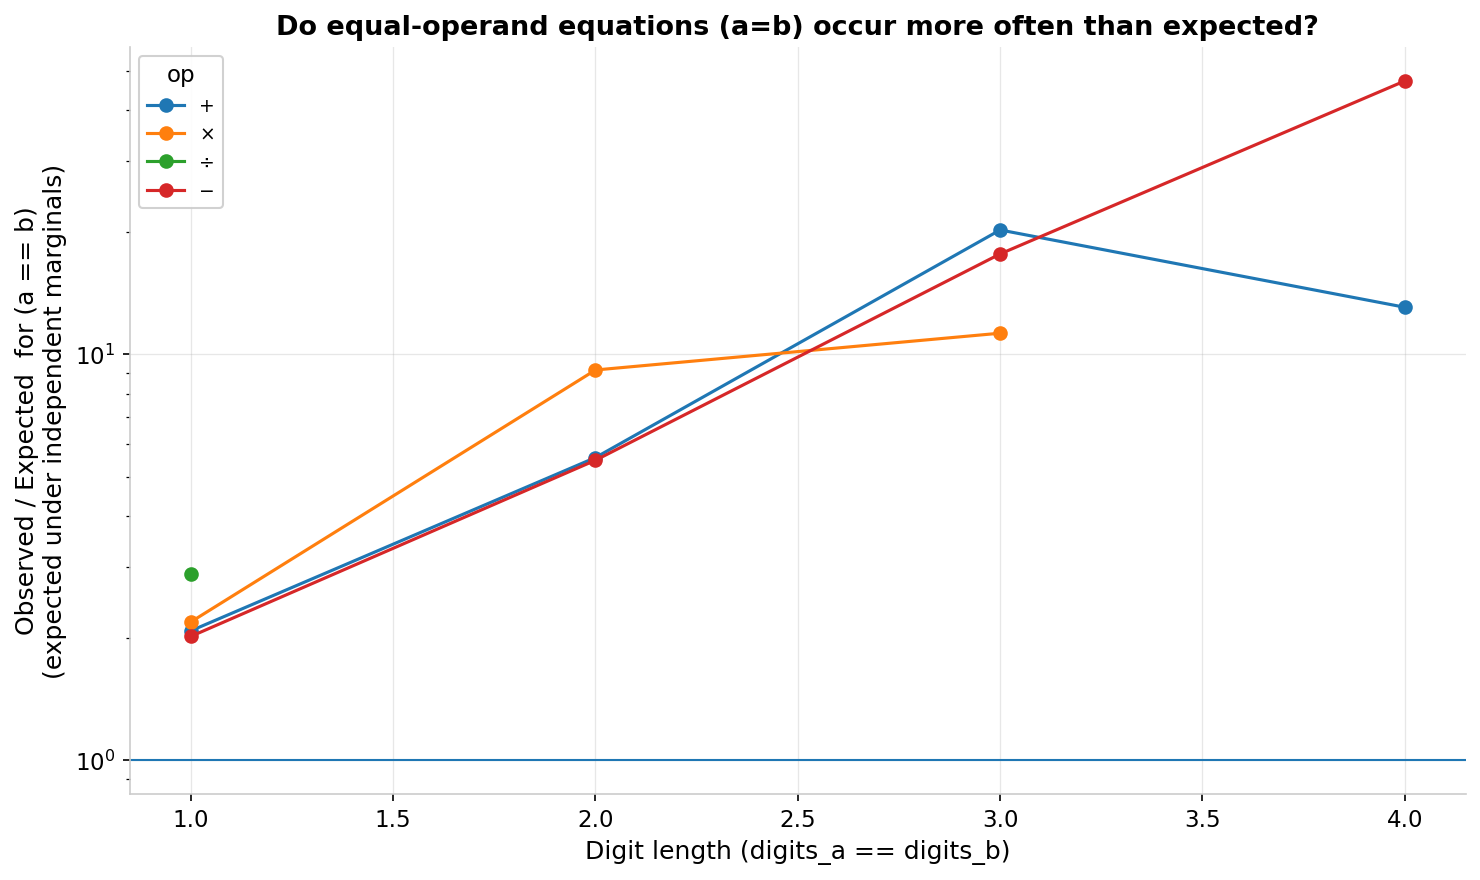

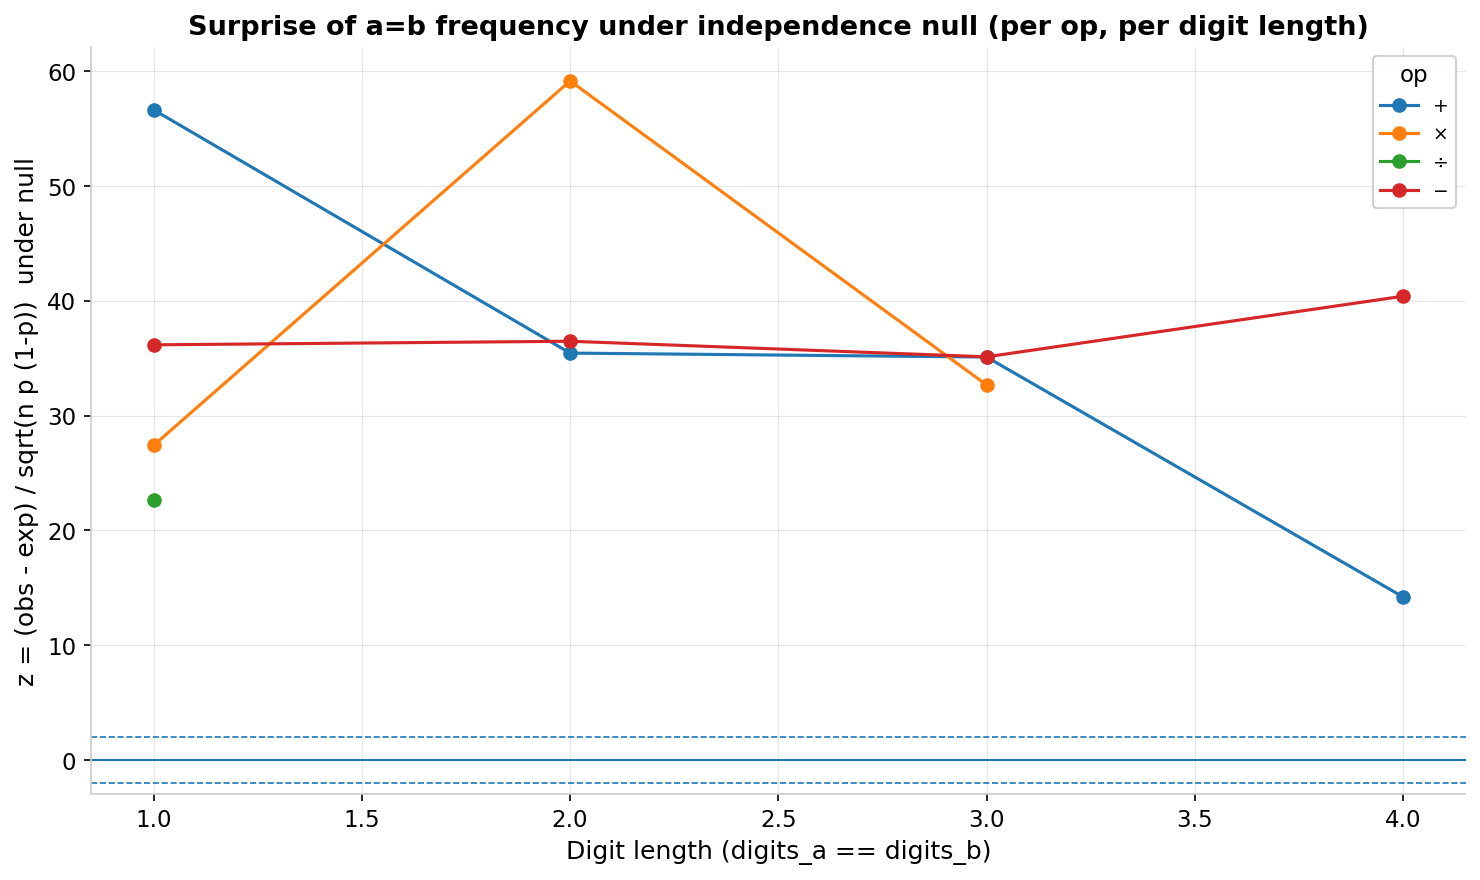


Aggregate by op:
   op  N_total  obs_total    exp_total  ratio_total
0  +  19817.0     5274.0  2396.614050     2.200605
1  ×   5322.0     1589.0   524.018678     3.032335
2  ÷   1054.0      370.0   128.808349     2.872485
3  −  13669.0     2707.0  1178.741373     2.296517


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def equal_operands_stats(df, min_n=200, use_abs=False):
    """
    Compare observed rate of (a==b) to expected under independence of marginals,
    within (op_label, digit_length) groups where digits_a==digits_b.

    use_abs: if True, tests |a|==|b| instead of a==b.
    """
    d = df.copy()

    if use_abs:
        a = d["a_abs"].to_numpy()
        b = d["b_abs"].to_numpy()
        d["_a_cmp"] = a
        d["_b_cmp"] = b
    else:
        d["_a_cmp"] = d["a"].to_numpy()
        d["_b_cmp"] = d["b"].to_numpy()

    # Only groups where equality is possible at same digit length
    d = d[d["digits_a"] == d["digits_b"]].copy()
    d["digit_len"] = d["digits_a"].astype(int)

    rows = []
    for (op, dig), sub in d.groupby(["op_label", "digit_len"], sort=True):
        n = len(sub)
        if n < min_n:
            continue

        obs = int((sub["_a_cmp"] == sub["_b_cmp"]).sum())

        # Marginal counts
        ca = sub["_a_cmp"].value_counts()
        cb = sub["_b_cmp"].value_counts()

        # dot = Σ_v count_a(v)*count_b(v)
        dot = ca.mul(cb, fill_value=0).sum()

        # Expected under null
        p_eq = dot / (n * n)
        exp = dot / n  # n * p_eq

        # Binomial approx under null for a quick “how surprising?”
        var = n * p_eq * (1 - p_eq)
        se = np.sqrt(var) if var > 0 else np.nan
        z = (obs - exp) / se if (se is not None and np.isfinite(se) and se > 0) else np.nan

        ratio = (obs / exp) if exp > 0 else np.nan

        rows.append({
            "op": op, "digit_len": dig,
            "n": n, "obs": obs, "exp": exp,
            "p_eq_null": p_eq,
            "ratio_obs_over_exp": ratio,
            "z_null": z,
        })

    out = pd.DataFrame(rows).sort_values(["op", "digit_len"])
    return out


# ---- run it ----
stats_eq = equal_operands_stats(df, min_n=200, use_abs=False)
print(stats_eq.head())

# ---- Plot 1: Observed/Expected ratio by digit length ----
plt.figure(figsize=(10,6))
for op, sub in stats_eq.groupby("op"):
    plt.plot(sub["digit_len"], sub["ratio_obs_over_exp"], marker="o", linewidth=1.5, label=str(op))

plt.axhline(1.0, linewidth=1.0)
plt.yscale("log")  # ratios can get big; log makes it readable
plt.xlabel("Digit length (digits_a == digits_b)")
plt.ylabel("Observed / Expected  for (a == b)\n(expected under independent marginals)")
plt.title("Do equal-operand equations (a=b) occur more often than expected?")
plt.legend(title="op")
plt.tight_layout()
plt.show()

# ---- Plot 2 (optional): z-score by digit length ----
plt.figure(figsize=(10,6))
for op, sub in stats_eq.groupby("op"):
    plt.plot(sub["digit_len"], sub["z_null"], marker="o", linewidth=1.5, label=str(op))

plt.axhline(0.0, linewidth=1.0)
plt.axhline(2.0, linewidth=0.8, linestyle="--")
plt.axhline(-2.0, linewidth=0.8, linestyle="--")
plt.xlabel("Digit length (digits_a == digits_b)")
plt.ylabel("z = (obs - exp) / sqrt(n p (1-p))  under null")
plt.title("Surprise of a=b frequency under independence null (per op, per digit length)")
plt.legend(title="op")
plt.tight_layout()
plt.show()

# ---- Useful aggregate summary per operation ----
agg = (stats_eq
       .groupby("op")
       .apply(lambda g: pd.Series({
           "N_total": int(g["n"].sum()),
           "obs_total": int(g["obs"].sum()),
           "exp_total": float(g["exp"].sum()),
           "ratio_total": float(g["obs"].sum() / g["exp"].sum()) if g["exp"].sum() > 0 else np.nan
       }))
       .reset_index())
print("\nAggregate by op:\n", agg)

In [ ]:
import numpy as np

rng = np.random.default_rng(0)

d = df[df["digits_a"] == df["digits_b"]].copy().reset_index(drop=True)

obs = (d["a"] == d["b"]).mean()

b_shuf = d["b"].to_numpy().copy()
for L, idx in d.groupby("digits_a").groups.items():
    idx = np.array(list(idx))          # now these are 0..len(d)-1 positions
    tmp = b_shuf[idx].copy()
    rng.shuffle(tmp)
    b_shuf[idx] = tmp

exp = (d["a"].to_numpy() == b_shuf).mean()

print(f"Observed P(a=b) (matched digit length): {obs:.6f}")
print(f"Expected P(a=b) after within-length shuffle: {exp:.6f}")
print(f"Ratio obs/exp: {obs/exp:.2f}")

Observed P(a=b) (matched digit length): 0.249600
Expected P(a=b) after within-length shuffle: 0.101139
Ratio obs/exp: 2.47


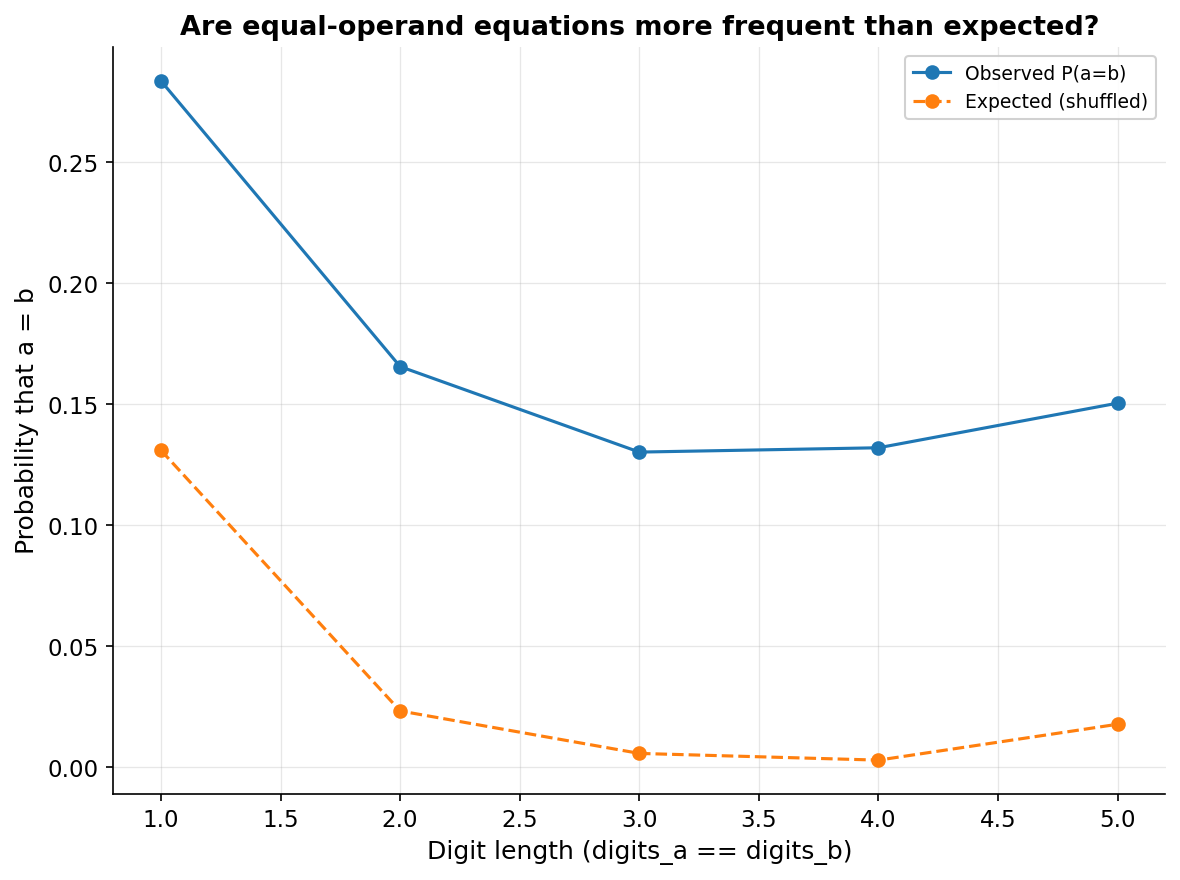

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Only cases where digits match
d = df[df["digits_a"] == df["digits_b"]].copy().reset_index(drop=True)

results = []

for L, sub in d.groupby("digits_a"):
    if len(sub) < 200:   # skip tiny buckets
        continue

    # observed
    obs = (sub["a"] == sub["b"]).mean()

    # expected via shuffle within this bucket
    b_vals = sub["b"].to_numpy().copy()
    rng.shuffle(b_vals)
    exp = (sub["a"].to_numpy() == b_vals).mean()

    results.append((L, obs, exp))

# unpack
digit_len = [r[0] for r in results]
obs_vals  = [r[1] for r in results]
exp_vals  = [r[2] for r in results]

# plot
plt.figure(figsize=(8,6))
plt.plot(digit_len, obs_vals, marker="o", label="Observed P(a=b)")
plt.plot(digit_len, exp_vals, marker="o", linestyle="--", label="Expected (shuffled)")
plt.xlabel("Digit length (digits_a == digits_b)")
plt.ylabel("Probability that a = b")
plt.title("Are equal-operand equations more frequent than expected?")
plt.legend()
plt.tight_layout()
plt.show()

## Distribution of all numbers in the Pile (not tied to arithmetic)

These cells plot the distribution of **every standalone integer** found in the Pile corpus, independent of whether it appears in an arithmetic expression.

The aggregates are produced by `scan_numbers.py` (submitted via `scan_numbers.sbatch`), which streams `EleutherAI/the_pile_deduplicated` and writes a JSON summary (`pile_number_distribution.json`) with a digit-count histogram, a `log10(|x|+1)` histogram, and exact counts for small magnitudes. The plots below mirror the addition-result graphs above (digit-count bars on linear / log-y, and a `log10` histogram).

In [ ]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output written by scan_numbers.py (see scan_numbers.sbatch).
NUM_DIST_PATH = os.environ.get(
    "NUM_DIST_PATH",
    "/storage/scratch1/9/kzhang430/pile_number_distribution.json",
)
if not os.path.exists(NUM_DIST_PATH):
    # fall back to a copy next to the notebook, if present
    NUM_DIST_PATH = "pile_number_distribution.json"

with open(NUM_DIST_PATH) as f:
    nd = json.load(f)

# digit-count histogram -> Series indexed by number of digits
digit_counts = pd.Series(
    {int(k): v for k, v in nd["digit_counts"].items()}
).sort_index()

# log10(|x|+1) histogram -> bin centers + counts
log_bins  = nd["log_bins"]
log_bin_w = nd["log_bin_width"]
log10_hist   = np.asarray(nd["log10_hist"], dtype=float)
log10_centers = (np.arange(log_bins) + 0.5) * log_bin_w

# exact value counts for small magnitudes
small_value_counts = pd.Series(
    {int(k): v for k, v in nd["small_value_counts"].items()}
).sort_index()

print(f"docs scanned:  {nd['docs_seen']:,}")
print(f"total numbers: {nd['total_numbers']:,}")
print(f"log10 overflow (>=1e{int(nd['log_max'])}): {nd['log10_overflow']:,}")
digit_counts


In [ ]:
# Digit-count distribution of Pile numbers (linear y) -- same style as the
# "Digit-count distribution of addition results" plot above.
plt.figure()
plt.bar(digit_counts.index.astype(str), digit_counts.values)
plt.xlabel("Digits in number")
plt.ylabel("Count")
plt.title("Digit-count distribution of numbers in the Pile")
plt.tight_layout()
plt.show()


In [ ]:
# Digit-count distribution (log y) to see the tail.
plt.figure()
plt.bar(digit_counts.index.astype(str), digit_counts.values)
plt.yscale("log")
plt.xlabel("Digits in number")
plt.ylabel("Count (log scale)")
plt.title("Digit-count distribution of numbers in the Pile (log y)")
plt.tight_layout()
plt.show()


In [ ]:
# Magnitude distribution on a log10 scale -- same style as
# "Distribution of addition result sizes on log10 scale".
# The scan pre-binned log10(|x|+1); we plot the bins as a step histogram.
plt.figure()
plt.bar(log10_centers, log10_hist, width=log_bin_w, align="center")
plt.xlabel("log10(|number| + 1)")
plt.ylabel("Count")
plt.title("Distribution of number sizes in the Pile (log10 scale)")
# trim empty tail on the right for readability
nz = np.nonzero(log10_hist)[0]
if len(nz):
    plt.xlim(0, log10_centers[nz[-1]] + 1)
plt.tight_layout()
plt.show()


In [ ]:
# Bonus: exact distribution of small numbers (|x| <= small_cap). Useful for
# spotting round-number / Benford-style structure that the log view hides.
small_cap = nd["small_cap"]
pos = small_value_counts[(small_value_counts.index >= 0)]
view = pos[pos.index <= min(100, small_cap)]

plt.figure(figsize=(14, 5))
plt.bar(view.index, view.values, width=0.9, color="steelblue")
plt.xlabel("number")
plt.ylabel("count")
plt.title(f"Counts of small numbers (0-{min(100, small_cap)}) in the Pile")
plt.tight_layout()
plt.show()


### Numbers 1-100: count bar chart and power-law (log-log) fit

Reads the aggregated scan output (`small_value_counts` for |x| <= small_cap) and
plots the distribution of the integers 1-100 in the Pile, styled to match the
"power law fit" reference (slate-blue markers, brick-red dashed fit, bold title).

In [3]:
import os, json
import numpy as np
import matplotlib.pyplot as plt

NUM_DIST_PATH = os.environ.get(
    "NUM_DIST_PATH",
    "/storage/scratch1/9/kzhang430/pile_number_distribution.json",
)
if not os.path.exists(NUM_DIST_PATH):
    NUM_DIST_PATH = "pile_number_distribution.json"

with open(NUM_DIST_PATH) as f:
    nd = json.load(f)

svc = {int(k): v for k, v in nd["small_value_counts"].items()}
vals = np.arange(1, 101)
counts = np.array([svc.get(int(i), 0) for i in vals])

# shared style (matches the power-law-fit reference figure)
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 1.0,
})
DOT = "#8b9bc7"
FIT = "#b1413c"
print(f"docs scanned: {nd['docs_seen']:,} | total numbers: {nd['total_numbers']:,}")


docs scanned: 134,318,121 | total numbers: 4,776,629,260


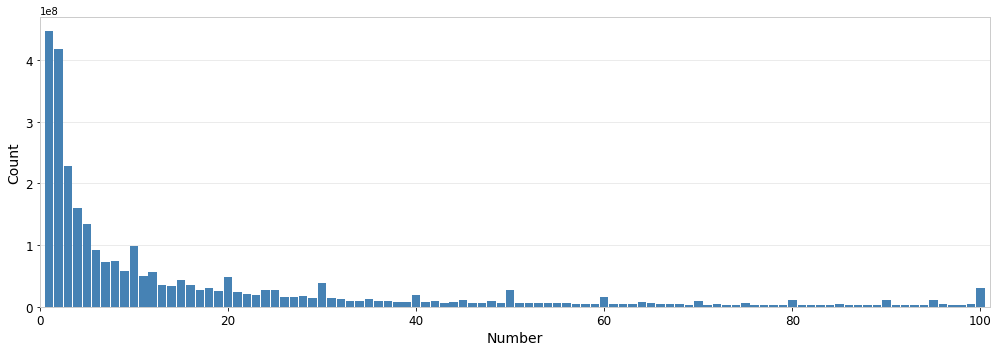

In [4]:
# Count bar chart (linear), bold title.
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(vals, counts, width=0.9, color="steelblue")
ax.set_xlabel("Number", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.set_xlim(0, 101)
ax.grid(True, axis="y", color="#e6e6e6", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig("/storage/scratch1/9/kzhang430/numbers_1_100.png", dpi=130)
plt.show()


power-law fit:  slope=-1.1882  R^2=0.8732  p(slope)=9.623e-46  (n=100 points, df=98)
highlighted numbers: [10, 12, 15, 20, 24, 25, 30, 40, 50, 60, 70, 75, 80, 90, 100]


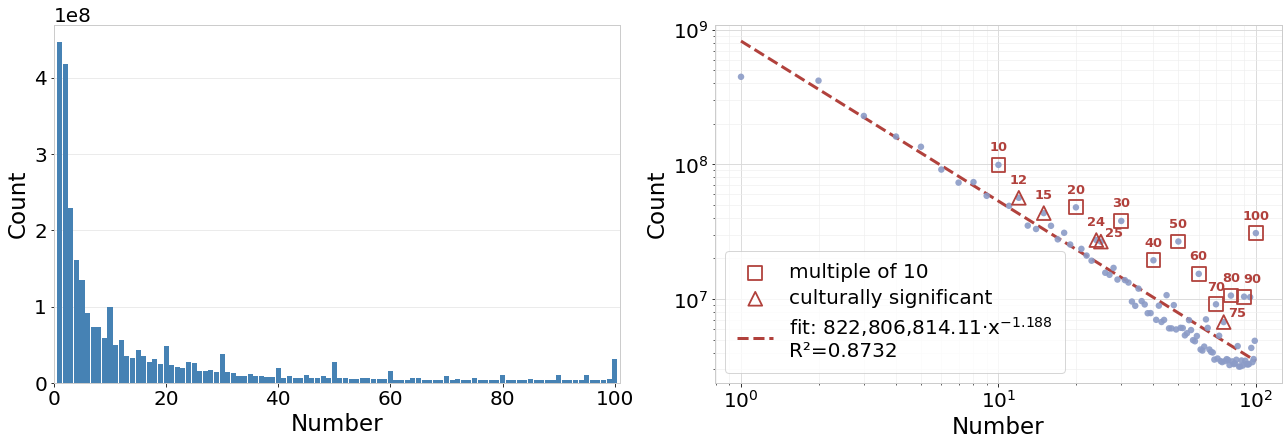

In [33]:
# Side-by-side Figure 1: (left) linear count bar chart, (right) log-log power-law fit.
mask = counts > 0
n = vals[mask]; c = counts[mask].astype(float)
x = np.log10(n); y = np.log10(c)
from scipy import stats
lr = stats.linregress(x, y)                # OLS fit of log10(count) ~ log10(number)
slope, intercept = lr.slope, lr.intercept
yhat = slope * x + intercept
resid = y - yhat
sigma = resid.std()
r2 = lr.rvalue ** 2                         # identical to 1 - SS_res/SS_tot
C = 10 ** intercept

# p-value for the power-law slope (H0: slope = 0, i.e. no relationship)
p_slope = lr.pvalue
print(f"power-law fit:  slope={slope:.4f}  R^2={r2:.4f}  "
      f"p(slope)={p_slope:.3e}  (n={len(n)} points, df={len(n)-2})")

CULTURAL = {12, 15, 25, 24, 75}                       # (b) always highlighted, even within 1 sigma
exc = resid > 1.0 * sigma                 # statistical round-number exceptions
exc &= (n != 95)                          # (c) do not highlight 95
exc |= np.isin(n, list(CULTURAL))         # (b) force cultural numbers in regardless of fit
print("highlighted numbers:", list(n[exc]))

# --- assign a marker shape to each highlighted point ---
def exc_marker(v):
    if v in CULTURAL:
        return "^"               # triangle: culturally significant
    if v % 10 == 0:              # (a) powers of 10 and their multiples
        return "s"               # square
    return "D"                   # diamond (default round-number exception)

# (marker, legend label) in draw order
EXC_CATEGORIES = [
    ("D", "round-number exception (>1σ)"),
    ("s", "multiple of 10"),
    ("^", "culturally significant"),
]

fig, (ax_bar, ax_fit) = plt.subplots(1, 2, figsize=(18, 6.3))

# ---- left panel: linear count bar chart ----
ax_bar.bar(vals, counts, width=0.9, color="steelblue")
ax_bar.set_xlabel("Number", fontsize=23)
ax_bar.set_ylabel("Count", fontsize=23)
ax_bar.set_xlim(0, 101)
ax_bar.grid(True, axis="y", color="#e6e6e6", linewidth=0.8)
ax_bar.set_axisbelow(True)
ax_bar.tick_params(labelsize=20)
ax_bar.yaxis.get_offset_text().set_fontsize(20)   # enlarge the 1e8 offset label

# ---- right panel: log-log power-law fit with highlighted points ----
ax_fit.scatter(n, c, s=42, color=DOT, alpha=0.9, edgecolors="none", zorder=2)

en, ec = n[exc], c[exc]
emk = np.array([exc_marker(int(v)) for v in en])
for mk, lbl in EXC_CATEGORIES:
    sel = emk == mk
    if not sel.any():
        continue
    ax_fit.scatter(en[sel], ec[sel], s=190, facecolors="none", edgecolors=FIT,
                   marker=mk, linewidths=1.8, zorder=3, label=lbl)

for xi, yi in zip(en, ec):
    v = int(xi)
    if v == 90:                        # nudge 90 slightly right of its marker
        xytext, ha, va = (8, 11), "center", "bottom"
    elif v in {25, 75}:                # these two read better up-right of the marker
        xytext, ha, va = (4, 2), "left", "bottom"   # snug to the marker
    elif v % 10 == 0 or v in CULTURAL:  # multiples of 10 + cultural numbers
        xytext, ha, va = (0, 11), "center", "bottom"   # label straight above the marker
    else:
        xytext, ha, va = (10, 5), "left", "bottom"
    ax_fit.annotate(str(v), (xi, yi), textcoords="offset points",
                    xytext=xytext, ha=ha, va=va,
                    color=FIT, fontsize=13, fontweight="bold", zorder=4)
xs = np.array([1, 100])
ax_fit.plot(xs, C * xs**slope, "--", color=FIT, linewidth=3, zorder=1,
            label=f"fit: {C:,.2f}·x$^{{{slope:.3f}}}$\nR²={r2:.4f}")
ax_fit.set_xscale("log"); ax_fit.set_yscale("log")
ax_fit.set_xlabel("Number", fontsize=23)
ax_fit.set_ylabel("Count", fontsize=23)
ax_fit.grid(True, which="major", color="#d9d9d9", linewidth=0.9)
ax_fit.grid(True, which="minor", color="#eeeeee", linewidth=0.6)
ax_fit.set_axisbelow(True)
ax_fit.tick_params(labelsize=20)
leg = ax_fit.legend(loc="lower left", fontsize=20, frameon=True,
                    borderpad=0.6, handlelength=1.8, labelspacing=0.35)
leg.get_frame().set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig("/storage/scratch1/9/kzhang430/numbers_1_100_combined.png", dpi=130, bbox_inches="tight")
plt.show()


In [6]:
# Statsmodels OLS printout for the power-law fit: log10(count) ~ log10(number).
# Same model as the figure; the slope p-value (and, for a single predictor, the
# overall F-test p-value) is the one reported above.
import statsmodels.api as sm

_mask = counts > 0
_x = np.log10(vals[_mask])
_y = np.log10(counts[_mask].astype(float))
_X = sm.add_constant(_x)
_ols = sm.OLS(_y, _X).fit()
print(_ols.summary(xname=["const", "log10(number)"], yname="log10(count)"))
print(f"\nslope p-value      : {_ols.pvalues[1]:.3e}")
print(f"overall F p-value  : {_ols.f_pvalue:.3e}")


                            OLS Regression Results                            
Dep. Variable:           log10(count)   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     675.0
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           9.62e-46
Time:                        16:13:21   Log-Likelihood:                 28.722
No. Observations:                 100   AIC:                            -53.44
Df Residuals:                      98   BIC:                            -48.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.9153      0.075    119.609

In [7]:
# Goodness-of-fit p-value for the power law (Clauset-Shalizi-Newman, "higher is better").
#
# Unlike the regression slope p-value (where small = the trend is real), here the
# NULL hypothesis is that the data IS power-law distributed:
#     p high  (>~0.10)  -> cannot reject; a power law is a plausible fit
#     p low   (<~0.10)  -> reject; the data deviates from a pure power law
#
# Procedure: fit P(k) ~ k^(-alpha) on support {1..100} by MLE, measure the KS
# distance to the data, then parametric-bootstrap B synthetic datasets from the
# fitted law (refitting each) and ask how often their KS distance >= the observed.
from scipy.optimize import minimize_scalar

_k = np.arange(1, 101)
_obs = np.array([svc.get(int(i), 0) for i in _k], dtype=float)   # svc: small_value_counts
_N = int(_obs.sum())

def _fit_alpha(cnt):
    def negll(a):
        w = _k**(-a)
        return -(cnt * (np.log(w) - np.log(w.sum()))).sum()
    return minimize_scalar(negll, bounds=(0.1, 6.0), method="bounded").x

def _ks(cnt, a):
    emp = np.cumsum(cnt) / cnt.sum()
    w = _k**(-a); mdl = np.cumsum(w / w.sum())
    return np.max(np.abs(emp - mdl))

_alpha = _fit_alpha(_obs)
_D_obs = _ks(_obs, _alpha)

rng = np.random.default_rng(0)
B = 1000
_pmf = _k**(-_alpha); _pmf = _pmf / _pmf.sum()
_Ds = np.empty(B)
for _b in range(B):
    _synth = rng.multinomial(_N, _pmf).astype(float)
    _Ds[_b] = _ks(_synth, _fit_alpha(_synth))
_p_gof = float(np.mean(_Ds >= _D_obs))

print("Clauset-Shalizi-Newman power-law goodness-of-fit")
print(f"  MLE exponent alpha : {_alpha:.4f}   (P(k) ~ k^-alpha on 1..100)")
print(f"  KS distance D_obs  : {_D_obs:.5f}")
print(f"  N (sample size)    : {_N:,}")
print(f"  GOF p-value        : {_p_gof:.3f}   (B={B}; report as < {1/B:g} if 0.000)")
print(f"  -> {'power law plausible (cannot reject)' if _p_gof >= 0.10 else 'pure power law REJECTED (deviations beyond sampling noise)'}")
print("  NOTE: with N in the billions this test has enormous power, so the")
print("  round-number spikes (10,20,...,95) are enough to reject a *pure* power law.")


Clauset-Shalizi-Newman power-law goodness-of-fit
  MLE exponent alpha : 1.0568   (P(k) ~ k^-alpha on 1..100)
  KS distance D_obs  : 0.05993
  N (sample size)    : 2,869,020,040
  GOF p-value        : 0.000   (B=1000; report as < 0.001 if 0.000)
  -> pure power law REJECTED (deviations beyond sampling noise)
  NOTE: with N in the billions this test has enormous power, so the
  round-number spikes (10,20,...,95) are enough to reject a *pure* power law.


## Figures 2 & 3 — frequency of arithmetic *result values* in the Pile

Result-value `c` of matched arithmetic expressions, restricted to `1 <= c <= 1000`.
**Figure 2**: all operations pooled (raw + log-log). **Figure 3**: split by the four
operations. Styling matches Figure 1 (dots in `DOT`, fit/prominent markers in `FIT`);
prominent-number shapes are kept consistent with Figure 1 (square = power of 10,
triangle = power of 2).

In [26]:
# ── Shared prep + style for Figures 2 & 3 (run before the two figure cells) ──
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

_rows = []
with open("pile_arith_matches_full_copy_backup.jsonl") as _f:
    for _line in _f:
        if _line.strip():
            _rows.append(json.loads(_line))
df_arith = pd.DataFrame(_rows)
for _col in ("a", "b", "c"):
    df_arith[_col] = df_arith[_col].apply(lambda x: int(x))

# normalise operators (ASCII + unicode) to the four canonical symbols
OP_MAP = {"+": "+", "＋": "+", "-": "−", "－": "−",
          "*": "×", "×": "×", "/": "÷", "÷": "÷"}
df_arith["op4"] = df_arith["op"].astype(str).str.strip().map(OP_MAP)

C_MAX = 1000                                  # caption: result value c <= 1000
OPS   = ["+", "−", "×", "÷"]
OP_COLOR = {"+": "#DD8452", "−": "#55A868", "×": "#C44E52", "÷": "#8172B3"}

# Figure-1 palette: blue-grey dots, brick-red fit / prominent markers
DOT = "#8b9bc7"
FIT = "#b1413c"

# prominent numbers (shapes shared with Figure 1)
POW10 = {10, 100, 1000}
POW2  = {2, 4, 8, 16, 32, 64, 128, 256, 512}
def prom_marker(v):
    v = int(v)
    if v in POW10:   return "s"     # square   (= Fig 1 powers/multiples of 10)
    if v in POW2:    return "^"     # triangle (= Fig 1)
    if v % 10 == 0:  return "D"     # diamond  (other multiples of 10)
    return None                     # not prominent

def result_freq(frame):
    """Counts of each result value c in [1, C_MAX]; returns (values, counts)."""
    vc = frame["c"].value_counts()
    vc = vc[(vc.index >= 1) & (vc.index <= C_MAX)].sort_index()
    return vc.index.values.astype(float), vc.values.astype(float)

def powerlaw_fit(x, y):
    """OLS of log10(count) ~ log10(value); returns (slope, C, r2)."""
    lr = stats.linregress(np.log10(x), np.log10(y))
    return lr.slope, 10 ** lr.intercept, lr.rvalue ** 2


Figure 2 (all ops) power-law fit: slope=-1.293  C=9,717.1  R²=0.6634  (n=772 result values)


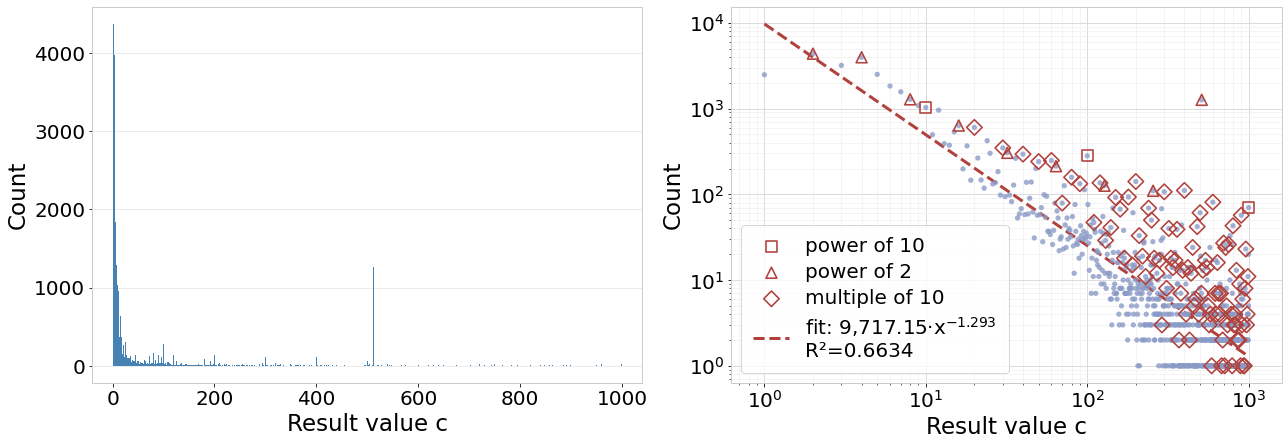

In [32]:
# ── Figure 2: result-value frequency, all operations pooled ──
v_all, c_all = result_freq(df_arith)
slope, C, r2 = powerlaw_fit(v_all, c_all)
print(f"Figure 2 (all ops) power-law fit: slope={slope:.3f}  C={C:,.1f}  "
      f"R²={r2:.4f}  (n={len(v_all)} result values)")

fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(18, 6.3))

# (left) raw frequency — bar chart, NO legend (note 3)
ax_raw.bar(v_all, c_all, width=1.0, color="steelblue")
ax_raw.set_xlabel("Result value c", fontsize=23)
ax_raw.set_ylabel("Count", fontsize=23)
_xpad = 0.04 * C_MAX; _ypad = 0.05 * c_all.max()
ax_raw.set_xlim(-_xpad, C_MAX + _xpad)        # x separation from the spines
ax_raw.set_ylim(-_ypad, c_all.max() + _ypad)  # y separation (override bar sticky edge at 0)
ax_raw.grid(True, axis="y", color="#e6e6e6", linewidth=0.8)
ax_raw.set_axisbelow(True)
ax_raw.tick_params(labelsize=20)

# (right) log-log with prominent-number shapes
ax_log.scatter(v_all, c_all, s=28, color=DOT, alpha=0.8, edgecolors="none", zorder=2)
_mk = np.array([prom_marker(x) or "" for x in v_all])
for _m, _lbl in [("s", "power of 10"), ("^", "power of 2"), ("D", "multiple of 10")]:
    _sel = _mk == _m
    if _sel.any():
        ax_log.scatter(v_all[_sel], c_all[_sel], s=120, facecolors="none",
                       edgecolors=FIT, marker=_m, linewidths=1.6, zorder=3, label=_lbl)
_xs = np.array([v_all.min(), v_all.max()])
ax_log.plot(_xs, C * _xs ** slope, "--", color=FIT, linewidth=3, zorder=1,
            label=f"fit: {C:,.2f}·x$^{{{slope:.3f}}}$\nR²={r2:.4f}")
ax_log.set_xscale("log"); ax_log.set_yscale("log")
ax_log.set_xlim(v_all.min() / 1.6, v_all.max() * 1.6)   # x padding (log scale)
ax_log.set_xlabel("Result value c", fontsize=23)
ax_log.set_ylabel("Count", fontsize=23)
ax_log.grid(True, which="major", color="#d9d9d9", linewidth=0.9)
ax_log.grid(True, which="minor", color="#eeeeee", linewidth=0.6)
ax_log.set_axisbelow(True)
ax_log.tick_params(labelsize=20)
_leg = ax_log.legend(loc="lower left", fontsize=20, frameon=True,
                     borderpad=0.6, handlelength=1.8, labelspacing=0.35)
_leg.get_frame().set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig("/storage/scratch1/9/kzhang430/figure2_result_freq.png", dpi=130, bbox_inches="tight")
plt.show()


In [19]:
# Statsmodels OLS printout for Figure 2: log10(count) ~ log10(result value c),
# all operations pooled, 1 <= c <= 1000.  (slope p-value = overall F p-value here)
import statsmodels.api as sm

_v, _c = result_freq(df_arith)                 # same data as Figure 2
_X = sm.add_constant(np.log10(_v))
_ols2 = sm.OLS(np.log10(_c), _X).fit()
print(_ols2.summary(xname=["const", "log10(c)"], yname="log10(count)"))
print(f"\nslope p-value      : {_ols2.pvalues[1]:.3e}")
print(f"overall F p-value  : {_ols2.f_pvalue:.3e}")


                            OLS Regression Results                            
Dep. Variable:           log10(count)   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     1517.
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          3.17e-184
Time:                        16:17:20   Log-Likelihood:                -415.52
No. Observations:                 772   AIC:                             835.0
Df Residuals:                     770   BIC:                             844.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9875      0.084     47.562      0.0

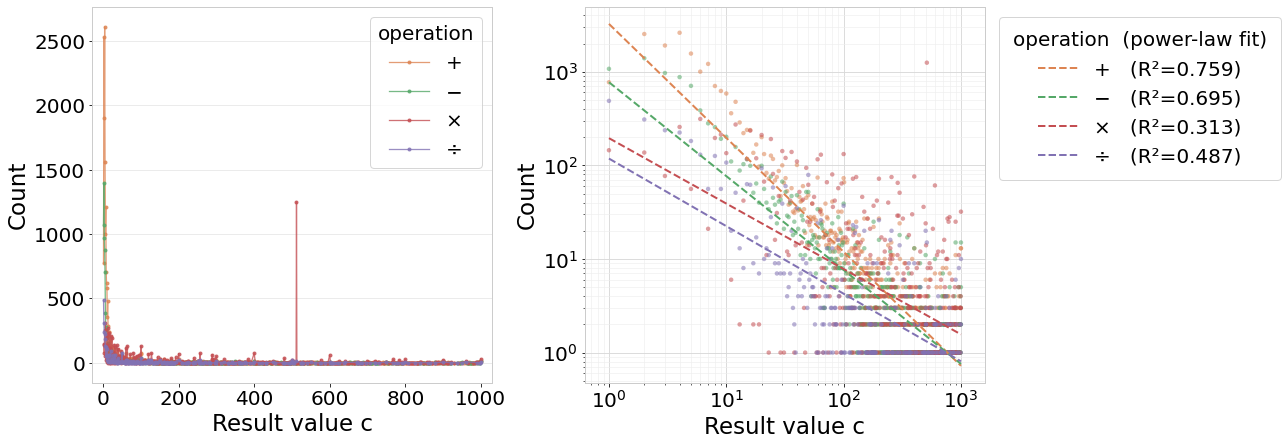

In [36]:
# ── Figure 3: result-value frequency, split by operation ──
fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(18, 6.3))

for _op in OPS:
    _xv, _yv = result_freq(df_arith[df_arith["op4"] == _op])
    if len(_xv) < 3:
        continue
    _col = OP_COLOR[_op]
    _slope, _C, _r2 = powerlaw_fit(_xv, _yv)

    # (left) raw frequency — one line + points per operation
    _o = np.argsort(_xv)
    ax_raw.plot(_xv[_o], _yv[_o], color=_col, marker="o", markersize=3,
                linewidth=1.3, alpha=0.8, label=_op)

    # (right) log-log — points + power-law fit per operation; R² in legend
    ax_log.scatter(_xv, _yv, s=20, color=_col, alpha=0.55, edgecolors="none", zorder=2)
    _xs = np.array([_xv.min(), _xv.max()])
    ax_log.plot(_xs, _C * _xs ** _slope, "--", color=_col, linewidth=2, zorder=3,
                label=f"{_op}   (R²={_r2:.3f})")

# (left) cosmetics
ax_raw.set_xlabel("Result value c", fontsize=23)
ax_raw.set_ylabel("Count", fontsize=23)
ax_raw.margins(x=0.03, y=0.06)   # pad axes so data is separated from the spines (incl. below 0)
ax_raw.grid(True, axis="y", color="#e6e6e6", linewidth=0.8)
ax_raw.set_axisbelow(True)
ax_raw.tick_params(labelsize=20)
ax_raw.legend(title="operation", fontsize=20, title_fontsize=20, loc="upper right")

# (right) cosmetics
ax_log.set_xscale("log"); ax_log.set_yscale("log")
ax_log.set_xlim(v_all.min() / 1.6, v_all.max() * 1.6)   # x padding (log scale)
ax_log.set_xlabel("Result value c", fontsize=23)
ax_log.set_ylabel("Count", fontsize=23)
ax_log.grid(True, which="major", color="#d9d9d9", linewidth=0.9)
ax_log.grid(True, which="minor", color="#eeeeee", linewidth=0.6)
ax_log.set_axisbelow(True)
ax_log.tick_params(labelsize=20)
_leg = ax_log.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0),
                     fontsize=20, frameon=True, borderpad=0.7,
                     title="operation  (power-law fit)", title_fontsize=20)
_leg.get_frame().set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig("/storage/scratch1/9/kzhang430/figure3_per_op.png", dpi=130, bbox_inches="tight")
plt.show()


In [17]:
# Statsmodels OLS printouts for Figure 3: log10(count) ~ log10(result value c),
# fit SEPARATELY for each operation (1 <= c <= 1000). Full table per op, then a
# compact comparison.
import statsmodels.api as sm

_summary_rows = []
for _op in OPS:
    _xv, _yv = result_freq(df_arith[df_arith["op4"] == _op])
    if len(_xv) < 3:
        continue
    _X = sm.add_constant(np.log10(_xv))
    _m = sm.OLS(np.log10(_yv), _X).fit()
    print("=" * 78)
    print(f"Operation:  {_op}      (n = {len(_xv)} result values)")
    print(_m.summary(xname=["const", "log10(c)"], yname="log10(count)"))
    _summary_rows.append({
        "op": _op, "n": len(_xv),
        "slope": _m.params[1], "intercept": _m.params[0],
        "R2": _m.rsquared, "slope_p": _m.pvalues[1], "F_p": _m.f_pvalue,
    })

print("\n" + "=" * 78)
print("Per-operation power-law fit summary (Figure 3):")
_summ = pd.DataFrame(_summary_rows).set_index("op")
with pd.option_context("display.float_format", lambda v: f"{v:.4g}"):
    print(_summ)


Operation:  +      (n = 600 result values)
                            OLS Regression Results                            
Dep. Variable:           log10(count)   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     1888.
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          3.50e-187
Time:                        16:15:08   Log-Likelihood:                -171.11
No. Observations:                 600   AIC:                             346.2
Df Residuals:                     598   BIC:                             355.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    